# Uncertainty Quantification for LLMs: A Comprehensive Tutorial

Welcome to this interactive tutorial on estimating uncertainty in Large Language Models (LLMs) applied to the clinical domain.

This notebook provides a hands-on approach to Uncertainty Quantification (UQ) by leveraging two state-of-the-art Python libraries: **`lm-polygraph`** and **`uqlm`**.

##### Load  the requested libraries

In [1]:
## CELL 0: ENVIRONMENT SETUP (Run this first!)
!pip install -q lm-polygraph uqlm transformers accelerate langchain langchain-huggingface langchain_openai langchain-google-genai langchain-anthropic langchain_ollama

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.9/267.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# ==========================================
# 1. SYSTEM CONFIGURATION (Strictly before importing Torch!)
# ==========================================
import os
# Prevents VRAM fragmentation on Colab (Must precede import torch)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ==========================================
# 2. STANDARD PYTHON LIBRARIES
# ==========================================
import gc
import json
import types
import random
import asyncio
import getpass
import inspect
import subprocess
import time
from typing import Optional, Union, Any, Dict, List, Tuple
import requests
import pandas as pd
import io
import base64

# ==========================================
# 3. DATA SCIENCE & DEEP LEARNING LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline


##### Fix a random seed to ensure reproducibility of your experiment

In [2]:
import numpy as np

# --- Setting seed for Scientific Reproducibility ---
RANDOM_SEED = 42

def set_global_seed(seed=RANDOM_SEED):
    """Locks the random seed for predictable, reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed()


# **Genaral Utilities**

The `prepare_dataset` function loads a QA Dataset from Hugging Face, standardizes its schema by merging textual context with the question, and splits the sampled records into isolated training and testing sets.

In [3]:
import base64
import io
import pandas as pd
from datasets import load_dataset
from PIL import Image
from sklearn.model_selection import train_test_split
from typing import Optional, Tuple


def prepare_dataset(
    path: str = "pubmed_qa",
    name: Optional[str] = None,
    split: str = "train",
    max_samples: int = 30,
    test_size: float = 0.33,
    random_state: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Loads clinical benchmark datasets (both text-only and multimodal) from
    Hugging Face Hub, standardizes their schema, extracts image data into base64
    if present, and outputs isolated, leakage-free Train/Test splits.

    Parameters:
    -----------
    path : str, default="pubmed_qa"
        The Hugging Face dataset identifier path.
    name : Optional[str], default=None
        The configuration name of the dataset.
    split : str, default="train"
        The dataset split to fetch.
    max_samples : int, default=30
        Maximum number of samples to keep for downsampling.
    test_size : float, default=0.33
        The proportion of the dataset to include in the test split.
    random_state : int, default=42
        Determines random number generation for shuffling and splitting.

    Returns:
    --------
    Tuple[pd.DataFrame, pd.DataFrame]
        A standardized (train_df, test_df) pair.
    """
    print(f"⏳ Loading clinical dataset directly from Hugging Face Hub ({path})...")

    # 1. Load the requested dataset split
    raw_dataset = load_dataset(path, name, split=split)
    raw_df = raw_dataset.to_pandas()

    # 2. Execute controlled subset sampling
    if max_samples and max_samples < len(raw_df):
        raw_df = (
            raw_df.sample(frac=1, random_state=random_state)
            .reset_index(drop=True)
            .head(max_samples)
        )
    else:
        raw_df = raw_df.sample(frac=1, random_state=random_state).reset_index(
            drop=True
        )

    standardized_records = []
    image_col = next(
        (col for col in ["image", "img"] if col in raw_df.columns), None
    )
    has_images = image_col is not None

    # 3. Execute the schema standardization and encoding pipeline
    for idx, row in raw_df.iterrows():
        question_text = ""
        answer_text = ""

        if path == "pubmed_qa" or name == "pqa_labeled":
            contexts = row["context"]
            context_str = (
                " ".join(contexts["contexts"])
                if isinstance(contexts, dict) and "contexts" in contexts
                else ""
            )
            question_text = f"Context: {context_str}\nQuestion: {row['question']}"
            answer_text = row["final_decision"]
        else:
            for q_key in ["question", "phrase", "text", "query"]:
                if q_key in row and pd.notna(row[q_key]):
                    question_text = row[q_key]
                    break
            for a_key in ["answer", "final_decision", "label", "target"]:
                if a_key in row and pd.notna(row[a_key]):
                    answer_text = row[a_key]
                    break

        # Encode raw image data into a standardized Base64 string string representation
        encoded_image = None
        mime_type = None
        if has_images and row[image_col] is not None:
            try:
                img_data = row[image_col]
                if (
                    isinstance(img_data, dict)
                    and "bytes" in img_data
                    and img_data["bytes"] is not None
                ):
                    img = Image.open(io.BytesIO(img_data["bytes"]))
                elif hasattr(img_data, "convert"):
                    img = img_data
                else:
                    continue

                buffered = io.BytesIO()
                img.convert("RGB").save(buffered, format="PNG")
                encoded_image = base64.b64encode(buffered.getvalue()).decode(
                    "utf-8"
                )
                mime_type = "image/png"
            except Exception as e:
                print(
                    f"⚠️ Image encoding failed for visual asset at index {idx}: {e}"
                )
                continue

        if question_text or answer_text:
            standardized_records.append(
                {
                    "question": question_text,
                    "answer": str(answer_text).strip(),
                    "image_base64": encoded_image,
                    "image_mime": mime_type,
                }
            )

    standardized_df = pd.DataFrame(standardized_records)

    # 4. Perform deterministic Train/Test partitioning
    train_df, test_df = train_test_split(
        standardized_df, test_size=test_size, random_state=random_state
    )

    print(f"📊 Dataset processing complete via native Hybrid Engine!")
    print(
        f"   └── Operational Mode: {'MULTIMODAL (Vision-Language)' if has_images else 'TEXT-ONLY'}"
    )
    print(
        f"   └── 📈 Train size (Calibration Fitting Pool): {len(train_df)} samples"
    )
    print(
        f"   └── 📉 Test size (Holdout Evaluation Pool):  {len(test_df)} samples\n"
    )

    return train_df, test_df


## **`UQEngineContext` Utility**

The `UQEngineContext` class manages the lifecycle of your models. It allows you to orchestrate multiple models under custom nicknames (**aliases**), configure their operational modes independently, inspect live allocations, and purge them to free up memory.

> 💡 **Core Architectural Rule:** Operational modes (`"white"` vs `"black"`) are **strictly model-specific**, not library-specific. Every single model you load is completely isolated. You can run a White-Box model and a Black-Box model simultaneously within the same context manager.

---

### **1. Initialize the Context (Set Fallback Defaults)**

Create the master manager instance. The parameters passed here act *only* as fallback defaults if you omit the `mode` parameter during individual loading calls.

```python
# Sets the default behavior rules for the session
engine = UQEngineContext(default_polygraph_mode="white", default_uqlm_mode="black")

```

---

### **2. Load a Polygraph Model (`.load_polygraph`)**

Use this method to initialize backbones for the **LM-Polygraph** framework.

* **Basic Usage:**

```python
# Configures THIS specific model instance in White-Box mode
engine.load_polygraph(model_id="google/gemma-2-2b-it", alias="gemma_local", mode="white", quant_mode="4bit")

```

* **Key Arguments:**
* `model_id`: The Hugging Face repository directory path.
* `alias`: Your custom tracking nickname (e.g., `"gemma_local"`). This completely isolates the instance.
* `mode`: **Model-Specific Override.** Explicitly force `"white"` (local logprobs) or `"black"` (API) for this alias.
* `quant_mode`: Set to `"4bit"` or `"8bit"` to compress local models and preserve hardware VRAM.



---

### **3. Load a UQLM Model (`.load_uqlm`)**

Use this method to initialize backbones through LangChain for the **UQLM** calibration framework.

* **Basic Usage:**

```python
# Configures THIS specific model instance in Black-Box mode via API
engine.load_uqlm(provider="openai", model_id="gpt-4o", alias="gpt_api", mode="black", temperature=0.0)

```

* **Key Arguments:**
* `provider`: Supported backends: `"openai"`, `"google"`, `"anthropic"`, `"ollama"`, or `"custom"`.
* `model_id`: The specific engine identifier tag or API model name.
* `mode`: **Model-Specific Override.** Choose how this specific alias isolates token parameters, independent of other environments.
* **Ollama Automation:** If you select `"ollama"` and the weights are missing locally, the function automatically initializes a real-time download progress stream.



---

### **4. Inspect Live Deployments (`.get_active_models`)**

Before wiping resources, you can query the environment memory map to view precisely which models are currently consuming system resources.

* **Basic Usage:**

```python
engine.get_active_models()

```

* **Sample Console Output Summary:**
```text
=======================================================
📋 LIVE UNCERTAINTY QUANTIFICATION REGISTRIES
=======================================================
🔹 lm_polygraph Framework (1 active):
  • Alias: [GEMMA_LOCAL] ➔ Operational Mode: WHITE-BOX

🔸 UQLM Calibration Framework (1 active):
  • Alias: [GPT_API] ➔ Operational Mode: BLACK-BOX
=======================================================

```



---

### **5. Flush Memory & Prevent Crashes (`.unload`)**

Your definitive safety net against fatal Out-Of-Memory (OOM) errors. Call this whenever you finish a workflow stage to wipe the GPU memory completely clean before loading your next configuration.

* **Purge Everything:**

```python
engine.unload()  # Deletes all active model aliases and flushes CUDA VRAM cache

```

* **Purge a Specific Model Instance:**

```python
engine.unload(aliases="gemma_local")  # Clears only the targeted model alias

```

* **Purge a List of Models:**

```python
engine.unload(aliases=["gemma_local", "gpt_api"])

```





In [4]:
# --- lm_polygraph Imports ---
from transformers import AutoProcessor, AutoModelForImageTextToText, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from lm_polygraph.utils.model import BlackboxModel, WhiteboxModel
from lm_polygraph.model_adapters import VisualWhiteboxModel
from lm_polygraph.utils.generation_parameters import GenerationParameters

# --- LangChain Imports ---
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

class UQEngineContext:
    """
    Manager class for Uncertainty Quantification Models.
    Handles multi-model setups with independent operational modes (white/black box) per alias.
    """
    def __init__(self, default_polygraph_mode: str = "black", default_uqlm_mode: str = "black"):
        self.default_polygraph_mode = default_polygraph_mode.strip().lower()
        self.default_uqlm_mode = default_uqlm_mode.strip().lower()

        self.polygraph_models: dict[str, Any] = {}
        self.langchain_llms: dict[str, Any] = {}

        self.polygraph_modes: dict[str, str] = {}
        self.uqlm_modes: dict[str, str] = {}

    # ==========================================
    # DIAGNOSTIC REGISTER MANAGEMENT
    # ==========================================
    def get_active_models(self) -> None:
        """
        Prints a structural summary of all currently live model aliases
        and their assigned operational boundaries.
        """
        print("\n" + "="*55)
        print("📋 LIVE UNCERTAINTY QUANTIFICATION REGISTRIES")
        print("="*55)

        poly_aliases = list(self.polygraph_models.keys())
        uqlm_aliases = list(self.langchain_llms.keys())

        print(f"🔹 lm_polygraph Framework ({len(poly_aliases)} active):")
        if not poly_aliases:
            print("  (No active aliases allocated)")
        for alias in poly_aliases:
            mode = self.polygraph_modes.get(alias, "unknown").upper()
            print(f"  • Alias: [{alias.upper()}] ➔ Operational Mode: {mode}-BOX")

        print(f"\n🔸 UQLM Calibration Framework ({len(uqlm_aliases)} active):")
        if not uqlm_aliases:
            print("  (No active aliases allocated)")
        for alias in uqlm_aliases:
            mode = self.uqlm_modes.get(alias, "unknown").upper()
            print(f"  • Alias: [{alias.upper()}] ➔ Operational Mode: {mode}-BOX")
        print("="*55 + "\n")

    # ==========================================
    # POLYGRAPH MANAGEMENT (Independent Modes)
    # ==========================================
    def load_polygraph(self,
                       model_id: str,
                       alias: str = "default",
                       mode: Optional[str] = None,
                       is_multimodal: bool = False,
                       quant_mode: str = "none",
                       temperature: float = 0.7,
                       max_new_tokens: int = 30,
                       do_sample: bool = True,
                       device_map: str = "auto",
                       attn_implementation: str = "eager",
                       **hf_extra_kwargs):
        """Loads an lm_polygraph model natively with an independent box mode."""
        current_mode = mode.strip().lower() if mode else self.default_polygraph_mode
        if current_mode == "none":
            print(f"⚠️ Polygraph mode is set to 'none'. Skipping load for alias '{alias}'.")
            return

        print(f"\n⚙️ Setting up lm_polygraph [{alias.upper()}] in {current_mode.upper()}-BOX mode...")
        self.polygraph_modes[alias] = current_mode

        shared_generation_params = GenerationParameters(
            temperature=temperature, do_sample=do_sample, max_new_tokens=max_new_tokens
        )

        if current_mode == "white":
            if "HF_TOKEN" not in os.environ:
                os.environ["HF_TOKEN"] = getpass.getpass("Paste your Hugging Face Token: ")

            model_loader_class = hf_extra_kwargs.pop("model_loader_class", AutoModelForImageTextToText)
            model_kwargs = {"device_map": device_map if torch.cuda.is_available() else "cpu", "token": os.environ["HF_TOKEN"]}

            if attn_implementation:
                model_kwargs["attn_implementation"] = attn_implementation

            if "trust_remote_code" not in hf_extra_kwargs:
                model_kwargs["trust_remote_code"] = True

            model_kwargs.update(hf_extra_kwargs)

            if quant_mode == '4bit':
                model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
            elif quant_mode == '8bit':
                model_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)
            else:
                model_kwargs["torch_dtype"] = torch.float16

            if is_multimodal:
                processor = AutoProcessor.from_pretrained(
                    model_id,
                    token=os.environ["HF_TOKEN"],
                    trust_remote_code=model_kwargs.get("trust_remote_code", True)
                )
                base_model = model_loader_class.from_pretrained(model_id, **model_kwargs)
                self.polygraph_models[alias] = VisualWhiteboxModel(
                    model=base_model, processor_visual=processor, model_path=model_id, generation_parameters=shared_generation_params
                )
            else:
                tokenizer = AutoTokenizer.from_pretrained(model_id, token=os.environ["HF_TOKEN"])
                base_model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
                self.polygraph_models[alias] = WhiteboxModel(
                    model=base_model, tokenizer=tokenizer, model_path=model_id, generation_parameters=shared_generation_params
                )
        else:
            if "OPENAI_API_KEY" not in os.environ:
                os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI API Key: ")
            if "HF_TOKEN" not in os.environ:
                os.environ["HF_TOKEN"] = getpass.getpass("Paste your Hugging Face Token: ")

            self.polygraph_models[alias] = BlackboxModel(
                model_path=model_id, openai_api_key=os.environ.get("OPENAI_API_KEY"), hf_api_token=os.environ.get("HF_TOKEN"), supports_logprobs=True, generation_parameters=shared_generation_params
            )



    def load_uqlm(self,
                  provider: str,
                  model_id: Optional[str] = None,
                  alias: str = "default",
                  mode: Optional[str] = None,
                  temperature: float = 0.7,
                  max_tokens: Optional[int] = None,
                  custom_llm: Optional[Any] = None,
                  ollama_url: str = "http://localhost:11434",
                  auto_install: bool = False,
                  **uqlm_kwargs):
        """Loads a LangChain LLM with an independent box mode mapping."""
        current_mode = mode.strip().lower() if mode else self.default_uqlm_mode
        if current_mode == "none":
            return

        provider = provider.strip().lower()

        if current_mode == "white" and provider in ["anthropic", "google"]:
            print(f"⚠️ CRITICAL WARNING: Provider '{provider.upper()}' for alias '{alias}' does not support White-Box logprobs. Forcing Black-Box.")
            current_mode = "black"

        self.uqlm_modes[alias] = current_mode
        print(f"\n📊 Setting up UQLM [{alias.upper()}] in {current_mode.upper()}-BOX mode...")

        if provider == "custom":
            self.langchain_llms[alias] = custom_llm
            return

        if provider == "openai":
            if "OPENAI_API_KEY" not in os.environ:
                os.environ["OPENAI_API_KEY"] = getpass.getpass("Paste your OpenAI Key: ")
            openai_kwargs = {"logprobs": True} if current_mode == "white" else {}
            self.langchain_llms[alias] = ChatOpenAI(model=model_id, temperature=temperature, max_tokens=max_tokens, model_kwargs=openai_kwargs, **uqlm_kwargs)
        elif provider == "google":
            if "GOOGLE_API_KEY" not in os.environ:
                os.environ["GOOGLE_API_KEY"] = getpass.getpass("Paste your Google Key: ")
            self.langchain_llms[alias] = ChatGoogleGenerativeAI(model=model_id, temperature=temperature, max_tokens=max_tokens, **uqlm_kwargs)
        elif provider == "anthropic":
            if "ANTHROPIC_API_KEY" not in os.environ:
                os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Paste your Anthropic Key: ")
            self.langchain_llms[alias] = ChatAnthropic(model=model_id, temperature=temperature, max_tokens=max_tokens, **uqlm_kwargs)

        elif provider == "ollama":
            manager = OllamaManager(base_url=ollama_url)

            if not manager.load_model(model_name=model_id, auto_install=auto_install):
                print(f"❌ Aborting allocation for alias [{alias.upper()}]: Model download or service failed.")
                return

            if current_mode == "white":
                uqlm_kwargs.pop("base_url", None)
                self.langchain_llms[alias] = ChatOpenAI(
                    base_url=f"{ollama_url}/v1",
                    api_key="ollama",
                    model=model_id,
                    temperature=temperature,
                    max_tokens=max_tokens,
                    model_kwargs={"logprobs": True},
                    **uqlm_kwargs
                )
                print(f"🔗 Ollama White-Box instance generated via compatibility layer ({ollama_url}/v1)")
            else:
                uqlm_kwargs["base_url"] = ollama_url
                self.langchain_llms[alias] = ChatOllama(model=model_id, temperature=temperature, **uqlm_kwargs)

    def unload(self, aliases: Optional[Union[list[str], str]] = None) -> None:
        """
        Safely unloads specified model aliases or all models from memory,
        breaking references to force garbage collection and flush GPU VRAM cache.
        """
        if aliases is None:
            all_targets = list(set(list(self.polygraph_models.keys()) + list(self.langchain_llms.keys())))
        elif isinstance(aliases, str):
            all_targets = [aliases.strip()]
        else:
            all_targets = [a.strip() for a in aliases]

        if not all_targets:
            print("🧹 No active models found in registries to unload.")
            return

        print(f"\n🧹 Initiating memory purge for target aliases: {all_targets}")

        for alias in all_targets:
            unloaded_any = False

            if alias in self.polygraph_models:
                wrapper = self.polygraph_models[alias]

                if isinstance(wrapper, VisualWhiteboxModel):
                    del wrapper.model
                    del wrapper.processor_visual
                elif isinstance(wrapper, WhiteboxModel):
                    del wrapper.model
                    del wrapper.tokenizer

                del self.polygraph_models[alias]
                self.polygraph_modes.pop(alias, None)
                unloaded_any = True

            if alias in self.langchain_llms:
                del self.langchain_llms[alias]
                self.uqlm_modes.pop(alias, None)
                unloaded_any = True

            if unloaded_any:
                print(f"  ✅ References cleared for alias: [{alias.upper()}]")
            else:
                print(f"  ⚠️ Target alias [{alias.upper()}] not found in any active registry.")

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            print("  ✨ GPU VRAM cache cleared and synchronized.")
        else:
            print("  ✨ System RAM defragmented via garbage collection.")

In [5]:
import os
import sys
import time
import json
import shutil
import requests
import subprocess
from typing import List, Optional, Union, Any

class OllamaManager:
    """
    Unified controller for Ollama service lifecycle and model cache management.
    Embedded with an automated self-healing pipeline and bulletproof GitHub deployment
    mechanisms for flawless cross-environment execution.
    """
    def __init__(self, base_url: str = "http://localhost:11434", timeout: int = 2):
        self.base_url = base_url.strip().rstrip("/")
        self.timeout = timeout
        self.target_binary_path = "/usr/local/bin/ollama"

    def is_running(self) -> bool:
        """Checks if the Ollama service daemon is active and responding to queries."""
        try:
            response = requests.get(f"{self.base_url}/api/tags", timeout=self.timeout)
            return response.status_code == 200
        except requests.exceptions.RequestException:
            return False

    def _execute_pure_purge(self) -> None:
        """
        Internal Private Method: Forces a complete, non-destructive system purge
        of any legacy, corrupt, or incomplete Ollama processes and binaries.
        """
        print("🧹 [Self-Healing] Executing deep environmental purge of legacy artifacts...")
        subprocess.run("pkill -9 ollama", shell=True, capture_output=True)
        subprocess.run("pkill -9 llama-server", shell=True, capture_output=True)

        targets_to_remove = [
            "/usr/local/bin/ollama",
            "/usr/bin/ollama",
            "/usr/lib/ollama",
            "/usr/share/ollama",
            "ollama.log"
        ]
        for target in targets_to_remove:
            if os.path.exists(target):
                try:
                    if os.path.isdir(target):
                        shutil.rmtree(target)
                    else:
                        os.remove(target)
                except Exception:
                    pass

    def _attempt_system_install(self) -> bool:
        """
        Executes a pristine system deployment by filtering official GitHub release assets,
        downloading via native curl, and handling target extraction layers dynamically.
        """
        print("\n" + "="*70)
        print("📥 1. Querying GitHub API and filtering for standard Linux CUDA asset...")
        print("="*70)

        try:
            api_url = "https://api.github.com/repos/ollama/ollama/releases/latest"
            release_data = requests.get(api_url, timeout=5).json()
            assets = release_data.get("assets", [])

            download_url = None
            matched_asset_name = None

            # Priority filter (Excludes Apple MLX and AMD ROCm architectures)
            for asset in assets:
                name_lower = asset["name"].lower()
                if "linux" in name_lower and "amd64" in name_lower:
                    if "mlx" not in name_lower and "rocm" not in name_lower:
                        download_url = asset["browser_download_url"]
                        matched_asset_name = asset["name"]
                        break

            if not download_url:
                print("❌ Error: Could not find any suitable Linux amd64 asset in the latest release.")
                return False

            print(f"🎯 Targeted Asset Matched: '{matched_asset_name}'")

            base_download_dir = "/content" if os.path.exists("/content") else "/tmp"
            temp_download_path = f"{base_download_dir}/{matched_asset_name}"

            if os.path.exists(temp_download_path):
                os.remove(temp_download_path)

            print("📥 Downloading comprehensive package via native curl...")
            curl_cmd = f"curl -L -f -sS {download_url} -o {temp_download_path}"
            subprocess.run(curl_cmd, shell=True, check=True)

            print("📦 Extracting archive directly to system root (/usr)...")
            if temp_download_path.endswith(".zst"):
                subprocess.run("apt-get update -qq && apt-get install -y -qq zstd", shell=True, check=True)

            extract_cmd = f"tar -C /usr -xf {temp_download_path}"
            subprocess.run(extract_cmd, shell=True, check=True)

            try:
                os.remove(temp_download_path)
            except:
                pass

            self.target_binary_path = "/usr/bin/ollama" if os.path.exists("/usr/bin/ollama") else "/usr/local/bin/ollama"
            os.chmod(self.target_binary_path, 0o755)
            print(f"✅ Ollama successfully deployed to: {self.target_binary_path}")
            return True

        except Exception as e:
            print(f"💥 Deployment pipeline failed. Reason: {e}")
            return False

    def ensure_service(self, auto_install: bool = False) -> bool:
        """
        Guarantees the Ollama service daemon is active. Tracks structural dependencies
        and triggers an autonomous background self-healing purge if corruption is found.
        """
        if self.is_running():
            return True

        if "localhost" not in self.base_url and "127.0.0.1" not in self.base_url:
            print(f"❌ Error: Remote Ollama node at {self.base_url} is unreachable. Cannot trigger remote boot.")
            return False

        # Architectural Check: Ensure BOTH frontend CLI and internal backend runners exist
        binary_found = False
        for p in ["/usr/local/bin/ollama", "/usr/bin/ollama"]:
            if os.path.exists(p) and os.path.exists("/usr/lib/ollama/llama-server"):
                self.target_binary_path = p
                binary_found = True
                break

        if not binary_found:
            if not auto_install:
                print("💥 Critical: Complete Ollama installation (binary + server runners) is missing.")
                return False
            print("⚠️ Incomplete or corrupted installation detected. Activating clean deployment layer...")
            self._execute_pure_purge()  # Auto-clean before install
            if not self._attempt_system_install():
                return False

        # Launch background daemon process
        print("\n⚙️ Starting Ollama background daemon...")
        backend_cmd = f"nohup {self.target_binary_path} serve > ollama.log 2>&1 &"
        subprocess.Popen(backend_cmd, shell=True)

        print("⏳ Waiting for Ollama server to initialize hardware runners...")
        for i in range(20):
            try:
                response = requests.get(f"{self.base_url}/api/tags", timeout=10)
                if response.status_code == 200:
                    print("\n🎉 SUCCESS: Ollama is now active with full local hardware acceleration!")
                    return True
            except (requests.exceptions.ConnectionError, requests.exceptions.Timeout):
                print(f"  [Attempt {i+1}/20] Server warming up, retrying...")
                time.sleep(2.5)
        else:
            # DYNAMIC SELF-HEALING FALLBACK
            if auto_install:
                print("\n🚨 CRITICAL: Daemon failed to initialize. Triggering autonomous Self-Healing Recovery...")
                self._execute_pure_purge()
                if self._attempt_system_install():
                    print("\n⚙️ Retrying daemon startup post-recovery...")
                    subprocess.Popen(backend_cmd, shell=True)
                    for j in range(10):
                        try:
                            response = requests.get(f"{self.base_url}/api/tags", timeout=10)
                            if response.status_code == 200:
                                print("\n🎉 SELF-HEALING SUCCESS: Ollama fully recovered and responsive!")
                                return True
                        except:
                            time.sleep(2.5)

            print("❌ ERROR: Timed out waiting for Ollama server to respond.")
            return False

    def load_model(self, model_name: str, force_pull: bool = False, auto_install: bool = False) -> bool:
        """Verifies local availability of the targeted model weights and automates streaming download."""
        if not self.ensure_service(auto_install=auto_install):
            return False

        normalized_name = model_name if ":" in model_name else f"{model_name}:latest"

        try:
            response = requests.get(f"{self.base_url}/api/tags", timeout=5)
            local_models = [m["name"] for m in response.json().get("models", [])]
        except Exception as e:
            print(f"❌ Failed to extract local models inventory: {e}")
            return False

        if normalized_name in local_models and not force_pull:
            print(f"📦 Model '{normalized_name}' verified inside local storage cache. Ready.")
            return True

        print(f"📥 Model '{model_name}' not found. Starting real-time streaming pull...")
        try:
            pull_url = f"{self.base_url}/api/pull"
            payload = {"name": model_name, "stream": True}

            with requests.post(pull_url, json=payload, stream=True, timeout=30) as pull_response:
                if pull_response.status_code != 200:
                    print(f"❌ Download rejected by registry. HTTP Status: {pull_response.status_code}")
                    return False

                for line in pull_response.iter_lines():
                    if line:
                        status_data = json.loads(line.decode('utf-8'))
                        status = status_data.get("status", "")
                        completed = status_data.get("completed", 0)
                        total = status_data.get("total", 0)

                        if total > 0:
                            percent = (completed / total) * 100
                            print(f"📦 [Ollama Download] {status}: {percent:.1f}%", end="\r")
                        else:
                            print(f"📦 [Ollama Download] {status}...", end="\r")

            print(f"\n✅ Successfully pulled weights for local model: '{model_name}'")
            return True
        except requests.exceptions.RequestException as e:
            print(f"💥 Network infrastructure anomaly detected: {e}")
            return False



### **Streamlining Setup: Using `setup_uq_environment`**

Instead of manually instantiating the context class and calling individual load methods for every single architecture, you can orchestrate your entire workspace using the `setup_uq_environment()` utility function. This helper wraps the framework initialization, handling configuration priorities and bulk loading automatically.

It provides two flexible ingestion patterns depending on your layout:

#### 1. Single Model Quick-Start

You can pass a raw string directly to spin up a single baseline model for benchmarking.

```python
# Quick deployment using smart defaults
uq_engine = setup_uq_environment(
    polygraph_models="Qwen/Qwen2.5-3B-Instruct",
    p_mode="white",
    quant_choice="4bit"
)

```

#### 2. Advanced Multi-Model Bulk Loading

For complex benchmarking, pass structured dictionaries to deploy multiple models with independent overrides, distinct token parameters, and custom extra arguments seamlessly.

```python
# Deploying a diverse multi-model ecosystem simultaneously
uq_engine = setup_uq_environment(
    polygraph_models={
        "qwen_local": {"model_id": "Qwen/Qwen2.5-3B-Instruct", "mode": "white", "quant_mode": "4bit"},
        "llama_local": {"model_id": "meta-llama/Llama-3.2-3b", "mode": "white"}
    },
    uqlm_models={
        "claude_api": {"provider": "anthropic", "model_id": "claude-3-5-sonnet-20241022", "mode": "black"},
        "openai_api": {"provider": "openai", "model_id": "gpt-4o", "mode": "black"}
    },
    temperature=0.0,
    max_tokens=128
)

```

In [6]:
def setup_uq_environment(
    polygraph_models: Optional[Union[str, dict]] = None,
    polygraph_is_multimodal: bool = False,
    uqlm_models: Optional[dict] = None,
    p_mode: Optional[str] = None,
    u_mode: Optional[str] = None,
    quant_choice: Optional[str] = None,
    temperature: float = 0.7,
    max_tokens: int = 256,
    ollama_url: str = "http://localhost:11434",
    auto_install: bool = False,
    polygraph_kwargs: Optional[dict] = None,
    uqlm_kwargs: Optional[dict] = None
) -> UQEngineContext:
    """
    Wrapper function to initialize and bulk-load a multi-framework UQ environment.
    Handles nested dictionary parameter extraction and dictionary priority merging.
    """
    print("\n" + "="*60)
    print("🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT")
    print("="*60)

    polygraph_kwargs = polygraph_kwargs or {}
    uqlm_kwargs = uqlm_kwargs or {}

    if isinstance(polygraph_models, str):
        poly_dict = {"default": {"model_id": polygraph_models}}
    elif isinstance(polygraph_models, dict):
        poly_dict = {alias: {"model_id": val} if isinstance(val, str) else val for alias, val in polygraph_models.items()}
    else:
        poly_dict = {}

    uqlm_dict = uqlm_models or {}

    p_mode = p_mode or "black"
    u_mode = u_mode or "black"

    uq_engine = UQEngineContext(default_polygraph_mode=p_mode, default_uqlm_mode=u_mode)

    # --- Process and Bulk Load Polygraph Models ---
    for alias, config in poly_dict.items():
        spec_kwargs = config.get("kwargs", {}).copy()
        reserved_keys = {"model_id", "mode", "quant_mode", "kwargs"}
        extra_flat_kwargs = {k: v for k, v in config.items() if k not in reserved_keys}
        merged_kwargs = {**polygraph_kwargs, **extra_flat_kwargs, **spec_kwargs}

        uq_engine.load_polygraph(
            model_id=config["model_id"],
            alias=alias,
            mode=config.get("mode", p_mode),
            quant_mode=config.get("quant_mode", quant_choice or "none"),
            temperature=temperature,
            max_new_tokens=max_tokens,
            is_multimodal=polygraph_is_multimodal,
            **merged_kwargs
        )

    # --- Process and Bulk Load UQLM Models ---
    for alias, config in uqlm_dict.items():
        spec_kwargs = config.get("kwargs", {})
        merged_kwargs = {**uqlm_kwargs, **spec_kwargs}

        # Route the explicit ollama_url down to the core engine loader method safely
        uq_engine.load_uqlm(
            provider=config["provider"],
            model_id=config["model_id"],
            alias=alias,
            mode=config.get("mode", u_mode),
            temperature=config.get("temperature", temperature),
            max_tokens=config.get("max_tokens", max_tokens),
            ollama_url=ollama_url,
            auto_install=config.get("auto_install", auto_install),  # ◄── Passaggio esplicito con fallback su globale
            **merged_kwargs
        )

    print("\n" + "="*60)
    print("✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES")
    print("="*60)
    return uq_engine

---

### **`show_help` (Interactive Taxonomy Discovery Utility)**

As our Uncertainty Quantification architecture grows to integrate multiple backend frameworks (`lm-polygraph` and `uqlm`), tracking the mathematical categories, hardware demands, and data-access limits of each metric becomes a significant engineering challenge.

The `show_help` function acts as an interactive **CLI discovery grid** and live lookup registry. Instead of digging through documentation, it queries our global `UQ_REGISTRY` in real time to render a cleanly formatted, tabular matrix summarizing the taxonomy and constraints of every registered estimator.

#### **🎯 Complete Parameter and Filtering Reference**

To filter or search the registry, you can pass any combination of the following parameters to `show_help()`. Below is the exhaustive list of all explicit literal values supported by the registry:

##### **1. `library` (str)**

Isolates uncertainty techniques native to a specific package ecosystem.

* **Possible Values:**
* `"uqlm"` — Filters for metrics wrapped or evaluated through the `uqlm` library.
* `"lm_polygraph"` — Filters for metrics native to the `lm-polygraph` library.



##### **2. `mode` (str)**

Filters estimators by their architectural model visibility and data access requirements.

* **Possible Values:**
* `"white"` — **White-Box** methods. These require full access to the internal token logits, attention maps, or hidden state layers of the model ($K=1$).
* `"black"` — **Black-Box** methods. These treat the model as an opaque API, generating uncertainty scores purely by analyzing surface text outputs ($K \ge 1$).



##### **3. `granularity` (str)**

Restricts the lookup based on the structural resolution at which the uncertainty score is calculated.

* **Possible Values:**
* `"token"` — Word-level resolution (computes an uncertainty score for every generated token).
* `"sequence"` — Full-response resolution (computes a single aggregate score for the entire generated text).
* `"claim"` — Statement-level resolution (deconstructs the response into atomic facts and evaluates each independently).



##### **4. `category` (str)**

Groups methods by their underlying mathematical paradigm or specialized task layout. This filter supports case-insensitive substring matching.

* **Possible Values:**
* `"Information-based"` — Logit margins, token likelihoods, and cumulative sequence probabilities.
* `"Sample diversity"` — Graph topologies, lexical similarity, and structural set frequencies over sampled alternate responses.
* `"Density-based"` — High-dimensional activation vectors evaluated against baseline cluster covariances (e.g., Mahalanobis Distance).
* `"Reflexive"` — Self-evaluation prompting layers and regex-based response parsing patterns.
* `"Ensembling"` — Metrics requiring multi-model predictive entropy tracking or probability distributions.
* `"Long-Text Scorers"` — Graph-bipartite representations and NLI models engineered for long-form answers.
* `"LLM-as-a-Judge Scorers"` — Evaluators that leverage external models or panels of models to vote on response correctness.
* `"Ensemble Scorers"` — Hybrid tools that combine discrete metrics with configurable weighting scales.
* `"Code-Generation Scorers"` — Specialized AST parsing trackers and functional execution equivalence scorers.



##### **5. `compute` (str)**

Profiles metrics based on their operational hardware footprint and inference pass overhead.

* **Possible Values:**
* `"Low"` — Highly efficient; typically runs on a single forward pass with minimal matrix algebra.
* `"Medium"` — Moderate footprint; might require small tracking setups or lightweight external judges.
* `"High"` — Compute-intensive; requires generating a pool of alternative response generations ($K > 1$) or calling heavy external classification models (like DeBERTa NLI).



##### **6. `need_training` (bool)**

Separates non-parametric metrics from methods that require historical calibration matrices.

* **Possible Values:**
* `True` — Requires a precomputed training baseline or Platt scaling reference before it can be run.
* `False` — Out-of-the-box techniques requiring zero training or post-processing dataset alignment.



---

#### **📊 Summary Filter Table**

| Parameter | Type | All Allowed Literal Values |
| --- | --- | --- |
| **`library`** | *str* | `"uqlm"`, `"lm_polygraph"` |
| **`mode`** | *str* | `"white"`, `"black"` |
| **`granularity`** | *str* | `"token"`, `"sequence"`, `"claim"` |
| **`category`** | *str* | `"Information-based"`, `"Sample diversity"`, `"Density-based"`, `"Reflexive"`, `"Ensembling"`, `"Long-Text Scorers"`, `"LLM-as-a-Judge Scorers"`, `"Ensemble Scorers"`, `"Code-Generation Scorers"` |
| **`compute`** | *str* | `"Low"`, `"Medium"`, `"High"` |
| **`need_training`** | *bool* | `True`, `False` |

---

#### **💡 Practical Query Combinations**

Run these specific configuration examples inside your notebook cells to immediately see how the filtering behavior works:

```python
# Query 1: Find all White-Box metrics that require an offline training matrix
show_help(mode="white", need_training=True)

# Query 2: Find any low-overhead Black-Box techniques for instantaneous execution
show_help(mode="black", compute="low")

# Query 3: Target long-form clinical statement evaluation metrics within the uqlm ecosystem
show_help(library="uqlm", granularity="claim", category="Long-Text")

```

In [22]:
from lm_polygraph.estimators import *
# Explicit UQLM Wrappers
from uqlm import (
    UQEnsemble,
    WhiteBoxUQ,
    BlackBoxUQ,
    LongTextUQ,
    LongTextGraph,
    LongTextQA,
    CodeGenUQ,
    LLMPanel
)
from uqlm.judges import *

MODE_LEVELS = {
    "black": 0,
    "white": 1
}

UQ_REGISTRY = {
    # ---------------------------------------------------------
    # LM_POLYGRAPH METHODS
    # ---------------------------------------------------------
    "polygraph_Attention": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": AttentionScore,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates uncertainty based on model’s attention weights as in Attention Score method from https://openreview.net/forum?id=LYx4w3CAgy"
    },
    "polygraph_BoostedProbSequence": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": BoostedProbSequence,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model by taking the average of the token-level scores obtained with BoostedProb (https://aclanthology.org/2025.emnlp-main.166.pdf)"
    },
    "polygraph_ClaimCondProb": {
        "library": "lm_polygraph",
        "supported_granularity": ["claim"],
        "min_required_mode": "white",
        "estimator_class": ClaimConditionedProbability,
        "category": "Sample diversity",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates claim-level uncertainty by calculating conditioned token log-probabilities."
    },
    "polygraph_CocoaMSP": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaMSP,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Maximum Sequence Probability."
    },
    "polygraph_CocoaMTE": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaMTE,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Mean Token Entropy."
    },
    "polygraph_CocoaPPL": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CocoaPPL,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "COCOA framework variant focusing on Perplexity computations."
    },
    "polygraph_ConditionalPointwiseMutualInformation": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": ConditionalPointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Medium",
        "need_training": False,
        "description": "Estimates the token-level uncertainty of a language model following the method of Conditional Pointwise Mutual Information (CPMI) as provided in the paper https://arxiv.org/abs/2210.13210. Works only with whitebox models (initialized using lm_polygraph.utils.model.WhiteboxModel)."
    },
    "polygraph_MeanConditionalPointwiseMutualInformation": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": MeanConditionalPointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Medium",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of Conditional Pointwise Mutual Information (CPMI) as provided in the paper https://arxiv.org/abs/2210.13210. The sequence-level estimation is calculated as average token-level CPMI estimations. Works only with whitebox models (initialized using lm_polygraph.utils.model.WhiteboxModel)."
    },
    "polygraph_CSL": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": CSL,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "CSL (Contextualized Sequence Likelihood) from https://aclanthology.org/2024.emnlp-main.578. This estimator quantifies uncertainty in LLM outputs by reweighting token logits"
    },
    "polygraph_DegMat": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": DegMat,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “The Degree Matrix” as provided in the paper https://arxiv.org/abs/2305.19187."
    },
    "polygraph_Eccentricity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Eccentricity,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Eccentricity” as provided in the paper https://arxiv.org/abs/2305.19187."
    },
    "polygraph_EigV": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": EigValLaplacian,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Sum of Eigenvalues of the Graph Laplacian” as provided in the paper https://arxiv.org/abs/2305.19187."
    },
    "polygraph_EigenScore": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": EigenScore,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “EigenScore” as provided in the paper https://openreview.net/forum?id=Zj12nzlQbz."
    },
    "polygraph_EPSrmi": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": EPSrmi,
        "category": "Ensembling",
        "compute": "High",
        "memory": "High",
        "need_training": True,
        "description": "Ensemble Probability Residual Mutual Information operating at the sequence level."
    },
    "polygraph_EPStu": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": EPTtu,
        "category": "Ensembling",
        "compute": "High",
        "memory": "High",
        "need_training": True,
        "description": "Ensemble Probability Token Total Uncertainty estimation."
    },
    "polygraph_FisherRao": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": FisherRao,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “FisherRao” as provided in the paper https://arxiv.org/pdf/2212.09171.pdf. "
    },
    "polygraph_Focus": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": Focus,
        "category": "Information-based",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Implements focus uncertainty estimation leveraging lexical inverse document weights."
    },
    "polygraph_KernelLanguageEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": KernelLanguageEntropy,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Kernel Language Entropy” as provided in the paper https://arxiv.org/pdf/2405.20003 "
    },
    "polygraph_LabelProb": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LabelProb,
        "category": "Information-based",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates response probability based on relative sample generation frequencies."
    },
    "polygraph_LexicalSimilarity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LexicalSimilarity,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Lexical Similarity” as provided in the paper https://arxiv.org/abs/2302.09664."
    },
    "polygraph_Linguistic1s": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Linguistic1S,
        "category": "Reflexive",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence-level uncertainty of a language model by extracting the confidence estimate from the model’s answer using a provided regex."
    },
    "polygraph_LUQ": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": LUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “LUQ: Long-text Uncertainty Quantification for LLMs” as provided in the paper https://aclanthology.org/2024.emnlp-main.299.pdf. "
    },
    "polygraph_MahalanobisDistanceSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": MahalanobisDistanceSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Measures sequence outlier likelihood using Mahalanobis distance on layer embeddings."
    },
    "polygraph_MaximumSequenceProbability": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": MaximumSequenceProbability,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model by calculating the log-probability of the generation with minus sign. It is calculated as the sum of log-probabilities in each token."
    },
    "polygraph_MaxTokenProb": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": MaximumTokenProbability,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the token-level uncertainty of a language model by calculating the log-probability for each token during autoregressive generation."
    },
    "polygraph_NumSemSets": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": NumSemSets,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Number of Semantic Sets” as provided in the paper https://arxiv.org/abs/2305.19187."
    },
    "polygraph_PTrue": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": PTrue,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “P(True)” as provided in the paper https://arxiv.org/abs/2207.05221."
    },
    "polygraph_Perplexity": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": Perplexity,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Measures the exponentiated average log-likelihood (Perplexity) of the sequence."
    },
    "polygraph_PPLMDSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": PPLMDSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Perplexity Mahalanobis Distance combination tracking out-of-distribution text."
    },
    "polygraph_RAUQ": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RAUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Quantifies uncertainty combining recurrent attention patterns with token logprobs."
    },
    "polygraph_RDESeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RDESeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Relative Robust Density Estimation improving over standard MD using PCA matrices."
    },
    "polygraph_RMDSeq": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": RelativeMahalanobisDistanceSeq,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": True,
        "description": "Adjusts Mahalanobis distance scores by subtracting general purpose baseline datasets."
    },
    "polygraph_SelfCertainty": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": SelfCertainty,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Tracks KL-divergence variance patterns across generation probability paths."
    },
    "polygraph_Verbalized1s": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Verbalized1S,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates sequence-level uncertainty of a language model by extracting the confidence estimate from the model’s answer using a provided regex. To use this estimator, model has to be correctly prompted to output it’s confidence in the answer. Adapted from the original implementation in the paper https://arxiv.org/abs/2305.14975"
    },
    "polygraph_Verbalized2s": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "estimator_class": Verbalized2S,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Queries confidence levels within a secondary follow-up conversational template."
    },
    "polygraph_SemanticEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": SemanticEntropy,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates structural semantic entropy clusters over sampled answer distributions."
    },
    "polygraph_TokenEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["token"],
        "min_required_mode": "white",
        "estimator_class": TokenEntropy,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the token-level uncertainty of a language model by calculating the entropy for each token in the generation. "
    },
    "polygraph_MeanTokenEntropy": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": MeanTokenEntropy,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Calculates the clean arithmetic mean entropy score mapping across all generation tokens."
    },
    "polygraph_PMI": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": PointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the token-level uncertainty of a language model using Pointwise Mutual Information.  "
    },
    "polygraph_MPMI": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "white",
        "estimator_class": MeanPointwiseMutualInformation,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model using Pointwise Mutual Information. The sequence-level estimation is calculated as average token-level PMI estimations."
    },
    "polygraph_SentenceSAR": {
        "library": "lm_polygraph",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "estimator_class": SentenceSAR,
        "category": "Sample diversity",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Estimates the sequence-level uncertainty of a language model following the method of “Sentence SAR” as provided in the paper https://arxiv.org/abs/2307.01379."
    },



    # ---------------------------------------------------------
    # UQLM METHODS
    # ---------------------------------------------------------
    "uqlm_mean_token_negentropy": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Mean Token Negentropy (MTN) computes token entropy via logprobs and returns a normalized average."
    },
    "uqlm_semantic_sets_confidence": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Semantic Sets Confidence (SSC) counts the number of unique response sets (clusters) obtained during the computation of semantic entropy and normalizes this count to obtain a confidence score."
    },
    "uqlm_exact_match": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Exact Match Rate (EMR) computes the proportion of candidate responses identical to the original."
    },
    "uqlm_entailment": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Computes directional semantic entailment using an external Natural Language Inference (NLI) model."
    },
    "uqlm_contrasted_entailment": {
        "library": "uqlm",
        "supported_granularity": ["claim"],
        "min_required_mode": "black",
        "wrapper_class": LongTextUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Computes claim reliability by contrasting positive entailment trends against contradiction signals."
    },
    "uqlm_noncontradiction": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Non-contradiction probability (NCP) computes mean non-contradiction via NLI frameworks."
    },
    "uqlm_bert_score": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Utilizes contextual embeddings to evaluate semantic similarity between generated responses."
    },
    "uqlm_cosine_sim": {
        "library": "uqlm",
        "supported_granularity": ["sequence", "claim"],
        "min_required_mode": "black",
        "wrapper_class": {
            "sequence": BlackBoxUQ,
            "claim": LongTextUQ
        },
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Normalized Cosine Similarity (NCS) leverages sentence transformers to track output vector proximity."
    },
    "uqlm_semantic_negentropy_white": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "uqlm_scorer_name": "semantic_negentropy",
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Token-probability-based Semantic Negentropy weighting generation cluster contributions."
    },
    "uqlm_semantic_negentropy": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": BlackBoxUQ,
        "category": "Sample diversity",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "Normalized Semantic Negentropy (NSN) normalizes the standard computation of discrete semantic entropy to be increasing with higher confidence and have [0,1] suuport."
    },

    "uqlm_p_true": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Reflexive",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "Derives a confidence score from the specific token logprob mapped over binary self-evaluation prompts."
    },
    "uqlm_probability_margin": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Probability Margin (PM) computes the average difference between the top two token choices."
    },
    "uqlm_monte_carlo_probability": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Monte Carlo Sequence Probability (MCSP) computes the average length-normalized sequence probability over the original response and all sampled responses."
    },
    "uqlm_semantic_density": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Density-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Semantic Density (SD) approximates a probability density function (PDF) in semantic space for estimating response correctness."
    },
    "uqlm_sequence_probability": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Information-based",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Sequence Probability (SP) computes a probability measure over the tokens in the generated response. By default it is length-normalized (geometric mean of token probabilities); with length_normalize=False it is the raw joint probability."
    },
    "uqlm_consistency_and_confidence": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "white",
        "wrapper_class": WhiteBoxUQ,
        "category": "Sample diversity",
        "compute": "Low",
        "memory": "Low",
        "need_training": False,
        "description": "Consistency and Confidence Approach (CoCoA) leverages two distinct signals: (1) similarity between an original response and sampled responses, and (2) token probabilities from the original response."
    }

    ,
    "uqlm_true_false_uncertain_single": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": LLMJudge,
        "uqlm_scorer_name": "true_false_uncertain",
        "category": "LLM-as-a-Judge Scorers",
        "compute": "Medium",
        "memory": "Low",
        "need_training": False,
        "description": "The ternary judge template instructs an LLM to score a response as correct, uncertain, or incorrect."
    },
    "uqlm_true_false_uncertain_multiple": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": LLMPanel,
        "uqlm_scorer_name": "true_false_uncertain",
        "category": "LLM-as-a-Judge Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "The ternary judge template instructs a panel of multiple LLMs to vote on correctness categories."
    },
    "uqlm_bs_detector": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": UQEnsemble,
        "uqlm_default_ensemble": True,
        "category": "Ensemble Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "BS Detector ensemble combining Exact Match Rate, Non-Contradiction Probability, and Ternary Self-Reflection."
    },
    "uqlm_generalized_ensemble": {
        "library": "uqlm",
        "supported_granularity": ["sequence"],
        "min_required_mode": "black",
        "wrapper_class": UQEnsemble,
        "category": "Ensemble Scorers",
        "compute": "High",
        "memory": "Low",
        "need_training": False,
        "description": "The Generalized Ensemble allows creating custom combinations of any scorers with configurable weights."
    }
}

In [8]:
def show_help(
    library: str = None,
    mode: str = None,
    granularity: str = None,
    category: str = None,
    compute: str = None,
    need_training: bool = None
):
    """
    Advanced CLI query and help interface.
    Renders an informative summary matrix tracking computational expenses and semantic taxonomies.

    Optional Query Filters:
    - library (str): "uqlm" or "lm_polygraph"
    - mode (str): "white" or "black"
    - granularity (str): "token", "sequence", or "claim"
    - category (str): "Information-based", "Meaning diversity", "LLM-as-a-Judge Scorers", etc.
    - compute (str): "Low", "Medium", or "High"
    - need_training (bool): True or False
    """
    print("\n🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS")

    # Column configuration using clear left alignments
    header = f"{'TECHNIQUE IDENTIFIER':<38} | {'LIBRARY':<13} | {'MODE':<6} | {'CATEGORY / TAXONOMY':<26} | {'COMPUTE':<7} | {'TRAIN':<5} | {'GRANULARITY'}"
    separator = "=" * 130

    print(separator)
    print(header)
    print(separator)

    count = 0
    for tech_name, info in UQ_REGISTRY.items():
        # Safe Metadata Harvesting
        lib = info.get("library", "N/A")
        req_mode = info.get("min_required_mode", "N/A")
        cat = info.get("category", "General")
        comp = info.get("compute", "Low")
        train = "Yes" if info.get("need_training", False) else "No"
        gran = ", ".join(info.get("supported_granularity", []))

        # --- EXECUTION FILTERING GRID ---
        if library and lib.lower() != library.lower():
            continue
        if mode and req_mode.lower() != mode.lower():
            continue
        if compute and comp.lower() != compute.lower():
            continue
        if need_training is not None and info.get("need_training", False) != need_training:
            continue
        if category and category.lower() not in cat.lower():
            continue
        if granularity and granularity.lower() not in [g.lower() for g in info.get("supported_granularity", [])]:
            continue

        # Format column string layout
        row = f"{tech_name:<38} | {lib:<13} | {req_mode:<6} | {cat:<26} | {comp:<7} | {train:<5} | {gran}"
        print(row)
        count += 1

    print(separator)
    print(f"🎯 Query completed. Displaying {count} matched uncertainty techniques.\n")

## **Quick-Start Guide: How to Use `evaluate_uncertainty`**

The `evaluate_uncertainty` function is the single, unified entry point for this entire project. Whether **LM-Polygraph** or **UQLM** is running behind the scenes, the execution syntax remains exactly identical. You simply pass your question and the desired technique, and the function returns a clean dictionary populated with the results.

### **The 5 Key Parameters**

When calling the function, pass the following arguments:

1. **`prompt`**: The question (string) you want to send to the model (can also be a list of strings if utilizing UQLM batching).
2. **`technique_name`**: The identifier of the UQ technique taken from the registry (e.g., `"polygraph_SemanticEntropy"` or `"uqlm_sequence_probability"`).
3. **`granularity`**: The structural text level you want to analyze. Choose between `"token"` (word-by-word), `"sequence"` (the entire response), or `"claim"` (sentence-by-sentence).
4. **`uq_context`**: The central model manager instance (`uq_engine`) initialized at the beginning of your notebook.
5. **`model_alias`** *(Optional)*: The custom nickname of the specific model you want to target (e.g., `"gemma_local"`, `"gpt_api"`). If only one model is currently loaded, the engine will automatically select it as a fallback.

---

### **Practical Playbook Examples**

#### **Case 1: Global Uncertainty Analysis (`sequence` level)**

Use this setup to get a single aggregated score telling you how confident the model is about its overall answer.

```python
# Evaluate the global uncertainty of a response
result_seq = await evaluate_uncertainty(
    prompt="What are the primary symptoms of acute appendicitis?",
    technique_name="polygraph_SemanticEntropy",
    granularity="sequence",
    uq_context=uq_engine,
    model_alias="gemma_local"
)


```

#### **Case 2: Sentence-by-Sentence Fact-Checking (`claim` level)**

Use this setup when the model generates long-form clinical text and you want to audit the reliability of each individual medical statement.

```python
# Audit the trustworthiness of each individual sentence
result_claim = await evaluate_uncertainty(
    prompt="Provide a clinical summary for a patient with type 2 diabetes.",
    technique_name="uqlm_entailment",
    granularity="claim",
    uq_context=uq_engine,
    model_alias="gpt_api"
)

```

#### **Case 3: Word-by-Word Analysis (`token` level)**

Use this setup (available for local Polygraph models) to inspect exactly which specific terms, metrics, or drug dosages caused the model to hesitate during decoding.

```python
# Extract uncertainty for every single word generated
result_token = await evaluate_uncertainty(
    prompt="What is the standard first-line dosage for Metformin?",
    technique_name="polygraph_MeanTokenEntropy",
    granularity="token",
    uq_context=uq_engine,
    model_alias="gemma_local"
)

```

---

### **What Does the Function Return?**

No matter which library backend or technique you select, the function guarantees a standardized Python dictionary structure, making it incredibly easy to parse or convert directly into a Pandas DataFrame:

```python
{
    "library": "uqlm",                         # The framework used under the hood
    "estimator_name": "uqlm_exact_match",      # The selected technique identifier
    "granularity": "sequence",                 # The targeted text granularity
    "input_prompt": "Your question here",      # The original prompt
    "generated_text": "The model response",    # The clean text generated by the LLM
    "uncertainty_score": 0.15                  # A float score, or a list of dictionaries for claims/tokens
}

```

In [9]:
import base64
import gc
import getpass
import os
from typing import Any, Dict, List, Optional, Union
import numpy as np
import torch

# --- lm_polygraph Framework Imports ---
from lm_polygraph import estimate_uncertainty
from lm_polygraph.model_adapters import VisualWhiteboxModel
from lm_polygraph.stat_calculators import ClaimsExtractor, GreedyProbsCalculator
from lm_polygraph.stat_calculators.greedy_alternatives_nli import (
    GreedyAlternativesNLICalculator,
)
from lm_polygraph.stat_calculators.greedy_visual_probs import (
    GreedyProbsVisualCalculator,
)
from lm_polygraph.stat_calculators.prompt_visual import (
    ClaimPromptVisualCalculator,
)
from lm_polygraph.utils.deberta import Deberta
from lm_polygraph.utils.model import BlackboxModel, WhiteboxModel
from lm_polygraph.utils.openai_chat import OpenAIChat

# --- LangChain / UQLM Driver Imports ---
from langchain_core.messages import HumanMessage
from uqlm import (
    LLMPanel,
    BlackBoxUQ,
    CodeGenUQ,
    LongTextQA,
    LongTextGraph,
    LongTextUQ,
    UQEnsemble,
    WhiteBoxUQ,
)


# =====================================================================
# 1. LM_POLYGRAPH HELPER FUNCTIONS (Sub-Engine Logic)
# =====================================================================


def _evaluate_claim_level_polygraph(
    prompt: str, estimator_class: Any, model: Any, image_path: Optional[str] = None
) -> dict:
    """Handles the multi-step pipeline for Claim-level Uncertainty Quantification.

    Executes dynamic routing to text or visual calculators based on context
    metadata.
    """
    mode_str = "MULTIMODAL" if image_path else "TEXT"
    print(f"   ↳ Initializing Claim-Level Pipeline ({mode_str} Mode)...")

    # Verify OpenAI API key validity for GPT-driven atomic claim extraction
    if not os.environ.get("OPENAI_API_KEY"):
        print("\n   ⚠️ Warning: Missing OpenAI API Key for ClaimsExtractor.")
        api_key = getpass.getpass("    Enter your OpenAI API Key (sk-...): ")
        os.environ["OPENAI_API_KEY"] = api_key.strip()
        print("   OpenAI API key configured successfully.\n")

    deps = {}
    batch_texts = [prompt]

    if image_path:
        deps["images"] = [image_path]

    device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # Phase 1: Text generation and raw logit probability extraction
    print("   ↳ Step 1: Generating text and computing logit probabilities...")
    greedy_calc = (
        GreedyProbsVisualCalculator() if image_path else GreedyProbsCalculator()
    )
    deps.update(greedy_calc(deps, texts=batch_texts, model=model))

    # Phase 2: Atomic sub-claims breakdown via LLM parsing
    print(
        "   ↳ Step 2: Extracting atomic claims (ClaimsExtractor via GPT-4o)..."
    )
    extractor = ClaimsExtractor(OpenAIChat("gpt-4o"))
    deps.update(extractor(deps, texts=batch_texts, model=model))

    # Phase 3: Factual alignment evaluation (DeBERTa NLI vs Visual Prompt Grounding)
    print("   ↳ Step 3: Evaluating claim consistency and truthfulness...")
    judge_calc = (
        ClaimPromptVisualCalculator()
        if image_path
        else GreedyAlternativesNLICalculator(Deberta(device=device))
    )
    deps.update(judge_calc(deps, texts=batch_texts, model=model))

    # Phase 4: Compute targeted uncertainty score mapping
    print(
        f"   ↳ Step 4: Computing uncertainty metrics via {estimator_class.__class__.__name__}..."
    )
    deps["model"] = model
    claim_scores = estimator_class(deps)

    # Phase 5: Build unified output metadata schema
    print("   ↳ Step 5: Formatting final output payload...")
    claims_list = deps["claims"][0]
    scores_list = claim_scores[0]

    claim_details = []
    for claim_obj, score in zip(claims_list, scores_list):
        claim_details.append(
            {"claim_text": claim_obj.claim_text, "score": float(score)}
        )

    return {
        "input_prompt": prompt,
        "image_used": image_path if image_path else "None",
        "generated_text": deps["greedy_texts"][0],
        "uncertainty_score": claim_details,
    }


def _handle_polygraph_execution(
    prompt: str,
    tech_info: dict,
    granularity: str,
    polygraph_model: Any,
    image_path: Optional[str] = None,
    **kwargs,
) -> dict:
    """Orchestrates validation execution and parsing routines for the

    lm_polygraph backend layer.
    """
    estimator_type = tech_info["estimator_class"]
    estimator = (
        estimator_type(**kwargs)
        if isinstance(estimator_type, type)
        else estimator_type
    )
    estimator_name = getattr(
        estimator_type, "__name__", estimator.__class__.__name__
    )

    # ⚠️ FIX: Detect prompt modality status (Multimodal vs. Base Text)
    is_multimodal = isinstance(prompt, str) and "<image>" in prompt
    clean_prompt = (
        prompt.replace("<image>", "").strip()
        if isinstance(prompt, str)
        else prompt
    )

    execution_args = {"input_text": clean_prompt}

    # The image asset is passed to Polygraph ONLY if the current prompt explicitly requires it
    if image_path and is_multimodal:
        execution_args["input_image"] = image_path

    # --- Granularity Level: SEQUENCE ---
    if granularity == "sequence":
        output = estimate_uncertainty(
            polygraph_model, estimator, **execution_args
        )
        raw_score = output.uncertainty
        final_score = (
            float(raw_score[0])
            if isinstance(raw_score, (np.ndarray, list))
            else float(raw_score)
        )

        return {
            "library": "lm_polygraph",
            "estimator_name": output.estimator,
            "granularity": granularity,
            "input_prompt": prompt,
            "generated_text": output.generation_text,
            "uncertainty_score": final_score,
        }

    # --- Granularity Level: CLAIM ---
    elif granularity == "claim":
        # Forward the image to the sub-engine only if validated by the <image> token
        result_payload = _evaluate_claim_level_polygraph(
            clean_prompt,
            estimator,
            polygraph_model,
            image_path=image_path if is_multimodal else None,
        )
        result_payload.update(
            {
                "library": "lm_polygraph",
                "estimator_name": estimator_name,
                "granularity": granularity,
                "input_prompt": prompt,
            }
        )
        return result_payload

    # --- Granularity Level: TOKEN ---
    elif granularity == "token":
        output = estimate_uncertainty(
            polygraph_model, estimator, **execution_args
        )
        raw_score = output.uncertainty
        if not isinstance(raw_score, (list, np.ndarray)):
            raise ValueError(
                f"The metric '{estimator_name}' returns an aggregate sequence score and cannot be mapped word-by-word."
            )

        clean_score_list = (
            raw_score.tolist() if isinstance(raw_score, np.ndarray) else list(raw_score)
        )
        raw_tokens = (
            output.generation_tokens[0]
            if isinstance(output.generation_tokens[0], list)
            else output.generation_tokens
        )

        if raw_tokens and isinstance(raw_tokens[0], int):
            token_strings = polygraph_model.tokenizer.convert_ids_to_tokens(
                raw_tokens
            )
        else:
            token_strings = raw_tokens

        token_details = [
            {
                "token": str(t)
                .replace("▁", " ")
                .replace("Ġ", " ")
                .replace(" ", " ")
                .strip(),
                "score": float(s),
            }
            for t, s in zip(token_strings, clean_score_list)
        ]

        return {
            "library": "lm_polygraph",
            "estimator_name": output.estimator,
            "granularity": granularity,
            "input_prompt": prompt,
            "generated_text": output.generation_text,
            "uncertainty_score": token_details,
        }

    raise ValueError(
        f"Granularity level '{granularity}' is not supported by lm_polygraph."
    )




In [10]:
# =====================================================================
# 2. MULTIMODAL PROMPT MAPPING LAYER (UQLM Helpers)
# =====================================================================


def _prepare_uqlm_execution_prompts(
    prompts_list: List[Union[str, Any]], image_base64: Optional[str]
) -> List[Any]:
    """Maps raw prompt strings and optional base64 image data into unified

    execution formats.

    Wraps inputs in LangChain HumanMessage schemas only if the prompt
    explicitly contains the '<image>' target token and valid visual bytes are
    provided.
    """
    execution_prompts = []

    for p in prompts_list:
        if isinstance(p, str):
            clean_text = p.replace("<image>", "").strip()

            # Strict Condition: Attach the OpenAI Vision dictionary structure only for multimodal prompts
            if image_base64 and "<image>" in p:
                execution_prompts.append(
                    [
                        HumanMessage(
                            content=[
                                {"type": "text", "text": clean_text},
                                {
                                    "type": "image_url",
                                    "image_url": {
                                        "url": f"data:image/jpeg;base64,{image_base64}"
                                    },
                                },
                            ]
                        )
                    ]
                )
            else:
                # Base Prompt or Text-Only: Linear fallback to raw string input
                execution_prompts.append(clean_text)
        else:
            # Safeguard for message objects already pre-compiled upstream
            execution_prompts.append(p)

    return execution_prompts


# =====================================================================
# 3. CENTRAL UQLM ROUTING EXECUTOR
# =====================================================================


async def _handle_uqlm_execution(
    prompt: Union[str, List[str]],
    technique_name: str,
    tech_info: dict,
    granularity: str,
    uq_engine: Any,
    model_alias: str = "default",
    image_path: Optional[str] = None,
    image_base64: Optional[str] = None,
    **kwargs,
) -> Union[dict, List[dict]]:
    """Handles execution pipeline constraints, White/Black box environment

    compliance audits, and structured matrix harvesting for single scorers and
    multi-component UQLM ensembles.
    """
    if model_alias not in uq_engine.langchain_llms:
        raise KeyError(
            f"❌ Execution Error: No UQLM model registered under alias '{model_alias}'."
        )

    langchain_llm = uq_engine.langchain_llms[model_alias]
    uqlm_class = (
        tech_info["wrapper_class"][granularity]
        if isinstance(tech_info["wrapper_class"], dict)
        else tech_info["wrapper_class"]
    )

    # Dynamically initialize the UQ Wrapper (Ensemble vs. Single Scorer)
    if issubclass(uqlm_class, UQEnsemble):
        config_path = kwargs.pop("ensemble_config_path", None)
        if config_path:
            uqlm_wrapper = uqlm_class.load_config(config_path, llm=langchain_llm)
        else:
            scorers_list = kwargs.pop("ensemble_scorers", None)
            uqlm_wrapper = uqlm_class(
                llm=langchain_llm,
                scorers=scorers_list,
                max_calls_per_min=1000,
                device="cpu",
                nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
                **kwargs,
            )
        result_key = "ensemble_scores"
    else:
        real_scorer_name = tech_info.get(
            "uqlm_scorer_name", technique_name.replace("uqlm_", "")
        )
        uqlm_wrapper = uqlm_class(
            llm=langchain_llm, scorers=[real_scorer_name], **kwargs
        )
        result_key = real_scorer_name

    # Normalize input into an iterable list format
    is_batch = isinstance(prompt, list)
    prompts_list = prompt if is_batch else [prompt]

    # Pre-detect multimodal token markers across the entire micro-batch
    has_multimodal = any(
        isinstance(p, str) and "<image>" in p for p in prompts_list
    )

    # Conditional loading and binary Base64 encoding from the local file system
    if has_multimodal and image_path and not image_base64:
        with open(image_path, "rb") as img_file:
            image_base64 = base64.b64encode(img_file.read()).decode("utf-8")

    # 🔄 Invoke the extracted prompt mapping helper
    execution_prompts = _prepare_uqlm_execution_prompts(
        prompts_list=prompts_list, image_base64=image_base64
    )

    # Invoke the text generation and uncertainty evaluation runtime
    uqlm_result = await uqlm_wrapper.generate_and_score(
        prompts=execution_prompts
    )
    res_dict = uqlm_result.to_dict()

    responses_pool = res_dict["data"]["responses"]
    scores_pool = res_dict["data"][result_key]

    output_results = []
    for idx, current_prompt in enumerate(prompts_list):
        payload = {
            "library": "uqlm",
            "estimator_name": technique_name,
            "granularity": granularity,
            "input_prompt": current_prompt,
            "generated_text": responses_pool[idx],
            "raw_uq_result": uqlm_result,
        }

        if granularity == "sequence":
            payload["uncertainty_score"] = scores_pool[idx]
        elif granularity == "claim":
            payload["uncertainty_score"] = [
                {"claim_text": c["claim"], "score": c[result_key]}
                for c in res_dict["data"]["claims_data"][idx]
            ]
        output_results.append(payload)

    return output_results if is_batch else output_results[0]

In [11]:
# =====================================================================
# 2. CENTRAL ACCESS INTERFACE (Public Notebook API)
# =====================================================================

async def evaluate_uncertainty(
    prompt: Union[str, List[str]],
    technique_name: str,
    granularity: str,
    uq_context: Any,
    image_path: Optional[str] = None,
    image_base64: Optional[str] = None,
    **kwargs
) -> Union[dict, List[dict]]:
    """
    Unified entry point for uncertainty quantification executions.
    Validates the requested technique, performs fallback alias election, and dispatches to the correct framework library.
    """
    if technique_name not in UQ_REGISTRY:
        raise ValueError(f"The requested technique '{technique_name}' is not registered inside UQ_REGISTRY.")

    tech_info = UQ_REGISTRY[technique_name]
    model_alias = kwargs.pop("model_alias", "default")

    # --- ROUTING TO LM_POLYGRAPH ---
    if tech_info["library"] == "lm_polygraph":
        if isinstance(prompt, list):
            raise NotImplementedError("The lm_polygraph processing wrapper currently supports single-prompt executions only.")

        if model_alias == "default" and "default" not in uq_context.polygraph_models:
            available_models = list(uq_context.polygraph_models.keys())
            if len(available_models) == 1:
                model_alias = available_models[0]

        polygraph_model = uq_context.polygraph_models[model_alias]
        return _handle_polygraph_execution(
            prompt, tech_info, granularity, polygraph_model, image_path=image_path, **kwargs
        )

    # --- ROUTING TO UQLM ---
    elif tech_info["library"] == "uqlm":
        if model_alias == "default" and "default" not in uq_context.langchain_llms:
            available_models = list(uq_context.langchain_llms.keys())
            if len(available_models) == 1:
                model_alias = available_models[0]

        return await _handle_uqlm_execution(
            prompt=prompt,
            technique_name=technique_name,
            tech_info=tech_info,
            granularity=granularity,
            uq_engine=uq_context,
            model_alias=model_alias,
            image_path=image_path,
            image_base64=image_base64,
            **kwargs
        )

    raise ValueError(f"Framework library backend '{tech_info['library']}' unrecognized by the system.")




## **Polymorphic Response Evaluation & Score Extraction**

To build an extensible engineering pipeline, we decouple response evaluation from our core data-harvesting engines. If our extraction loops are hardcoded to a single, rigid grading metric (like basic substring matching), the architecture becomes fragile and difficult to adapt when moving from deterministic tasks to descriptive clinical settings.

By adopting the **Strategy Pattern**, we establish an abstract interface for grading. This allows you to plug any verification logic—be it deterministic string validation, token-level matching, or an asynchronous LLM-as-a-judge model—directly into our data collection engines without modifying a single line of the underlying loop execution code.

---

### **The Polymorphic Grading Interface**

The evaluation layer is governed by an abstract contract. Any grading strategy implemented in this workbook must inherit from `BaseResponseEvaluator` and implement its abstract `__call__` method.

* **`BaseResponseEvaluator` [Abstract Interface]:** Defines the unified contract. It expects the model's generated text alongside the gold-standard reference and returns a normalized quality score (typically **1.0** for correct, **0.0** for incorrect).
* **`SubstringMatchEvaluator` [Concrete Strategy]:** A fast, deterministic implementation that cleans and lowercases both strings, verifying if the target answer is contained within the generated text output.

> 💡 **Tutorial Flexibility:** You can easily implement and swap in any custom evaluation strategy (such as ROUGE, BLEU, or semantic embedding similarity) simply by subclassing `BaseResponseEvaluator` and passing your instance to the extraction engines.

In [12]:
import abc
class BaseResponseEvaluator(abc.ABC):
    """
    Abstract Base Class acting as a unified contract for evaluating VLM
    response quality against ground-truth clinical answers.
    """
    @abc.abstractmethod
    def __call__(self, generated_text: str, ground_truth: str) -> float:
        """
        Executes quality scoring calculation.

        Returns:
            float: A normalized metric score (e.g., 1.0 for correct, 0.0 for incorrect).
        """
        pass


class SubstringMatchEvaluator(BaseResponseEvaluator):
    """
    Standard deterministic evaluation strategy checking if the target
    ground-truth string is contained anywhere within the decoded text.
    """
    def __call__(self, generated_text: str, ground_truth: str) -> float:
        clean_gen = generated_text.strip().lower()
        clean_truth = ground_truth.strip().lower()
        return 1.0 if clean_truth in clean_gen else 0.0

---

### **Specialized Score Extraction Engines**

Depending on the underlying uncertainty framework you choose to evaluate, we provide two specialized, data-harvesting utility functions. Both accept your custom evaluator instance via dependency injection, but execute with distinct architectural paradigms:

---

#### **Option A: Sequential Row-by-Row Extraction (`extract_raw_uq_scores`)**

This engine is specifically optimized for **LM-Polygraph** white-box metrics (e.g., token-level entropy). It steps linearly through the dataset, clearing the GPU's VRAM cache (`torch.cuda.empty_cache()`) at every iteration to provide absolute resource isolation and protect your local system from memory fragmentation during intensive forward passes.



In [13]:
async def extract_raw_uq_scores(
    dataset: pd.DataFrame,
    uq_techniques: List[str],
    uq_context: Any,
    evaluator: BaseResponseEvaluator,
    granularity: str = "sequence",
    tech_kwargs_registry: Optional[Dict[str, Dict[str, Any]]] = None,
    **global_uq_kwargs
) -> Dict[str, Dict[str, Any]]:
    """
    Executes sequential LLM inference and aggregates raw uncertainty metrics.
    Delegates response correctness tracking to an injected abstract quality evaluator.
    """
    tech_kwargs_registry = tech_kwargs_registry or {}
    samples = [dict(row) for _, row in dataset.iterrows()] if hasattr(dataset, "iterrows") else [dict(item) for item in dataset]
    is_multimodal = hasattr(dataset, "image") or "image" in dataset.columns if hasattr(dataset, "columns") else False

    # Instantiate the raw storage data structure
    raw_registry = {
        tech: {"scores": [], "qualities": [], "prompts": [], "responses": [], "questions": [], "ground_truths": []}
        for tech in uq_techniques
    }

    print(f"⏳ Extracting raw scores from {len(samples)} samples using {evaluator.__class__.__name__}...")
    for idx, sample in enumerate(samples):
        base_prompt = sample.get("question") or sample.get("prompt") or sample.get("text", "")
        true_answer = str(sample.get("answer", "N/A")).strip()
        prompt_input = f"<image>\n{base_prompt}" if is_multimodal else base_prompt

        for tech in uq_techniques:
            # Enforce total memory isolation between intensive forward passes
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            specific_tech_kwargs = tech_kwargs_registry.get(tech, {})
            merged_uq_kwargs = {**global_uq_kwargs, **specific_tech_kwargs}

            if "image_base64" in sample and sample["image_base64"]:
                merged_uq_kwargs["image_base64"] = sample["image_base64"]

            # Dispatch asynchronous inference call
            result = await evaluate_uncertainty(
                prompt=prompt_input,
                technique_name=tech,
                granularity=granularity,
                uq_context=uq_context,
                **merged_uq_kwargs
            )

            raw_score = result.get("uncertainty_score", 0.0)
            generated_text = str(result.get("generated_text", "No response")).strip()

            # Polymorphic execution call to the injected grading strategy
            is_correct = evaluator(generated_text=generated_text, ground_truth=true_answer)

            # Package all variables safely inside the tracking structure
            raw_registry[tech]["scores"].append(raw_score)
            raw_registry[tech]["qualities"].append(is_correct)
            raw_registry[tech]["prompts"].append(prompt_input)
            raw_registry[tech]["responses"].append(generated_text)
            raw_registry[tech]["questions"].append(base_prompt)
            raw_registry[tech]["ground_truths"].append(true_answer)

    print("✅ Raw scores extraction completed successfully.")
    return raw_registry

#### **Option B: Batch-Optimized Multi-Technique Processing (`extract_raw_uqlm_scores`)**

This engine is explicitly tailored for the **UQLM framework**. To maximize pipeline throughput across multiple estimators simultaneously, it processes a list of multiple target methods (`uq_techniques`) inside a chunked execution loop.

The utility automatically chunks incoming prompt vectors into parallelized blocks based on a `batch_size` constraint, routes evaluations dynamically through your choice of grader, and stamps a explicit `"UQ Technique"` identifier row on the tracking dataframes. Finally, it keeps the internal dictionary states of each native `UQResult` object fully synchronized and isolated per technique, allowing for clean downstream multi-metric benchmarking.




In [14]:
# Cell 1: Define the polymorphic multi-technique batch extractor for UQLM
import asyncio
import pandas as pd
from typing import List, Any, Tuple, Optional, Dict
from uqlm.utils import LLMGrader

async def extract_raw_uqlm_scores(
    prompts: List[str],
    reference_answers: List[str],
    uq_techniques: List[str],  # Upgraded from string to support list injection
    granularity: str,
    uq_context: Any,
    eval_llm: Optional[Any] = None,
    evaluator: Optional[BaseResponseEvaluator] = None,
    model_alias: str = "default",
    batch_size: int = 16,
    **kwargs
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Asynchronous batch extraction utility tailored exclusively for the UQLM framework.
    Supports compiling multiple techniques simultaneously with polymorphic grading.
    """
    all_batch_dfs = []
    final_uq_results = {}  # Tracks master baseline objects independently per technique

    # Pre-instantiate the LLM judge if fallback path is active
    grader = None
    if evaluator is None and eval_llm is not None:
        grader = LLMGrader(llm=eval_llm)

    total_prompts = len(prompts)
    print(f"🚀 Starting chunked extraction pipeline. Total: {total_prompts} samples | Batch Size: {batch_size} | Active Techniques: {uq_techniques}")

    # Outer Loop: Traverse the dataset splits via structured hardware batching
    for i in range(0, total_prompts, batch_size):
        end_idx = min(i + batch_size, total_prompts)
        chunk_prompts = prompts[i:end_idx]
        chunk_references = reference_answers[i:end_idx]

        print(f"⏳ Processing batch interval [{i}/{total_prompts}]...")

        # Inner Loop: Extract metrics for each registered technique inside the safe batch window
        for tech in uq_techniques:
            # PHASE 1: Text Generation and Raw Metrics Extraction
            batch_outputs = await evaluate_uncertainty(
                prompt=chunk_prompts,
                technique_name=tech,
                granularity=granularity,
                uq_context=uq_context,
                model_alias=model_alias,
                **kwargs
            )

            chunk_uq_obj = batch_outputs[0]["raw_uq_result"]
            chunk_df = chunk_uq_obj.to_df()
            chunk_df["UQ Technique"] = tech  # Explicit tracking column for clean downstream filtering

            if tech not in final_uq_results:
                final_uq_results[tech] = chunk_uq_obj

            # PHASE 2: Dynamic Routing for Correctness Grading
            if evaluator is not None:
                # Polymorphic Path: Execute the user-injected evaluator strategy
                correctness_indicators = [
                    evaluator(generated_text=res, ground_truth=ref)
                    for res, ref in zip(chunk_df["response"].to_list(), chunk_references)
                ]
            else:
                # Default Path: Fall back to UQLM's native LLM-as-a-judge grader
                if grader is None:
                    raise ValueError("Architectural Error: Either an explicit 'evaluator' instance or an 'eval_llm' must be provided.")

                clean_questions = [p.split("\n")[-1] if "\n" in p else p for p in chunk_prompts]
                correctness_indicators = await grader.grade_responses(
                    prompts=clean_questions,
                    responses=chunk_df["response"].to_list(),
                    answers=chunk_references
                )

            chunk_df["response_correct"] = correctness_indicators
            all_batch_dfs.append(chunk_df)

    # PHASE 3: Consolidate sub-dataframes into a single master layout
    result_df = pd.concat(all_batch_dfs, ignore_index=True)

    # PHASE 4: Internal Synchronization of native dictionary arrays per technique
    for tech in uq_techniques:
        tech_df = result_df[result_df["UQ Technique"] == tech]
        tech_uq_obj = final_uq_results[tech]

        if "responses" in tech_uq_obj.data and "response" in tech_df.columns:
            tech_uq_obj.data["responses"] = tech_df["response"].tolist()

        for key in list(tech_uq_obj.data.keys()):
            if key in tech_df.columns:
                tech_uq_obj.data[key] = tech_df[key].tolist()

    print(f"✅ Raw score extraction completed successfully! Consolidated {len(result_df)} entries across all techniques.")
    return result_df, final_uq_results


### 🚀 **How to Use These Utilities**

When you reach the downstream implementation phases of this tutorial, you will instantiate your chosen grading strategy once and inject it directly into your preferred extraction engine. Thanks to our unified design pattern, both utility functions accept an explicit list of multiple registered techniques to harvest simultaneously:

```python
# Step 1: Initialize your unified grading strategy
clinical_evaluator = SubstringMatchEvaluator()

# ======================================================================
# OPTION A: Extraction via LM-Polygraph (Sequential Row-by-Row Split)
# ======================================================================
polygraph_raw_data = await extract_raw_uq_scores(
    dataset=train_df,
    uq_techniques=["polygraph_MeanTokenEntropy"],  # Explicit list injection
    uq_context=uq_engine,
    evaluator=clinical_evaluator,                  # Strategy Pattern Injection
    granularity="sequence"
)

# ======================================================================
# OPTION B: Extraction via UQLM Framework (Parallel Hardware Batching)
# ======================================================================
# Standardized with the exact same evaluator and symmetric list signature
uqlm_master_df, uqlm_results_map = await extract_raw_uqlm_scores(
    prompts=train_prompts,
    reference_answers=train_answers,
    uq_techniques=["uqlm_sequence_probability"],  
    granularity="sequence",
    uq_context=uq_engine,
    evaluator=clinical_evaluator,                  # Enforcing identical evaluation criteria
    batch_size=16
)

```

# Text-Only

## Black Box Techniques

## White Box Techniques

# **Multimodal Uncertainty Quantification (UQ) on Vision-Language Models (VLMs)**

Welcome to the multimodal frontier! Modern clinical pipelines increasingly rely on Vision-Language Models (VLMs) to interpret diagnostic imagery alongside textual queries. However, a major engineering constraint emerges when analyzing these architectures: **neither `lm-polygraph` nor `uqlm` implements native, ad-hoc multimodal UQ metrics.** Instead, they apply the exact same mathematical estimators developed for text-only LLMs directly onto the VLM's final language decoder.

---

## **Decoder-Driven Multimodal UQ vs. Architectural White-Box Loopholes**

Because traditional UQ frameworks operate primarily on the final token generation layer, they face a severe structural limitation. Most text-derived estimators read signals only at the very end of the pipeline, meaning the final decoder uncertainty is always a blended signature:

$$\mathcal{H} = U_{\text{attr}} + U_{\text{rephrase}} + U_{\text{res}}$$

By operating solely on this final text space, standard estimators remain completely blind to vision–language alignment failures occurring at the encoder level. If an image is pitch-black, the language prior can smooth out the failure by generating a fluent hallucination, tricking text-level metrics into registering absolute confidence.

### **The Structural Loophole: Beyond the Text Space**

However, our methodology exposes a critical exception to this decoder-blindness rule. By bypassing the final text space and extraction-probing the **internal Attention Kernel Maps (`AttentionScore`)**, we can intercept the architectural stress of the VLM.

While the final text tokens might appear calm and confident, the intermediate attention matrices collect the structural routing anomalies where language tokens fail to find grounding in visual patches—making internal attention-space metrics the only genuine indicators of encoder-level starvation.

---

## **What You’ll Do in This Demo**

### **1. Set Up Images and Prompts**

Generate athree distinct visual states (Clear, Ambiguous, Insufficient) with three clinical prompt variations. The images simulate visual context decay in a clinical environment.

### **2. Build the Multimodal UQ Pipeline**

Configure a unified asynchronous engine to route the perturbed vision-language inputs through both `lm-polygraph` and `uqlm` white-box and black-box scorers.

### **3. Scorer Paradigms & Implementation**

Deploy the configured UQ pipeline to execute and test different uncertainty paradigms (`Sample-diversity, Information-based`and `Ensemble`) through the unified evaluation engine.

---

## **1. Set Up Images and Prompts**

In this playground, we deploy a **Controlled Perturbation loop** using **PaliGemma** as our reference VLM. The evaluation framework keeps the text prompt completely frozen while sequentially degrading the input image across three levels:

* **Clear Visual Evidence:** A pristine, unaltered image used to establish our low-uncertainty baseline.
* **Ambiguous Evidence:** A heavy Gaussian blur designed to force a manual spike in visual confusion ($U_{\text{attr}}$ propagation).
* **Insufficient Evidence:** A pitch-black canvas simulating total visual starvation, forcing the model to operate blindly on language priors.








In [ ]:
import os
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

def generate_multimodal_perturbations(source_path: str, output_dir: str = "data") -> dict:
    """
    Generates three levels of degrading visual support matching the
    tutorial's playground requirements. Returns file paths.
    """
    os.makedirs(output_dir, exist_ok=True)
    if not os.path.exists(source_path):
        raise FileNotFoundError(f"Could not find the source image at '{source_path}'.")

    base_img = Image.open(source_path).convert("RGB")
    paths = {
        "clear_evidence": os.path.join(output_dir, "image_sharp.jpg"),
        "ambiguous_evidence": os.path.join(output_dir, "image_blurred.jpg"),
        "insufficient_evidence": os.path.join(output_dir, "image_blank.jpg")
    }

    # State 1: Clear Visual Evidence
    base_img.save(paths["clear_evidence"])

    # State 2: Ambiguous Evidence (Heavy Gaussian Blur)
    blurred_img = base_img.filter(ImageFilter.GaussianBlur(radius=15))
    blurred_img.save(paths["ambiguous_evidence"])

    # State 3: Insufficient Evidence (Complete black canvas)
    blank_img = Image.new("RGB", base_img.size, color=(0, 0, 0))
    blank_img.save(paths["insufficient_evidence"])

    print(f"✅ Controlled Perturbation Matrix generated successfully from: '{source_path}'")
    return paths

def display_multimodal_perturbations(test_set: dict):
    """Plots the generated perturbation images side-by-side."""
    fig, axes = plt.subplots(1, len(test_set), figsize=(15, 5))
    if len(test_set) == 1: axes = [axes]

    for ax, (condition, img_path) in zip(axes, test_set.items()):
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            clean_title = condition.replace("_", " ").title()
            ax.set_title(clean_title, fontsize=12, fontweight='bold', pad=10)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, f"Error:\n{str(e)}", ha='center', va='center', color='red')
            ax.axis('off')
    plt.tight_layout()
    plt.show()



✅ Controlled Perturbation Matrix generated successfully from: './chest_xray.jpeg'


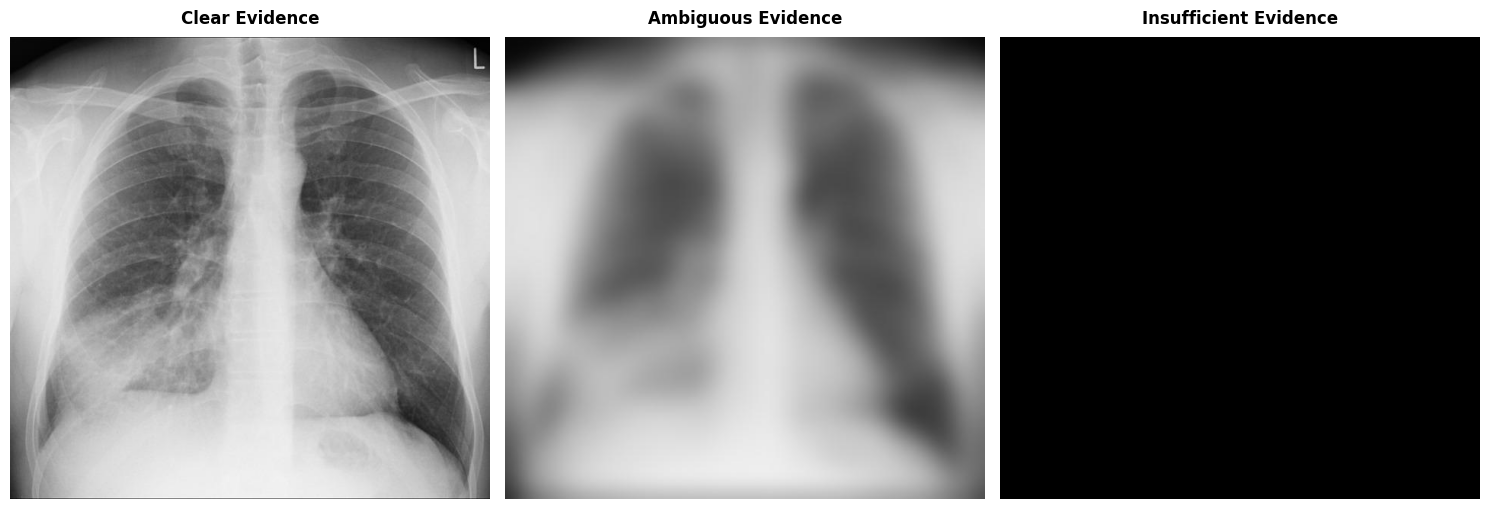

In [ ]:
# Instantiate the local paths and compile prompts
my_image = "./chest_xray.jpeg"
pneumonia_prompts = [
    "<image> Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",
    "<image> Briefly describe the diagnosis for this chest X-ray image.",
    "<image> Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly"
]

multimodal_test_set = generate_multimodal_perturbations(source_path=my_image)
display_multimodal_perturbations(multimodal_test_set)


The code block below initializes your execution environment by simultaneously loading backbones for both the **UQLM** and **LM-Polygraph** frameworks under a single, unified master context manager.

You can easily swap out these default targets at any time. Simply replace the model identifier strings—such as changing `"google/paligemma-3b-mix-224"` to another valid Hugging Face repository path, or `"llava"` and `"ollama"` to your preferred model and provider.




In [ ]:
# 1. Define the UQLM configurations registry block
uqlm_models = {
    "llava": {
        "provider": "ollama",
        "model_id": "llava"
    }
}

# 2. Initialize the environment passing BOTH framework configurations
uq_engine = setup_uq_environment(
    polygraph_models="google/paligemma-3b-mix-224",
    polygraph_is_multimodal=True,
    p_mode="white",
    u_mode="white",
    quant_choice="4bit",
    #uqlm_models=uqlm_models,
    polygraph_kwargs={
        "trust_remote_code": True
    },
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Setting up lm_polygraph [DEFAULT] in WHITE-BOX mode...
Paste your Hugging Face Token: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.26M [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]


✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


## **2. Build the Multimodal UQ Pipeline**


We implement an asynchronous loop orchestration layer `run_multimodal_uq` that walks through each visual state, injects the image path into our model context, and tracks how the metrics shift under degradation.




In [ ]:
# =====================================================================
# 3. HIGH-LEVEL PIPELINE EXECUTION ENGINE
# =====================================================================

async def run_multimodal_uq(
    techniques: List[str],
    test_set: Dict[str, str],
    prompts: List[str],
    uq_context: Any,
    granularity: str = "sequence",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> Dict[str, pd.DataFrame]:
    """
    Executes a multimodal stress-test matrix over a collection of UQ techniques and prompts.
    Isolates hyperparameter configurations per individual technique via technique_kwargs routing.
    """
    condition_tables_data = {
        cond.replace("_", " ").title(): [] for cond in test_set.keys()
    }

    tech_kwargs_map = technique_kwargs or {}

    for condition, img_path in test_set.items():
        clean_condition = condition.replace("_", " ").title()

        for technique in techniques:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            specific_args = tech_kwargs_map.get(technique, {})
            merged_kwargs = {**kwargs, **specific_args}

            for prompt in prompts:
                try:
                    # L'immagine viene inoltrata; i selettori interni stabiliranno l'attivazione cross-modale
                    result = await evaluate_uncertainty(
                        prompt=prompt,
                        technique_name=technique,
                        granularity=granularity,
                        uq_context=uq_context,
                        image_path=img_path,
                        **merged_kwargs
                    )

                    raw_text = result.get("generated_text", "No response").strip()
                    raw_score = result.get("uncertainty_score", 0.0)

                    if isinstance(raw_score, list):
                        extracted_scores = [float(item["score"]) for item in raw_score if "score" in item]
                        if extracted_scores:
                            mean_score = np.mean(extracted_scores)
                            formatted_score = f"List (Mean: {mean_score:.4f})"
                        else:
                            formatted_score = "[]"
                    else:
                        formatted_score = f"{float(raw_score):.4f}"

                except Exception as e:
                    raw_text = f"Execution Failure: {str(e)}"
                    formatted_score = "N/A"

                condition_tables_data[clean_condition].append({
                    "UQ Technique": technique.replace("polygraph_", "").replace("uqlm_", "").upper(),
                    "Question": prompt.replace("<image>", "").strip(),
                    "Response": raw_text,
                    "Score": formatted_score
                })

    final_dataframes = {}
    for condition, rows in condition_tables_data.items():
        df = pd.DataFrame(rows)
        display(HTML(f"<br><h3 style='color: #1f77b4; font-family: Arial;'>📊 Visual Condition: {condition}</h3>"))
        display(df)
        final_dataframes[condition] = df

    return final_dataframes


---

## **3. Scorer Paradigms & Implementation**

### **A. Sample Diversity Paradigm**



Sample Diversity evaluates a model's confidence by assessing the consistency across $K$ independent, stochastic responses generated at temperature $T > 0$. If a VLM is certain, independent paths converge; if uncertain, they diverge.

* **Black-Box Sample Diversity:** Measures consistency across $K$ generated text responses when internal model access is restricted by providers . This category operates via a shared 3-step framework : first, it samples $K$ outputs $y^{(1)}, \dots, y^{(K)}$ for an input $x$; second, it builds a $K \times K$ similarity matrix $S$ using pairwise textual scores $s(y^{(i)}, y^{(j)})$ (such as NLI or Jaccard); third, it analyzes and aggregates the matrix information to compute the final uncertainty score.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1h-SHUTZvrhHUKtNGFqQl2s_zGrXOj-cT)
* **White-Box Sample Diversity**: Operates at the model's predictive output layer during stochastic generation. Instead of analyzing only the finalized surface text, it extracts and aggregates sequence, word, or token-level probabilities across the $K$ forward passes to measure distributional divergence
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1cgYqMflwesud-bK_IAeKQx7QBpSDApKs)




#### **Core Available Techniques**

| Method | Mechanism | Framework | Type |
| --- | --- | --- | --- |
| **NumSemSets** | Clusters $K$ responses using a bi-directional NLI model to count unique semantic sets. | `lm-polygraph` | Black-Box |
| **DegMat** | Constructs a text similarity graph and computes uncertainty via the Graph Laplacian. | `lm-polygraph` | Black-Box |
| **Eccentricity** | Measures the distance of sentence embeddings from the central semantic cluster. | `lm-polygraph` | Black-Box |
| **Semantic Entropy** | Computes Shannon entropy over semantic clusters using token log-likelihoods. | `lm-polygraph` | White-Box |
| **EigenScore** | Evaluates the log-determinant of the covariance matrix derived from the hidden layer embeddings. | `lm-polygraph` | White-Box |
| **Non-Contradiction Prob** | Computes the mean non-contradiction probability estimated by a secondary logical NLI cross-encoder. | `uqlm` | Black-Box |
| **Semantic Sets Conf** | Measures clustering consensus by partitioning $K$ textual outputs via an NLI model without logprobs. | `uqlm` | Black-Box |
| **Semantic Negentropy** | Calculates Shannon entropy over discrete generation clusters derived strictly from textual frequency. | `uqlm` | Black-Box |
| **Monte Carlo Prob** | Aggregates and averages joint token log-probabilities over $K$ separate forward passes. | `uqlm` | White-Box |
| **CoCoA** | Multiplies length-normalized token probabilities by semantic embedding similarities across $K$ samples. | `uqlm` | White-Box |

#### **Paradigm Features**

| Metric Sub-Family | Inference Cost | Image Degradation Resilience |
| :--- | :--- | :--- |
| **Black-Box Diversity** | High ($K$ VLM generations + $O(K^2)$ NLI calls) | **High.** Directly registers when a blurred image creates semantic confusion across sampled texts. |
| **White-Box Diversity** | High ($K$ structural passes extracting logprobs). | **Medium.** Vulnerable to *Language Prior Saturation* if the image becomes completely uninformative. |



#### **Run Sample Diversity Pass**



#### *LM-Polygraph Sample diversity Black-Box Implementation*

Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm_polygraph", mode="black", category="Sample diversity")

In [ ]:
# 1. Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_blackbox = [
    "polygraph_NumSemSets",
    "polygraph_DegMat",
    "polygraph_Eccentricity"
]

await run_multimodal_uq(
    techniques=sample_diversity_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,4.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,5.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",tuberculosis,5.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.3268
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,tuberculosis,0.1072
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",copd,0.7523
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,2.0000
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,lung cancer,1.4142
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",copd,2.8284


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,4.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Obstruction,3.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.4239
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,ae,0.5967
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's disease,0.6516
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.7323
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,2.0000
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alose,2.0008


,UQ Technique,Question,Response,Score
0,NUMSEMSETS,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,3.0000
1,NUMSEMSETS,Briefly describe the diagnosis for this chest X-ray image.,blank image,2.0000
2,NUMSEMSETS,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,3.0000
3,DEGMAT,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,0.4774
4,DEGMAT,Briefly describe the diagnosis for this chest X-ray image.,blank image,0.4212
5,DEGMAT,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",acute respiratory distress syndrome.,0.6870
6,ECCENTRICITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1.4144
7,ECCENTRICITY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,1.0000
8,ECCENTRICITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,2.2362


#### *LM-Polygraph Sample diversity White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm_polygraph", mode="white", category="Sample diversity")


In [ ]:
# 1. Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_whitebox = ["polygraph_EigenScore", "polygraph_SemanticEntropy"]
await run_multimodal_uq(
    techniques=sample_diversity_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);




/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.","yes, pneumonia",7.6359
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,lung disease,7.5728
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia,7.5922
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-91.6537
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-73.0831
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",obesity,-64.7999


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,7.6370
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,7.6191
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",asthma,7.6784
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-81.2707
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-61.5357
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic respiratory disease,-77.9581


,UQ Technique,Question,Response,Score
0,EIGENSCORE,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,7.6250
1,EIGENSCORE,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,7.6143
2,EIGENSCORE,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's disease,7.5947
3,SEMANTICENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-62.6699
4,SEMANTICENTROPY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-70.9730
5,SEMANTICENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic lung disease,-69.8030


#### *UQLM Sample diversity Black-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="black", category="Sample diversity")

In [ ]:
uqlm_blackbox_techniques = [
    "uqlm_noncontradiction",
    "uqlm_semantic_sets_confidence",
    "uqlm_semantic_negentropy"
]

await run_multimodal_uq(
    techniques=uqlm_blackbox_techniques,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence",
);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a hum...,0.8541
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,"This is an X-ray of a human torso, specificall...",0.6922
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image shows an X-ray of a person's chest. ...,0.9810
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image shows a chest X-ray film placed with...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,"The image you've shown is of an X-ray, specifi...",1.0000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you provided shows an anatomical che...,1.0000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a hum...,0.3978
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.5158
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided displays a lateral-c...,0.7485


,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image you've provided is an X-ray of a per...,0.9968
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,"A black and white X-ray image is displayed, sh...",0.9899
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image depicts an X-ray of a human chest. T...,0.9114
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.6000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,"The image shows a set of X-rays, focusing main...",0.8000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image shows a patient's chest X-ray with a...,0.3960
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4562
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image provided appears to be a chest X-ray...,0.5158


,UQ Technique,Question,Response,Score
0,NONCONTRADICTION,Is there pneumonia in this chest X-ray? Answer...,The image appears to be a black and white X-ra...,0.9055
1,NONCONTRADICTION,Briefly describe the diagnosis for this chest ...,The image you provided is too small and blurry...,0.9941
2,NONCONTRADICTION,Based on the pulmonary opacities and costophre...,The image you've provided is very small and of...,0.9966
3,SEMANTIC_SETS_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image shows a black and white chest radiog...,0.4000
4,SEMANTIC_SETS_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image shows a black and white representati...,0.2000
5,SEMANTIC_SETS_CONFIDENCE,Based on the pulmonary opacities and costophre...,"The image you've provided is black and white, ...",0.6000
6,SEMANTIC_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,I'm unable to analyze medical images as part o...,0.2993
7,SEMANTIC_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image appears to be a cropped portion of a...,0.2684
8,SEMANTIC_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image appears to be a digital X-ray or CT ...,0.4666


#### *UQLM Sample diversity White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="white", category="Sample diversity")

In [ ]:
# 2. Execute UQLM White-Box Sample Diversity
uqlm_whitebox_techniques = ["uqlm_monte_carlo_probability", "uqlm_consistency_and_confidence"]
await run_multimodal_uq(
    techniques=uqlm_whitebox_techniques,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.3114
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.3009
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image you've provided is an X-ray film of ...,0.3295
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,This is an X-ray image of a human chest. The i...,0.2858
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The provided image shows a side view of human ...,0.2704
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image shows a chest X-ray with several are...,0.3881


,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be an X-r...,0.3285
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a CT s...,0.3047
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to be a chest X-ray showing ...,0.3739
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,"No, there is no evidence of pneumonia on the p...",0.4363
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've shared appears to be a chest ...,0.3425
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you've provided appears to be an X-r...,0.3697


,UQ Technique,Question,Response,Score
0,MONTE_CARLO_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,"Based on the image provided, it appears to be ...",0.3372
1,MONTE_CARLO_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a ches...,0.3455
2,MONTE_CARLO_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show a view of a chest X-...,0.3331
3,CONSISTENCY_AND_CONFIDENCE,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a blac...,0.3489
4,CONSISTENCY_AND_CONFIDENCE,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4269
5,CONSISTENCY_AND_CONFIDENCE,Based on the pulmonary opacities and costophre...,The image you've provided appears to show a me...,0.4132



---

### **B. Information-Based Paradigm**

Information-Based UQ evaluates model confidence by extracting token probabilities, structural weights, or sequence likelihoods.

* **White-Box Information UQ**: Runs optimally on exactly one deterministic forward pass ($K = 1$). It operates efficiently by parsing the internal token logit distribution or hidden layer state residuals along the generated predictive path.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1epOsaYB5NFXrOb73JRC9pLp71ZMnWJD5)


* **Black-Box Information UQ:** Functions as a hybrid proxy; because it lacks access to logits, it must sample the model stochastically ($K > 1$) to empirically reconstruct sequence likelihood based on surface text generation frequency.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1n0XmNRXsnaINZItCSQEbcx-FR12zKRMW)


#### **Core Available Techniques**

| Method | Mechanism | Framework | Type |
| --- | --- | --- | --- |
| **LabelProb** | Approximates sequence probability via the empirical frequency of the identical string across samples. | `lm-polygraph` | Black-Box |
| **Max Sequence Prob** | Computes the unnormalized joint cumulative log-probability of the single chosen token path. | `lm-polygraph` | White-Box |
| **Mean Token Entropy** | Calculates the average Shannon entropy across the entire vocabulary logit distribution for every token. | `lm-polygraph` | White-Box |
| **Attention Score** | Extracts and aggregates internal layer-wise attention weights across cross-modal execution paths. | `lm-polygraph` | White-Box |
| **Sequence Probability** | Computes the joint token log-likelihood over the sequence, with optional length-normalization. | `uqlm` | White-Box |
| **Probability Margin** | Measures the average numerical distance between the top-1 predicted token logit and the runner-up top-2 logit. | `uqlm` | White-Box |
| **Mean Token Negentropy** | Computes the negative Shannon entropy over the vocabulary distribution to provide a confidence index. | `uqlm` | White-Box |


#### **Paradigm Features**

| Metric Sub-Family | Box Type Availability | Core Operational Mechanism | Inference Cost | Image Degradation Resilience |
| --- | --- | --- | --- | --- |
| **Token/Logit-Space** | **White-Box** | Parses internal vocabulary distributions, top-token logit margins, or cumulative joint log-probabilities along the predicted path. | Minimal<br><br>($K = 1$ Forward Pass) | **Low.** Vulnerable to the *Fluent Hallucination Blindspot*, registering absolute certainty for incorrect but grammatically fluent answers smoothed by language priors. |
| **Text-Frequency Proxy** | **Black-Box** | Empirically reconstructs sequence likelihood by calculating the relative generation frequency of identical strings across multiple stochastic outputs. | Moderate to High<br><br>($K > 1$ Sampling Passes) | **Low to Medium.** Captures linguistic sampling instability, but collapses under the *Language Prior Refusal Trap* if visual decay causes generations to converge on uniform fallback phrases. |
| **Attention-Space** | **White-Box** | Probes internal cross-attention layer weights (`polygraph_attention`) to map the structural alignment between decoded text tokens and spatial image patches. | Minimal<br><br>($K = 1$ Forward Pass) | **Maximum.** Escapes text-level smoothing by directly capturing cross-modal architectural stress when tokens fail to anchor inside the visual grid. |

#### **Run Information-Based Pass**




#### *LM_Polygraph Informaation-Based Black-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm-polygraph", mode="black", category="Information-based")

In [ ]:
# 1. Execute LM-Polygraph Hybrid Black-Box Information Metrics
information_based_blackbox = ["polygraph_LabelProb"]
await run_multimodal_uq(
    techniques=information_based_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,0.5000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,0.4000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,0.7000


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,0.4000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,0.7000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia,0.8000


,UQ Technique,Question,Response,Score
0,LABELPROB,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,0.3000
1,LABELPROB,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,0.1000
2,LABELPROB,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",obesity,0.7000


#### *LM_Polygraph Informaation-Based White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="lm-polygraph", mode="white", category="Information-based")

In [ ]:
information_based_whitebox = ["polygraph_Attention"]


await run_multimodal_uq(
    techniques=information_based_whitebox,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,1653.7112
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,1603.1955
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Alveolmonary disease.,1716.1512


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1617.5682
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,1571.4148
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",epilepsy,1658.9017


,UQ Technique,Question,Response,Score
0,ATTENTION,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,1711.9583
1,ATTENTION,Briefly describe the diagnosis for this chest X-ray image.,blank image,1649.7738
2,ATTENTION,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia.,1739.4162


In [ ]:
information_based_whitebox = ["polygraph_MaximumSequenceProbability", "polygraph_MeanTokenEntropy"]
await run_multimodal_uq(
    techniques=information_based_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-40.2790
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-64.3080
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic lung disease,-67.8460
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",yes,-60281016320.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-2417917427712.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",pneumonia.,-297987211264.0000


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-40.2790
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-60.9821
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",chronic respiratory disease,-71.2500
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-42438811648.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,pneumonia,-1098226008064.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Asbestos.,-2747846144.0000


,UQ Technique,Question,Response,Score
0,MAXIMUMSEQUENCEPROBABILITY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",no,-39.4085
1,MAXIMUMSEQUENCEPROBABILITY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-75.5357
2,MAXIMUMSEQUENCEPROBABILITY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",Obstructive pneumonia.,-98.5045
3,MEANTOKENENTROPY,"Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis.",unanswerable,-11673086976.0000
4,MEANTOKENENTROPY,Briefly describe the diagnosis for this chest X-ray image.,unanswerable,-5517813760.0000
5,MEANTOKENENTROPY,"Based on the pulmonary opacities and costophrenic angles visible in this image, what clinical diagnosis can be inferred? Answer briefly",alzheimer's,-4110428160.0000


#### *UQLM Informaation-Based White-Box Implementation*
Check other techniques in this category that you can try by using our utility function:
```python
show_help(library="uqlm", mode="white", category="Information-based")

In [ ]:
# 3. Execute UQLM White-Box Single-Pass Metrics
uqlm_info_whitebox = ["uqlm_sequence_probability", "uqlm_probability_margin", "uqlm_mean_token_negentropy"]
await run_multimodal_uq(
    techniques=uqlm_info_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/scorers/shortform/white_box.py:227: UQLMBetaWarning: Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.
  beta_warning("Scorers based on top_logprobs ('mean_token_negentropy','min_token_negentropy','probability_margin') is in beta. Please use with caution as it may change in future releases.")


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,"Yes, there is evidence of pneumonia visible on...",0.4532
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.4264
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image you've provided is an X-ray of a hum...,0.4616
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,"Based on the image provided, it appears to be ...",0.6200
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.5431
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,The image shows a lateral chest X-ray of an in...,0.5673
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image shows an X-ray of a human chest with...,0.6600
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,This is an X-ray image of a human chest. The X...,0.6395
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided appears to show an X...,0.6591


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to show a ch...,0.3870
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be an X-r...,0.4363
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show an X-ray of a chest ...,0.4912
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,"Yes, there is evidence of a condition that loo...",0.5665
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image appears to be an X-ray of a human to...,0.5674
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,This appears to be a medical X-ray image. The ...,0.4994
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a medi...,0.6557
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a medi...,0.6807
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided appears to show an X...,0.6697


,UQ Technique,Question,Response,Score
0,SEQUENCE_PROBABILITY,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a ches...,0.5503
1,SEQUENCE_PROBABILITY,Briefly describe the diagnosis for this chest ...,The image you've provided is a black and white...,0.4653
2,SEQUENCE_PROBABILITY,Based on the pulmonary opacities and costophre...,The image appears to show a side view of an X-...,0.4227
3,PROBABILITY_MARGIN,Is there pneumonia in this chest X-ray? Answer...,The image you've provided appears to be a blac...,0.5737
4,PROBABILITY_MARGIN,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a text...,0.6265
5,PROBABILITY_MARGIN,Based on the pulmonary opacities and costophre...,The image you've provided appears to be an X-r...,0.5414
6,MEAN_TOKEN_NEGENTROPY,Is there pneumonia in this chest X-ray? Answer...,The image you provided appears to be a black a...,0.5999
7,MEAN_TOKEN_NEGENTROPY,Briefly describe the diagnosis for this chest ...,The image you've provided appears to be a ches...,0.7076
8,MEAN_TOKEN_NEGENTROPY,Based on the pulmonary opacities and costophre...,The image you've provided is a chest X-ray. An...,0.6242


### **C. Ensemble Uncertainty Quantification (UQ)**

Ensemble scorers provide more robust and calibrated uncertainty estimates by combining diverse statistical perspectives from multiple individual estimators. By integrating methods such as semantic overlap and raw token probabilities, ensembles significantly reduce calibration error on complex, open-ended tasks. This architectural approach offers high flexibility and customizability, allowing you to tailor the ensemble's bias to specific clinical use cases by combining any mix of black-box and white-box scorers. Note that the ensemble inherits the latency and cost of all its component scorers.

#### **How it Works**

The core functioning of an ensemble scorer relies on a mathematical framework that aggregates individual results into a unified confidence metric. Given a set of $n$ component scorers with individual scores $s_k(y_i)$ and their corresponding normalized weights $w_k$, where:

$$\sum_{k=1}^n w_k = 1$$

The finalized ensemble prediction uncertainty score for a generated output $y_i$ is formally calculated as:

$$\text{Ensemble}(y_i) = \sum_{k=1}^n w_k \cdot s_k(y_i)$$

#### **Optimization Prerequisites**

The optimization runtime uses a labeled calibration dataset to navigate the hyperparameter landscape and automatically discover the optimal combination of weights $w_k$. To successfully tune the ensemble, you require:

* **Labeled Calibration Data:** A training partition (`train_df`) containing explicit input questions paired with their definitive **ground-truth answers**.
* **A Grader Function (`grader_function`):** A custom programmatic rule (such as case-insensitive substring matching or semantic alignment) used by the optimization engine to dynamically evaluate whether the model's sampled generations are correct or incorrect against the ground-truth annotations.

> ⚠️ **Crucial Architectural Constraints for Multimodal Setup:**
> * **Exclusive to UQLM:** Structural multi-scorer generalized ensembles are strictly supported by the `uqlm` backend framework. The `lm_polygraph` backend does not natively support joint Optuna weight tuning or ensemble blending for vision-language inputs.
> * **No LLM-as-a-Judge Components:** Unlike pure textual pipelines, **LLM-as-a-Judge metrics are not available** in this multimodal workflow due to context parsing limitations over interleaved visual tokens. The ensemble is composed strictly of black-box and white-box scorers.
>
>


>![Ensamble](https://drive.google.com/uc?export=view&id=1RFwZaakt3U30gAi0uDHi9-Ugji-M-jt0)


#### **Custom Grader Function**

The tuning engine requires a deterministic rule to verify output accuracy during optimization trials. Because Vision-Language Models (VLMs) often generate verbose or conversational answers, exact string matching (`==`) fails.

* **The Grader Contract:** The function must accept `(response, answer)` and strictly return `True` if the output is correct relative to the ground-truth label, and `False` otherwise.

We implement a case-insensitive symmetric substring match to eliminate false negatives caused by conversational VLM padding.




In [ ]:
import os
import base64
from typing import List, Union, Optional, Any
from langchain_core.messages import HumanMessage
# =====================================================================
# 🎯 ENSEMBLE GRADER EVALUATION RULE
# =====================================================================
def grade_response(response: str, answer: str) -> bool:
    """
    Executes a symmetric case-insensitive substring verification matching rule.
    Prevents false negatives caused by conversational VLM verbose responses.
    """
    resp_clean = str(response).strip().lower()
    ans_clean = str(answer).strip().lower()
    return ans_clean in resp_clean or resp_clean in ans_clean



### **Training Phase: Calibration & Joint Tuning**

The training routine uses a labeled calibration dataset to map the decision space. It is divided into two operational steps: loading the target dataset data structures, and executing the asynchronous Optuna optimization engine.

#### **Step 1: Multimodal Dataset Loading & Partitioning**

We load clinical VQA samples directly from the Hugging Face Hub. The data engine detects visual assets dynamically, converts them to stable base64 memory encodings, and yields strictly isolated, leakage-free calibration (Train) and evaluation (Test) pools.

You can use your own datset by modyfing the `path` variable

*Note:*  We load just 40 samples for computational efficiency of the tutorial but you need > 1000 samples for a better calibration of the weights.

In [ ]:
gc.collect()
torch.cuda.empty_cache()

# Load clinical partitions (e.g., flaviagiammarino/vqa-rad) using the native hybrid processing engine
train_df, test_df = prepare_dataset(
    path="flaviagiammarino/vqa-rad",
    max_samples=40,
    test_size=0.33,
    random_state=42
)

⏳ Loading clinical dataset directly from Hugging Face Hub (flaviagiammarino/vqa-rad)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

📊 Dataset processing complete via native Hybrid Engine!
   └── Operational Mode: MULTIMODAL (Vision-Language)
   └── 📈 Train size (Calibration Fitting Pool): 26 samples
   └── 📉 Test size (Holdout Evaluation Pool):  14 samples



### **Step 2: Calibration Phase: Joint Ensemble Tuning Pipeline**

To find the absolute best contribution weight for each uncertainty metric, we cannot rely on manual guessing. The `run_ensemble_tuning_pipeline` function automates this by wrapping the calibration process into a structured, step-by-step optimization sequence.

The underlying pipeline follows a strict four-step logical execution path with a direct focus on configuring our core **`UQEnsemble`** engine and triggering its **`.tune()`** loop:

> 1. The function transforms raw dataset text queries and base64 imagery into LangChain-compatible multimodal message arrays using the `_prepare_uqlm_execution_prompts` helper.

> 2.  It evaluates the requested `model_alias` against the available `uq_engine.langchain_llms` keys to safely resolve and mount the correct Vision-Language Model backend instance.

> 3. **`UQEnsemble` Instantiation:** The core manager is initialized by creating a `UQEnsemble` object. This container binds your selected collection of active metrics (`uqlm_scorers`) directly to the base language model while offloading complex text entailment tasks to a local, memory-efficient DeBERTa NLI companion model.

> 4. **Automated Joint Tuning (`.tune()`):** The pipeline invokes the asynchronous `.tune()` method to kick off a black-box hyperparameter search powered by Optuna. Over the course of the specified optimization trials, this loop iteratively adjusts individual scorer weights and isolates the absolute optimal operational decision threshold before extracting the final calibrated `.weights` and `.thresh` properties.ning the configuration parameters.

---























This optimization phase simultaneously calibrates two critical operational variables:



> 1. **Scorer Weights ($w_k$):** The relative importance and mathematical scaling assigned to each active metric. While this example utilizes `semantic_sets_confidence`, `sequence_probability`, and `exact_match`, you can customize your own combination of black-box and white-box scorers.
>
>




>2. **Operational Decision Threshold:** The specific confidence boundary below which the model's response is flagged as untrustworthy or rejected.


In [ ]:
# Scorer Components
uqlm_scorers = ["semantic_sets_confidence", "sequence_probability", "exact_match"]

In [ ]:
import pandas as pd
from typing import List, Dict, Any, Tuple
from uqlm import UQEnsemble

async def run_ensemble_tuning_pipeline(
    train_df: pd.DataFrame,
    uqlm_scorers: List[str],
    uq_engine: Any,
    model_alias: str = "default",
    weights_objective: str = "accuracy_score",
    thresh_objective: str = "accuracy_score",
    num_responses: int = 5,
    n_trials: int = 25,
    **kwargs
) -> Tuple[Dict[str, float], float]:
    """
    Encapsulates the uqlm ensemble optimization pipeline.
    Prepares multimodal calibration frames, resolves the targeted driver via alias fallback
    mappings, executes joint parameter tuning via Optuna, and returns optimized metric
    weights and operational decision thresholds.
    """
    print(f"🔄 Preparing multimodal message inputs for {len(train_df)} calibration samples...")

    # 1. Standardize and transform raw inputs into LangChain-compatible VLM structures
    tune_prompts = [
        _prepare_uqlm_execution_prompts(
            prompts_list=[f"<image>\n{row['question']}"],
            image_base64=row["image_base64"]
        )[0]
        for _, row in train_df.iterrows()
    ]
    tune_answers = train_df["answer"].tolist()

    # 2. Resolve the language model backend driver honoring the standardized fallback strategy
    if model_alias == "default" and "default" not in uq_engine.langchain_llms:
        available_models = list(uq_engine.langchain_llms.keys())
        if len(available_models) == 1:
            model_alias = available_models[0]

    if model_alias not in uq_engine.langchain_llms:
        raise KeyError(
            f"The requested model alias '{model_alias}' is not initialized inside uq_engine.langchain_llms."
        )

    base_llm = uq_engine.langchain_llms[model_alias]

    # 3. Instantiate the ensemble orchestration manager with local NLI offloading
    uqe_tuning = UQEnsemble(
        llm=base_llm,
        max_calls_per_min=1000,
        scorers=uqlm_scorers,
        device="cpu",
        nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
    )

    print(f"🚀 Launching automated joint optimization search landscape (Trials: {n_trials}, Model Alias: '{model_alias}')...")

    # 4. Invoke the black-box search routine to isolate optimal hyperparameter boundaries
    await uqe_tuning.tune(
        prompts=tune_prompts,
        ground_truth_answers=tune_answers,
        grader_function=grade_response,
        num_responses=num_responses,
        weights_objective=weights_objective,
        thresh_objective=thresh_objective,
        n_trials=n_trials,
        **kwargs
    )

    # Harvest tuned parameters directly from the calibrated object attributes
    optimized_weights = uqe_tuning.weights
    optimal_threshold = uqe_tuning.thresh

    print("\n🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!")
    print(f"Optimized Scorer Weights: {optimized_weights}")
    print(f"Calibrated Threshold:     {optimal_threshold}\n")

    return optimized_weights, optimal_threshold

🤖 Generation                                                                                                    
    - Generating responses...                                    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:04:00
    - Generating candidate responses (5 per prompt)...           ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130/130 0:09:09
                                                                                                                   
  📈 Scoring                                                                                                       
    - Scoring responses with semantic clustering...              ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:31
    - Scoring responses with exact match...                      ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:00
                                                                                                                   
  ⚙️ Optimization                                                                                                   
    - Grading responses against provided ground truth answers... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26/26   0:00:00
    - Optimizing weights...                                      ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100%    0:00:00

Optimized Ensemble Weights         

==================================================

Scorer                            Weight

--------------------------------------------------

semantic_sets_confidence          0.3947

sequence_probability              0.3689

exact_match                       0.2365

==================================================


🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!
Optimized Scorer Weights: (0.3946690426182008, 0.36885796890434835, 0.23647298847745085)
Calibrated Threshold:     0.5233180028384224


In [ ]:
# Execute the pipeline and register the optimized parameter boundaries globally
OPTIMIZED_WEIGHTS, OPTIMAL_THRESHOLD = await run_ensemble_tuning_pipeline(
    train_df=train_df,
    uqlm_scorers=uqlm_scorers,
    uq_engine=uq_engine,
    weights_objective="accuracy_score",
    thresh_objective="accuracy_score",
    num_responses=5,
    n_trials=25
)

##### **Understanding the Core Optimization Parameters:**

> * **`weights_objective`** *(str, default=`'roc_auc'`)*: Sets the mathematical objective function utilized by Optuna to discover the optimal scorer weight distribution. You can pass any of the following metrics:
    * `'roc_auc'`: Optimizes for the best discrimination capability across all potential decision cutoffs (ideal for continuous calibration).
    * `'log_loss'` / `'brier_score'`: Minimizes probabilistic error, forcing the uncertainty scores to reflect true error probabilities.
    * `'average_precision'`: Maximizes the area under the precision-recall curve, highlighting performance on minority target classes.
    * `'accuracy_score'` / `'balanced_accuracy_score'` / `'fbeta_score'`: Optimizes weights directly against hard, discrete decision boundaries.

> * **`thresh_objective`** *(str, default=`'fbeta_score'`)*: Specifies the evaluation metric used to isolate the operational cutoff boundary via an internal grid search. The supported discrete metrics are:
    * `'fbeta_score'`: Balances precision and recall (highly customizable for balancing clinical sensitivity and specificity).
    * `'accuracy_score'`: Maximizes the absolute percentage of correctly classified instances.
    * `'balanced_accuracy_score'`: Adjusts accuracy to account for severe class imbalances in the dataset.

> * **`thresh_bounds`** *(tuple of floats, default=`(0, 1)`)*: A tuple of floats defining the bounded search domain for the optimization grid search.

> * **`num_responses=5`**: Instructs the engine to generate 5 independent sampled responses per calibration prompt. This generation pool is required by white-box and black-box consistency scorers (like `semantic_sets`) to calculate response entropy and cluster variance.

>* **`n_trials=25`**: The total number of black-box optimization iterations Optuna will run to navigate the hyperparameter space and converge on the global maximum.


---



### **Testing Phase: Holdout Evaluation Pipeline**

After locking in our optimal configuration parameters during calibration, we proceed to the **Testing Phase** to evaluate the model's performance on a completely unseen, holdout dataset.

To verify our uncertainty metrics without any further parameter adjustments, the `run_ensemble_evaluation_pipeline` function coordinates the benchmarking matrix through a strict, four-step sequential execution logic:

> 1.  The function initiates a linear loop over the holdout test set (`test_df`), strictly preserving the direct 1-to-1 pairing between each diagnostic visual asset and its corresponding clinical question.

> 2. For each row, the loop dynamically formats the textual query by prepending the essential cross-modal `<image>` token and maps it alongside the raw base64 visual payload.

> 3. These structured arguments are systematically dispatched to our high-level entry wrapper API, `evaluate_uncertainty`, which triggers the backend models to extract both the generated response and the raw uncertainty scores.
4.The pipeline standardizes polymorphic metric schemas (such as calculating the mean score from word-level token arrays into clean aggregate metrics), appends the formatted data to a centralized list (`results_pool`), and instantiates the final structured `pd.DataFrame` for downstream analysis.

In [ ]:
from IPython.display import display, HTML

async def run_ensemble_evaluation_pipeline(
    test_df: pd.DataFrame,
    techniques: List[str],
    uq_context: Any,
    granularity: str = "sequence",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> pd.DataFrame:
    """
    Executes a structured evaluation benchmark by delegating inference to the core
    extract_raw_uq_scores subroutine, formatting polymorphic data types, and rendering
    the final comparative metrics framework.
    """
    print(f"🚀 Initializing linear VQA assessment over {len(test_df)} holdout test items...")

    # 1. Delegate the entire collection and inference logic to the universal subroutine
    raw_data = await extract_raw_uq_scores(
        dataset=test_df,
        uq_techniques=techniques,
        uq_context=uq_context,
        granularity=granularity,
        tech_kwargs_registry=technique_kwargs,
        **kwargs
    )

    results_pool = []

    # 2. Re-map the clean dictionary records into the structured evaluation pool
    for technique, data in raw_data.items():
        tech_label = technique.replace("polygraph_", "").replace("uqlm_", "").upper()

        for idx in range(len(data["scores"])):
            raw_score = data["scores"][idx]

            # Process polymorphic data structure conversions safely (e.g., token-level lists)
            if isinstance(raw_score, list):
                extracted_scores = [float(item["score"]) for item in raw_score if "score" in item]
                formatted_score = f"{np.mean(extracted_scores):.4f}" if extracted_scores else "0.0000"
            else:
                formatted_score = f"{float(raw_score):.4f}"

            results_pool.append({
                "Sample ID": idx,
                "UQ Technique": tech_label,
                "Question": data["questions"][idx].strip(),
                "Ground Truth": data["ground_truths"][idx],
                "Model Response": data["responses"][idx],
                "UQ Score": formatted_score
            })

    # 3. Compile and display the final matrix representation
    final_df = pd.DataFrame(results_pool)
    display(HTML(f"<br><h3 style='color: #2ca02c; font-family: Arial;'>📈 Matrix Evaluation Results</h3>"))
    display(final_df)

    return final_df

In [ ]:
ensemble_techniques = ["uqlm_generalized_ensemble"]

# Setting for visualization
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Run blind performance validation over the holdout testing targets
vqa_outputs_df = await run_ensemble_evaluation_pipeline(
    test_df=test_df,
    techniques=ensemble_techniques,
    uq_context=uq_engine,
    granularity="sequence",
    ensemble_scorers=uqlm_scorers,
    weights=OPTIMIZED_WEIGHTS,
    thresh= OPTIMAL_THRESHOLD
)

🚀 Initializing linear VQA assessment over 14 holdout test items...


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

...

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

,Sample ID,UQ Technique,Question,Ground Truth,Model Response,UQ Score
0,0,GENERALIZED_ENSEMBLE,is the bowel obstructed?,yes,"The image you've provided appears to show an X-ray of a person with a bowel obstruction. The X-ray is labeled as ""Medpix,"" suggesting it could be part of medical imaging software or a service related to medical imaging. Bowel obstructions are common conditions, often caused by scar tissue, adhesions, or tumors that can obstruct the passage of digestive material through the intestine. This type of imaging is typically used in hospitals and medical practices for diagnosis and treatment planning. If you have concerns about this image or need assistance with a similar situation, it's important to speak with a healthcare professional.",0.3149
1,1,GENERALIZED_ENSEMBLE,which organ contains the air-fluid level?,stomach,"The image shows an X-ray of a patient's abdomen. In this type of radiography, bones are rendered as dark and dense regions, while soft tissues can appear more translucent or white. This particular X-ray appears to have been taken from the side angle with the back of the patient facing the X-ray plate.\n\nVarious organs are labeled in both Latin and English. From left to right, we can identify bones including the ribs (osteum costae), vertebrae, pelvis, and some small bones that could possibly be part of the sternum or hip joints. The darker shades might represent muscle mass or fat, although the definition in an X-ray is not as fine as in a CT scan. Larger white areas may represent less dense tissues such as bone marrow or fat.\n\nThe purpose of this X-ray could be to diagnose various medical conditions like fractures, dislocations, or the presence of foreign objects that need to be removed surgically. The exact reason for this particular image is not clear without additional context.",0.2261
2,2,GENERALIZED_ENSEMBLE,is a fracture present?,no,"This is an image of a CT scan showing the interior of a human head, specifically focusing on the brain and the base of the skull. The CT scan appears to be detailed, with clear visualization of internal structures. However, without medical expertise or context to interpret the data, it's difficult to determine from this image whether there is anything specific to note about the brain structure visible here. It also appears that there is a watermark with the word ""MEDPIX"" across the image, indicating that it might have been created or hosted by medpix.",0.2453
3,3,GENERALIZED_ENSEMBLE,does the pancreatic head appear enlarged?,yes,"The image you provided appears to be a medical scan, most likely an MRI (Magnetic Resonance Imaging) scan. This type of imaging is often used in radiology and medicine to view internal structures of the body without the use of radiation. In this particular case, we can see various details such as organs like the liver and kidneys, bones, muscles, and other tissues from a side view. The scan is being displayed on a computer screen with annotations or labels.\n\nThe image has been edited to include some text and what appears to be a digitally added element that resembles a small cartoon-like figure wearing a white lab coat, sitting inside the abdomen of the MRI scan, which adds a humorous or illustrative dimension to the image. This is not something you would find in actual medical scans; it's likely added for entertainment or educational purposes.\n\nIt's important to note that while such images can be amusing and informative, they should not replace professional medical advice or be used as diagnostic tools in a clinical setting.",0.3734
4,4,GENERALIZED_ENSEMBLE,is there a pleural effusion?,no,"The image you've provided appears to be an X-ray of a person. X-rays are medical images that show the internal structure of bones, organs, and other tissues. This particular X-ray shows the chest area with what seems to be some sort of fluid or infection, which could indicate pneumonia or pleurisy among other possibilities based on the c

## **Multimodal UQ Conclusion: Cross-Paradigm Comparison**

In this conclusion, we move away from local toy-sample scores to draw a macro-architectural comparison between **Sample Diversity**, **Information-Based**, and **Ensemble** paradigms, analyzing how `lm-polygraph` and `uqlm` implement them.



As established in our opening framework, **neither library implements native, ad-hoc multimodal UQ estimators.** Both toolkits are structurally built around algorithms originally designed for text-only LLMs, which are then applied directly to the VLM's final language generation decoder.

---






#### **Core UQ Paradigm Summary**

| UQ Paradigm | Core Mechanism | Polygraph | UQLM | Granularity | Compute Cost | Train? |
| --- | --- | --- | --- | --- | --- | --- |
| **Sample Diversity** | Consistency across $K>1$ stochastic runs. | Native | Native | `sequence` | Medium ($K>1$ loops) | No |
| **Information-Based** | Single-pass ($K=1$) logit/token distributions. | Native | Native (No Attention) | `token`, `sequence` | Low ($K=1$ pass) | No |
| **Ensemble UQ** | Blends multiple metrics via Optuna search. | ❌ No | `UQEnsemble` | `sequence` | High (Cumulative) | Yes (`train_df`) |



---

## **Practical Method Selection Guide**
To determine the optimal Uncertainty Quantification approach for your Vision-Language deployment, trace your specific engineering constraints through the decision framework below:

```
    [ Do you have an offline calibration pool (train_df) to blend multiple metrics? ]
                                      │
               ┌──────────────────────┴──────────────────────┐
            │ YES │                                       │ NO │
               ▼                                             ▼
       ┌───────────────┐               [ Do you have access to internal model weights? ]
       │  ENSEMBLE UQ  │                                     │
       └───────────────┘                      ┌──────────────┴──────────────┐
        e.g., UQEnsemble                   │ YES │                       │ NO │
        (Optuna Tuned)                        ▼                             ▼
                                [ What is your compute budget? ]     [ Requires K>1 sampling passes ]
                                              │                             ▼
                                ┌─────────────┴─────────────┐       ┌──────────────────────────────┐
                           │ K=1 Pass │                │ K>1 Runs │ │ BLACK-BOX SAMPLE DIVERSITY  │
                                ▼                           ▼       └──────────────────────────────┘
                        ┌───────────────┐           ┌───────────────┐ e.g., SemanticSetsConfidence
                        │ INFORMATION   │           │ SAMPLE        │ e.g., Non-Contradiction Prob
                        │ WHITE-BOX     │           │ DIVERSITY     │
                        └───────────────┘           │ WHITE-BOX     │
                         e.g., MaxSeqProb           └───────────────┘
                         e.g., AttentionScore        e.g., EigenScore
                                                     e.g., SemanticEntropy

```

# **UQ Normalization & Calibration**

## **Geometric Normalization vs. Statistical Calibration**

### **Why Raw Scores Fail the Clinician**

Raw uncertainty metrics generated natively by Large Language Models or Vision-Language Models—such as a token entropy score of $12.5$ or a semantic log-probability of $-91.6$—are mathematically precise but fundamentally lack intuitive meaning for a practicing physician. In a high-stakes clinical environment, an abstract, unbounded number cannot be safely used to guide diagnostic risk-thresholding or automated routing gates.

To make these outputs actionable, raw uncertainty values must be translated into a standardized, human-interpretable **Confidence Score bounded between [0, 1]**, where a score of $1$ indicates absolute clinical certainty and $0$ indicates complete ambiguity.

---

### **The Tutorial Blueprint: The Rationale Behind the Framework Progression**

This module is intentionally split into two distinct, sequential engineering pipelines (`lm-polygraph` followed by `uqlm`) to address the two fundamentally different natures of raw model outputs:

```
[Raw Uncertainty Output]
       │
       ├──► Unbounded ──► lm-polygraph ──► Geometric Normalization + Calibration
       │
       └──► Bounded ──► UQLM ──► Pure Statistical Calibration

```

### **Phase 1: Unbounded Estimators (`lm-polygraph`)**

In LM-Polygraph many advanced structural and informational metrics do not have pre-defined numerical limits.

> * **The Task:** In the `lm-polygraph` section, we tackle the task of **Geometric Normalization**.

> * **The Goal:** We explore algorithms designed to compress and map these unconstrained intervals into a standardized `[0, 1]` window, exploring both passive mathematical scaling and performance-calibrated transformations tracked via **Mean Squared Error (MSE)**.

### **Phase 2: Bounded Probabilities & Overconfidence Realignment (`uqlm`)**

In UQLM all estimators are already structurally bounded between `[0, 1]` by definition. However, these scores suffer from severe calibration pathologies; modern models are notoriously overconfident, assigning extreme probabilities to structurally fluent but factually hallucinated answers.

> * **The Task:** In the `uqlm` section, we bypass geometric compression and focus exclusively on **Pure Statistical Calibration**.

> * **The Goal:** We leverage optimization functions to flatten the overconfidence profile of the decoder, using the clinical gold-standard **Expected Calibration Error (ECE)** metric to ensure that a displayed confidence score of $0.95$ actually correlates to a $95\%$ empirical accuracy rate on holdout medical datasets.


---

### **Step 0 (Common to both libraries): Models and Infrastructure Loading**

### **Flexible Backend Architecture & LangChain Grader Alignment**

Our tutorial's architecture is completely agnostic to the chosen backends, allowing you to seamlessly swap out models depending on your compute environment or multimodal needs:

> * **Polygraph Model Wrapper:** You can pass **any native Hugging Face model ID** to the `polygraph_models` dictionary (supporting either pure text LLMs or multimodal VLMs like *Gemma, Qwen2-VL, SmolVLM, or Llama*). Just remember to toggle the `polygraph_is_multimodal` flag accordingly so the framework handles image tensor embeddings correctly.

> * **UQLM Models Engine:** The `uqlm_models` initialization layer supports **any native LangChain Chat Model**. Simply map your infrastructure `provider` (e.g., HuggingFace Pipeline, OpenAI, Anthropic, or Ollama) alongside your desired model ID string.
    * **The Identical Grader Alignment:** When calculating advanced consistency metrics (like semantic clustering or cross-response contradictions), `uqlm` relies on an automated judge to handle language evaluation tasks. This is implemented via the `LLMGrader(llm=eval_llm)` class, which naturally expects a LangChain chat model to fulfill the grading role. To guarantee absolute behavioral consistency and optimize resource utilization, we initialize and pass the **exact same identical model instance** (`eval_llm`) to the grader, allowing a single unified driver to act as both the core response generator and the internal semantic evaluator.

In [15]:

# Both configuration keys point to the same cached instance, avoiding memory duplication.
uqlm_models_config = {
    "llama_calib": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Ultra-lightweight 3B model (low VRAM footprint)
        "temperature": 0.7
    },
    "llama_grader": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Reuses the exact same running instance in memory
        "temperature": 0.7
    }
}

# Mass load the environment registry targeting our single lightweight local backend
uq_engine = setup_uq_environment(
    #polygraph_models="google/gemma-2-2b-it",
    #polygraph_is_multimodal=False,
    quant_choice="4bit",
    uqlm_models=uqlm_models_config,
    u_mode="white",
    p_mode="white",
    auto_install=True
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

📊 Setting up UQLM [LLAMA_CALIB] in WHITE-BOX mode...
⚠️ Incomplete or corrupted installation detected. Activating clean deployment layer...
🧹 [Self-Healing] Executing deep environmental purge of legacy artifacts...

📥 1. Querying GitHub API and filtering for standard Linux CUDA asset...
🎯 Targeted Asset Matched: 'ollama-linux-amd64.tar.zst'
📥 Downloading comprehensive package via native curl...
📦 Extracting archive directly to system root (/usr)...
✅ Ollama successfully deployed to: /usr/bin/ollama

⚙️ Starting Ollama background daemon...
⏳ Waiting for Ollama server to initialize hardware runners...
  [Attempt 1/20] Server warming up, retrying...

🎉 SUCCESS: Ollama is now active with full local hardware acceleration!
📥 Model 'llama3.2' not found. Starting real-time streaming pull...
📦 [Ollama Download] success...
✅ Successfully pulled weights for local model: 'llama3.2'


/tmp/ipykernel_1006/2393742917.py:16: UserWarning: Parameters {'logprobs'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  uq_engine = setup_uq_environment(


🔗 Ollama White-Box instance generated via compatibility layer (http://localhost:11434/v1)

📊 Setting up UQLM [LLAMA_GRADER] in WHITE-BOX mode...
📦 Model 'llama3.2:latest' verified inside local storage cache. Ready.
🔗 Ollama White-Box instance generated via compatibility layer (http://localhost:11434/v1)

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


## **Phase-1: LM-Polygraph Normalization**

Now that the theoretical boundary between normalization and calibration is established, this subsection walks through the practical orchestration of `lm_polygraph` normalizers. To enforce strict experimental integrity and prevent data leakage, we compute raw scores once, fit our normalizers exclusively on a training pool, and evaluate their real-world performance on an independent holdout validation set.

> ⚠️ **Reproducibility Warning:** To guarantee strict experimental reproducibility and ensure all underlying background environments are correctly instantiated, make sure to execute the cells in this section **immediately after** running the cells in the **General Utilities** section.

---

### **What You'll Do in This Section**

1. **Load Dataset and Cache Raw Uncertainty Scores:** Deploy `prepare_dataset` to cleanly partition your data splits, then invoke `extract_raw_uq_scores` to collect and cache raw white-box metrics upfront.

2. **Execute the Decoupled Calibration Pipeline:** Route your cached training pools through `fit_polygraph_normalizers` to freeze the internal parameters of the calibration curves, then project those frozen models onto your independent holdout test set using `transform_polygraph_normalizers` to ensure absolute isolation.

3. **Compare Normalization Strategies:** Evaluate and benchmark alternative normalization strategies through a rigorous dual evaluation lens, combining quantitative **Calibration Mean Squared Error (MSE)** calculations (via `calibration_MSE`) with qualitative visual dashboards generated by `visualize_normalization_mapping` to track transformation curves and density shifts.





---

### **Methodology & Experimental Setup**

To evaluate and compare the normalization strategies in a clear, reproducible manner, our tutorial isolates a single, highly stable uncertainty estimator as our continuous benchmark target:

> * **The Benchmark Estimator:** `polygraph_MeanTokenEntropy` (Category: Information-based | Level: sequence). A white-box metric rooted in information theory that measures token dispersion by averaging Shannon entropy at each decoding step.

> * **Why Selected for this Study:** Unlike raw probabilities, mean token entropy scales predictably based on vocabulary competition. It provides a clean, continuous, Gaussian-like distribution of raw scores (typically clustered between 0.6 and 1.6), allowing us to observe the real mathematical mechanics of each normalizer without chaotic architectural outliers or visual compression bottlenecks.
>
>

---

### **Tutorial Flexibility**

This entire calibration setup is engineered to be fully transparent and customizable:

> * **Models:** While this demo runs on `google/gemma-2-2b-it`, you can smoothly swap it with any Hugging Face model loaded within your environment ecosystem.

> * **Uncertainty Techniques:** We isolate a specific metric here specified in `uq_techniques`, but you can define your list of LM-Polygraph UQ techniques directly from our centralized **`UQ_REGISTRY`**.

> * **Datasets:** For this specialized clinical evaluation, we pull from the standard **`PubMedQA`** benchmark using the native Hugging Face `datasets` library. **Users can instantly change the target task** by swapping the repository string and adapting the slicing indices to fit any other textual or multimodal pool.
>
>

### **Step 1: Load Dataset and Cache Raw Uncertainty Scores**
To maximize computational efficiency, eliminate repetitive model orchestration overhead, and enforce strict experimental isolation, we handle all data preparation and baseline metric harvesting upfront.

This initial block orchestrates our data workflow and raw evaluation through a strict, four-step sequential logic:

> 1. **Dataset Splitting:** The pipeline invokes `prepare_dataset` to ingest the medical source records, establishing an explicit training calibration partition (`train_dataset`) and an independent holdout evaluation split (`test_dataset`).

> 2. **Clinical System Instruction Guardrails:** A specialized clinical instruction matrix (`PUBMED_QA_INSTRUCTION`) is injected into the query streams of both pools, forcing the target model to adhere to single-word decision constraints.

> 3. **Polymorphic Evaluator Setup:** We instantiate the `SubstringMatchEvaluator` class to inject our chosen correctness rules into the extraction runtime via the **Strategy Pattern**. **You can easily implement and swap in any custom evaluation strategy** (such as semantic overlap, token-level matching, or an LLM judge) as long as your custom class inherits from and respects the `BaseResponseEvaluator` abstract interface.
>
>

> 4. **Decoupled Baseline Extraction:** The engine passes both partitions sequentially through the asynchronous `extract_raw_uq_scores` subroutine. This extracts and caches the raw uncertainty distributions (`train_raw_data` and `test_raw_data`) alongside their computed quality vectors, allowing us to benchmark multiple downstream calibration frameworks without ever hitting the core language model again.

---



**Prepare the dataset**

In [ ]:
# ----------------------------------------------------------------------
# 1. DATASET LOADING & RIGID TRAIN-TEST SEPARATION
# ----------------------------------------------------------------------
train_dataset, test_dataset = prepare_dataset(
    path="pubmed_qa",
    name="pqa_labeled",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

# ----------------------------------------------------------------------
# 2. PROMPT ENGINEERING: APPLY CLINICAL SYSTEM INSTRUCTIONS
# ----------------------------------------------------------------------
PUBMED_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical context and a question.\n"
    "Based ONLY on the provided context, answer the question with 'yes', 'no', or 'maybe'.\n"
    "Return ONLY the single-word decision. Do not provide explanations or intro text.\n\n"
)

train_dataset["question"] = PUBMED_QA_INSTRUCTION + train_dataset["question"]
test_dataset["question"] = PUBMED_QA_INSTRUCTION + test_dataset["question"]

print("📝 Medical system instructions successfully injected into prompt matrices!")

# ----------------------------------------------------------------------
# 3. PIPELINE CONFIGURATION
# ----------------------------------------------------------------------
uq_techniques = ["polygraph_MeanTokenEntropy"]
clinical_evaluator = SubstringMatchEvaluator()


⏳ Loading clinical dataset directly from Hugging Face Hub (pubmed_qa)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


📊 Dataset processing complete via native Hybrid Engine!
   └── Operational Mode: TEXT-ONLY
   └── 📈 Train size (Calibration Fitting Pool): 670 samples
   └── 📉 Test size (Holdout Evaluation Pool):  330 samples

📝 Medical system instructions successfully injected into prompt matrices!



##### **Run Data Extraction Pass**




In [ ]:
# ----------------------------------------------------------------------
# 4. EXTRACTION
# ----------------------------------------------------------------------
print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
train_raw_data = await extract_raw_uq_scores(
    dataset=train_dataset,
    uq_techniques=uq_techniques,
    uq_context=uq_engine,
    evaluator=clinical_evaluator,
    granularity="sequence",

)

print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
test_raw_data = await extract_raw_uq_scores(
    dataset=test_dataset,
    uq_techniques=uq_techniques,
    uq_context=uq_engine,
    evaluator=clinical_evaluator,
    granularity="sequence"
)

print("\n✅ All raw data successfully cached for instant benchmarking!")

=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===
⏳ Extracting raw scores from 670 samples using SubstringMatchEvaluator...


KeyError: 'default'

#### **Step 2: Execute the Decoupled Calibration Pipeline:**

Rather than consolidating everything into a single combined execution layer, our framework splits the math into a two-phase decoupled execution pipeline. This strict separation mirrors real-world production systems and guarantees a complete lack of experimental data leakage by isolating the fitting logic from the testing projection:

> * **Phase 1: Calibration Parameter Isolation (`.fit()`)**
> The `fit_polygraph_normalizers` function ingests exclusively the training calibration data pool ($\mathcal{D}_{calib}$). It dynamically inspects the chosen normalizer class signature, executes the `.fit()` operation to compute the geometric correction coefficients, and freezes the stateful, calibrated model instances into an isolated tracking dictionary.

> * **Phase 2: Independent Holdout Projection (`.transform()`)**
> The `transform_polygraph_normalizers` function takes those frozen, pre-fitted normalizer instances and projects their learned parameters onto the unseen testing pool ($\mathcal{D}_{test}$) via the non-destructive `.transform()` method. It then packs the raw metrics, calibrated confidence levels, original prompts, and ground-truth targets into a single structured tracking `pd.DataFrame`, ready for immediate validation and plotting.
>
>

In [ ]:
import inspect
from typing import List, Dict, Any, Type
import numpy as np

def fit_polygraph_normalizers(
    train_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    normalizer_class: Type[Any],
    normalizer_kwargs: Dict[str, Any] = None
) -> Dict[str, Any]:
    """
    Exclusively ingests the training calibration pool to calculate and freeze
    the internal parameters of the normalizer classes. Returns a map of fitted instances.
    """
    normalizer_kwargs = normalizer_kwargs or {}
    normalizer_name = normalizer_class.__name__
    fitted_models = {}

    print(f"🎯 [PHASE 1: FIT] Calibrating models via {normalizer_name} exclusively on Training Pool...")

    for tech in uq_techniques:
        train_scores = np.array(train_raw_data[tech]["scores"])
        train_qualities = np.array(train_raw_data[tech]["qualities"])

        # Clean initialization per technique
        init_kwargs = normalizer_kwargs.copy()
        num_bins_val = init_kwargs.pop("num_bins", 10)
        normalizer_instance = normalizer_class(**init_kwargs)

        # Dynamic signature inspection for polymorphic .fit() execution
        sig = inspect.signature(normalizer_instance.fit)
        if len(sig.parameters) == 1:
            normalizer_instance.fit(train_scores)
        elif "num_bins" in sig.parameters:
            normalizer_instance.fit(train_scores, train_qualities, num_bins=num_bins_val)
        else:
            normalizer_instance.fit(train_scores, train_qualities)

        # Cache the stateful fitted instance
        fitted_models[tech] = normalizer_instance

    print("✅ All normalizer parameters successfully frozen.")
    return fitted_models

In [ ]:
import pandas as pd

def transform_polygraph_normalizers(
    test_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    fitted_normalizers: Dict[str, Any]
) -> pd.DataFrame:
    """
    Exclusively projects the learned calibration coefficients onto the unseen
    holdout test pool. Returns a unified structured results DataFrame.
    """
    final_records = []

    print("🔮 [PHASE 2: TRANSFORM] Projecting frozen boundaries onto independent Test Pool...")

    for tech in uq_techniques:
        # Verify that a pre-fitted instance exists for the requested technique
        if tech not in fitted_normalizers:
            raise RuntimeError(f"Execution Error: No fitted normalizer found for technique '{tech}'. run .fit() first.")

        normalizer_instance = fitted_normalizers[tech]

        # Extract testing holdout targets
        test_scores = np.array(test_raw_data[tech]["scores"])
        test_qualities = np.array(test_raw_data[tech]["qualities"])
        test_prompts = test_raw_data[tech]["prompts"]

        # Execute pure non-destructive projection
        calibrated_test_scores = normalizer_instance.transform(test_scores)

        # Consolidate metrics into the final evaluation tracking data matrix
        for i in range(len(test_scores)):
            final_records.append({
                "UQ Technique": tech,
                "Prompt": test_prompts[i],
                "Raw Score": test_scores[i],
                "Calibrated Score": calibrated_test_scores[i],
                "Target Quality": test_qualities[i]
            })

    return pd.DataFrame(final_records)

#### **Step 3: Comparing Normalization Strategies**

To ensure a rigorous and well-rounded evaluation of each strategy, we assess the normalizers using both formal statistical metrics and visual diagnostic profiles.



> ##### **Quantitative Assessment Metric (Calibration MSE)**
>
>
> For each normalization strategy, we track numerical alignment quality by computing the **Calibration Mean Squared Error (MSE)** between our mapped confidence score and the binary ground truth target quality ($1.0$ for correct, $0.0$ for incorrect):
> $$\text{Calibration MSE} = \frac{1}{N} \sum_{i=1}^{N} (\text{Calibrated Score}_i - \text{Target Quality}_i)^2$$
>
>
> This mathematical formula is automatically executed and grouped across our evaluation partitions by the `calibration_MSE` function. This utility processes the structured tracking dataframe, calculates row-level squared deviations, isolates metrics per individual UQ technique using optimized pandas operations, and outputs a publication-ready performance matrix.

> ##### **Qualitative Visual Diagnostics**
>
>
> Alongside the numerical MSE, we leverage the `visualize_normalization_mapping` function to visually audit the mathematical corrections. This utility automatically generates side-by-side diagnostic plots to analyze the exact impact of calibration and normalization on our uncertainty scores, outputting a clear dual-panel dashboard:
> * **The Transformation Curve (Left Panel):** Maps raw uncertainty scores directly against their new calibrated boundaries. This visualizes the geometric nature of the transformation function (linear, sigmoidal, or step-wise) while displaying how actual correctness targets cluster across the new spectrum.
> * **The Density Distribution Shift (Right Panel):** Compares the shape, skewness, and variance of the raw estimator profile against the adjusted normalized outputs.
>
>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_normalization_mapping(
    raw_scores: np.ndarray,
    normalized_scores: np.ndarray,
    qualities: np.ndarray,
    technique_name: str,
    normalizer_name: str
):
    """
    Generates side-by-side diagnostic plots to analyze the effect
    of calibration and normalization on uncertainty scores.
    """
    # Configure the plot style for the tutorial
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Diagnostic Maps: {technique_name} with {normalizer_name}", fontsize=14, fontweight='bold', y=1.05)

    # ------------------------------------------------------------------
    # PLOT 1: The Transformation Curve
    # ------------------------------------------------------------------
    # Sort the scores to plot a clean transformation line
    sort_idx = np.argsort(raw_scores)

    axes[0].plot(raw_scores[sort_idx], normalized_scores[sort_idx], color='#e67e22', lw=3, label='Transformation Function')

    # Overlay the real data points colored by correctness (qualities)
    scatter = axes[0].scatter(raw_scores, normalized_scores, c=qualities, cmap='coolwarm', edgecolors='k', s=50, zorder=3)

    axes[0].set_title("Transformation Curve & Sample Distribution", fontsize=12, fontweight='semibold')
    axes[0].set_xlabel("Raw Uncertainty Score", fontsize=11)
    axes[0].set_ylabel("Normalized / Calibrated Confidence", fontsize=11)

    # Configure the legend for target quality
    legend1 = axes[0].legend(*scatter.legend_elements(), title="Target Quality (Correctness)", loc="best")
    axes[0].add_artist(legend1)

    # ------------------------------------------------------------------
    # PLOT 2: The Density Distribution Shift
    # ------------------------------------------------------------------
    # Original distribution (Raw)
    sns.histplot(raw_scores, kde=True, color='#3498db', alpha=0.4, stat="density", ax=axes[1], label="Raw Scores")

    # Calibrated distribution (Normalized)
    sns.histplot(normalized_scores, kde=True, color='#e67e22', alpha=0.4, stat="density", ax=axes[1], label="Normalized Scores")

    axes[1].set_title("Density Distribution Shift", fontsize=12, fontweight='semibold')
    axes[1].set_xlabel("Score Scales", fontsize=11)
    axes[1].set_ylabel("Density Profile", fontsize=11)
    axes[1].legend(loc="upper right")

    # Optimize rendering layout for Jupyter notebooks
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

def calibration_MSE(df_results: pd.DataFrame) -> pd.DataFrame:
    """
    Quantitatively analyzes calibration quality by calculating the Mean Squared
    Error (MSE) between calibrated scores and ground truth target quality.
    The metrics are automatically isolated and grouped per UQ Technique.

    Args:
        df_results (pd.DataFrame): DataFrame from calibrate_and_evaluate containing
                                   ['UQ Technique', 'Calibrated Score', 'Target Quality']

    Returns:
        pd.DataFrame: A grouped summary DataFrame with calibration metrics.
    """
    # Safety check aligned with the calibrate_and_evaluate output structure
    required_cols = ["UQ Technique", "Calibrated Score", "Target Quality"]
    for col in required_cols:
        if col not in df_results.columns:
            raise KeyError(f"Required column '{col}' is missing from the results DataFrame.")

    # Create a local copy to isolate operations and prevent SettingWithCopyWarning
    working_df = df_results.copy()

    # Calculate squared errors row-by-row across all techniques simultaneously
    working_df["_squared_error"] = (working_df["Calibrated Score"] - working_df["Target Quality"]) ** 2

    # Group by UQ Technique using highly optimized named aggregations
    summary_df = working_df.groupby("UQ Technique").agg(
        Calibration_MSE=("_squared_error", "mean"),
        Sample_Count=("_squared_error", "size")
    ).reset_index()

    # Rename columns for a clean, publication-ready presentation
    summary_df = summary_df.rename(columns={
        "Calibration_MSE": "Calibration MSE",
        "Sample_Count": "Sample Count"
    })

    # Round numerical outputs for an impeccable display layout in Jupyter
    summary_df = summary_df.round(6)

    return summary_df

---

#### **A. Linear Scaling (MinMaxNormalizer)**

Linear Scaling transforms raw uncertainty scores ($u$) into a standard $[0, 1]$ confidence interval using a simple mathematical mapping based entirely on the minimum and maximum extremes observed in the calibration dataset ($\mathcal{D}_{calib}$):

Given **Confidence Inversion:**


$$c(u) = -u$$

We can compute **MinMax Scaling:**


$$c_{s}(u) = \frac{c(u) - \min_{i} c_i}{\max_{i} c_i - \min_{i} c_i}$$


🧠 Fitting and Transforming via MinMaxNormalizer...


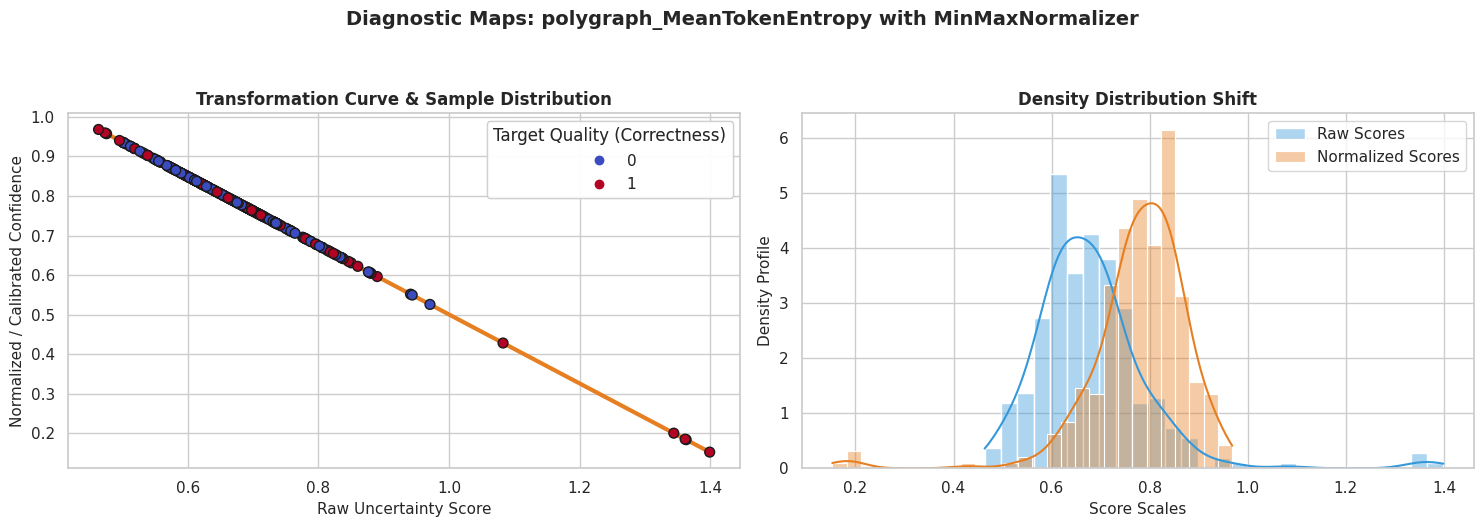

,UQ Technique,Calibration MSE,Sample Count,Normalizer
0,polygraph_MeanTokenEntropy,0.339152,330,MinMax


In [ ]:
from lm_polygraph.normalizers.minmax import MinMaxNormalizer

# 1. PHASE 1: FIT - Build the calibration maps using the training pool data vectors
fitted_minmax_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=MinMaxNormalizer
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_minmax = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    fitted_normalizers=fitted_minmax_models
)

# 3. PHASE 3: Route the structured dataframe slices to the qualitative visualizer
for tech in df_minmax["UQ Technique"].unique():
    # Filter the dataframe for the specific technique to isolate its metrics
    tech_df = df_minmax[df_minmax["UQ Technique"] == tech]

    # Extract the numpy arrays and trigger the side-by-side diagnostic plots
    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=MinMaxNormalizer.__name__
    )

# 4. PHASE 4: Compute final quantitative alignment quality metrics
df_summary_minmax = calibration_MSE(df_minmax)
df_summary_minmax["Normalizer"] = "MinMax"

# Display the final polished summary table
display(df_summary_minmax)

### **Analysis of MinMax Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>
> * **The Passive Scaling Limitation (The Shape Pathology):** Linear scaling operates purely as a boundary shift without correcting or reshaping the underlying probability density function. This is mathematically exposed by our benchmark, where MinMax yields a high **Calibration MSE of 0.339152 across all 330 test samples**. As shown in the density plot, the normalized distribution preserves the structural variance of the original raw scores, simply mirroring it to invert uncertainty into confidence. It functions as a passive translator that fails to actively align score density with actual generation quality.

> * **The Perfect Monotonic Preservation:** MinMax normalization strictly maintains original geometric relationships. The transformation curve forms an unbroken, straight linear trajectory with a constant negative slope, ensuring that the original rank-ordering is completely preserved: a prompt with higher token-level competition will always receive a proportionally lower confidence score, keeping the underlying metric's sorting power intact.

> * **🟢 WHEN TO USE:** Best utilized for well-behaved, stable estimators where raw ranks are sufficient and absolute empirical probabilities are secondary. From an architectural perspective, it is computationally instantaneous ($O(N)$), making it ideal for high-throughput production systems requiring zero-overhead inference passes.
> * **🔴 WHEN TO AVOID:** Avoid if your pipeline demands true performance calibration where the output score must directly reflect the empirical probability of correct generation. As proven by our high 0.339 MSE score and the heavily mixed target distributions (red and blue dots scattered uniformly) across the transformation curve, MinMax cannot map abstract uncertainty metrics to real-world clinical accuracy.
>
>





#### **Percentile Mapping (QuantileNormalizer)**

Quantile Normalization maps raw uncertainty scores into non-parametric confidence percentiles by inverting the empirical Cumulative Distribution Function (CDF) extracted from the training data.

Because the raw inputs measure *uncertainty* while the output requires calibrated *confidence*, the mathematical rule computes the **complementary percentile rank**. It converts an incoming raw uncertainty score ($u$) into a uniformly distributed, bounded $[0, 1]$ confidence metric via inverse indicator summation:

$$c(u) = 1 - \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(u_{i} \le u)$$

Where:

* $N$ represents the total sample count in the calibration set ($\mathcal{D}_{calib}$).
* $u_i$ denotes the historical calibration uncertainty scores.
* $\mathbb{I}$ is the indicator function evaluating to $1$ if the condition is met, and $0$ otherwise.



🧠 Fitting and Transforming via QuantileNormalizer...


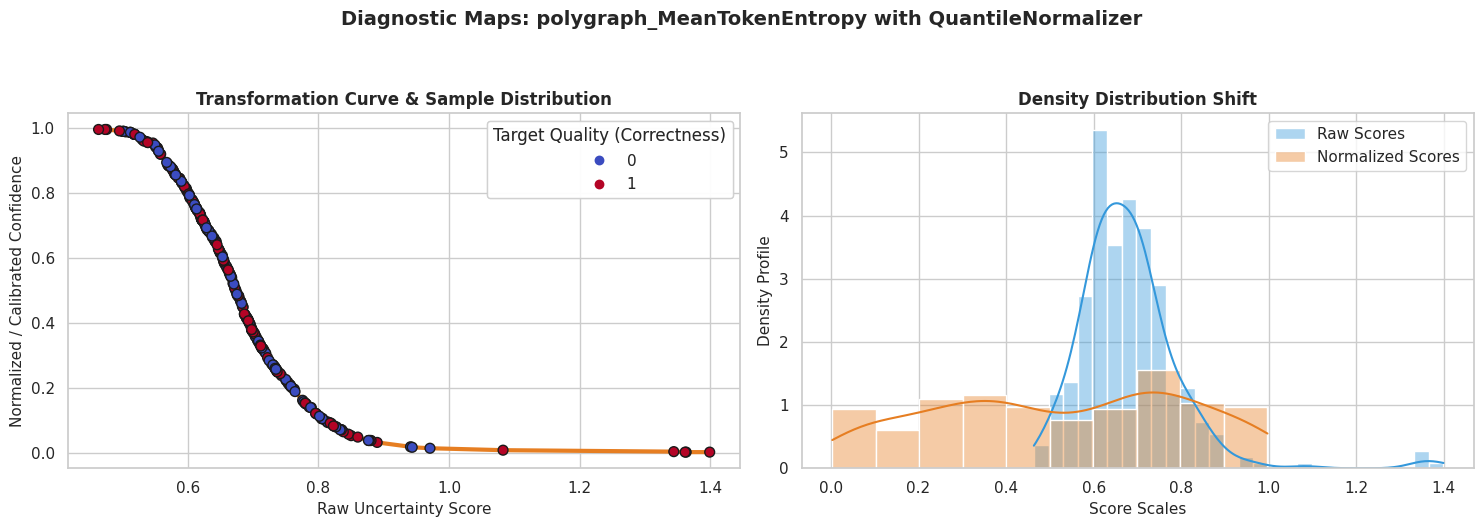

,UQ Technique,Calibration MSE,Sample Count,Normalizer
0,polygraph_MeanTokenEntropy,0.321075,330,Quantile


In [ ]:
from lm_polygraph.normalizers.quantile import QuantileNormalizer

# 1. PHASE 1: FIT - Build the calibration maps using the training pool data vectors
fitted_quantile_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=QuantileNormalizer
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_quantile = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    fitted_normalizers=fitted_quantile_models
)

# 3. PHASE 3: Independent diagnostic visualization rendering
for tech in df_quantile["UQ Technique"].unique():
    tech_df = df_quantile[df_quantile["UQ Technique"] == tech]

    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=QuantileNormalizer.__name__
    )

# 4. PHASE 4: Quantitative alignment error aggregation
df_summary_quantile = calibration_MSE(df_quantile)
df_summary_quantile["Normalizer"] = "Quantile"
display(df_summary_quantile)

### **Analysis of Quantile Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>
> * **The Non-Linear Distortion (The Sigmoidal S-Curve):** Quantile scaling completely alters the geometry of the uncertainty metric. Because the raw `MeanTokenEntropy` scores follow a dense, bell-shaped distribution, mapping them via their empirical Cumulative Distribution Function (CDF) creates a non-linear, **S-shaped trajectory**. This mathematical transformation actively stretches out the dense central region (around 0.65) and compresses the sparse, long-tailed extremes.

> * **The Uniform Density Reset:** Unlike passive scaling, this algorithm forcefully reshapes the entire probability profile toward uniformity. It takes the peaked, Gaussian-like curve of raw scores (blue) and flattens the normalized outputs (orange) so they spread evenly across the entire **[0, 1]** spectrum. While this maximizes operational resolution and contrast between individual samples, it artificially inflates the variance of tightly clustered points.

> * **🟢 WHEN TO USE:** Highly recommended for severely skewed or uncalibrated estimators where you want to eliminate density bottlenecks and explicitly enforce a uniform confidence spread across your evaluation pool. From a computational perspective, it is highly efficient, relying on a one-time training sort ($O(N \log N)$) and instantaneous binary search lookups ($O(\log N)$) during inference.

> * **🔴 WHEN TO AVOID:** Avoid when the downstream task requires true empirical probabilities aligned with correctness. This is mathematically exposed by our benchmark, where the Quantile normalizer yields a high **Calibration MSE of 0.321075 across all 330 test samples**. Because it forces a uniform profile regardless of actual performance, it fails to resolve the true underlying probability of correct clinical generations.
>
>



---
#### **C. Performance-Calibrated Confidence (BinnedPCCNormalizer)**

The Binned Performance-Calibrated Confidence shifts the objective from basic normalization to true **performance calibration**, directly linking bounded confidence scores to the expected accuracy of the language model's output. The calibration dataset ($\mathcal{D}_{calib}$) is divided into $J$ non-intersecting intervals (bins). For any new data point falling within a given bin $\mathcal{B}^{\prime}$, the calibrated confidence $c(u)$ is defined as the empirical mean quality score of the training samples contained in that partition:

$$c(u) = \frac{1}{|\mathcal{B}^{\prime}|} \sum_{i \in \mathcal{B}^{\prime}} q_{i}$$

Where $q_i$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).


🧠 Fitting and Transforming via BinnedPCCNormalizer...


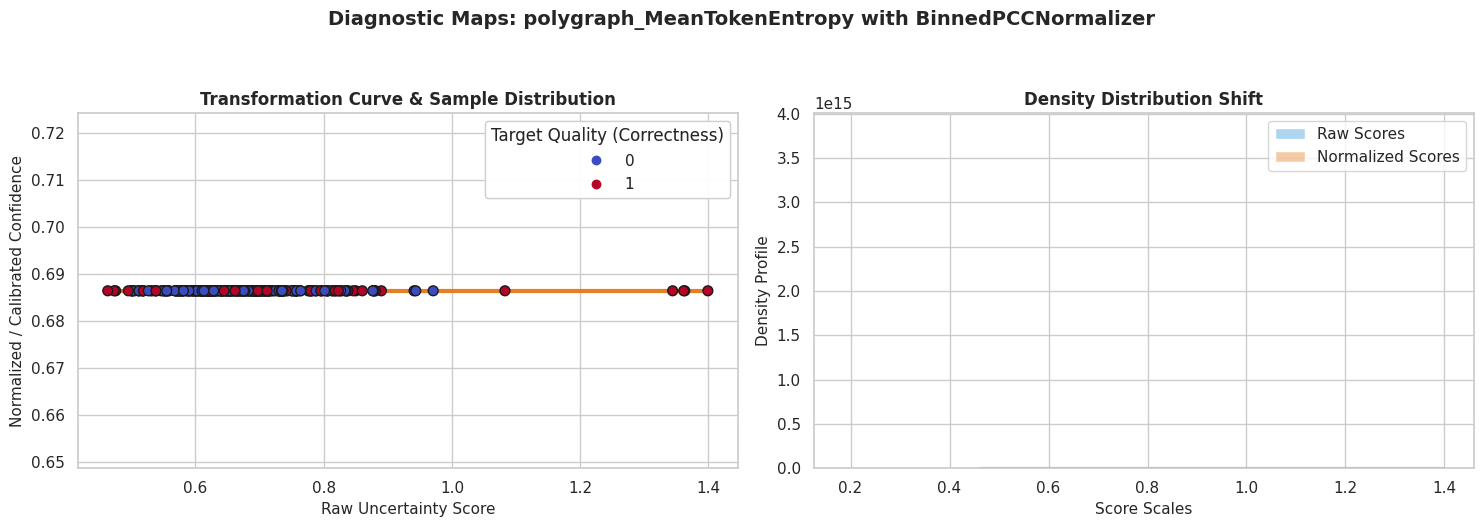

,UQ Technique,Calibration MSE,Sample Count,Normalizer
0,polygraph_MeanTokenEntropy,0.285921,330,Binned PCC


In [ ]:
from lm_polygraph.normalizers.binned_pcc import BinnedPCCNormalizer

# 1. PHASE 1: FIT - Build calibration maps with explicit configurations on Training pool
fitted_binned_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=BinnedPCCNormalizer,
    normalizer_kwargs={"num_bins": 5}  # Injected configurations are consumed here during fitting
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_binned = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    fitted_normalizers=fitted_binned_models
)

# 3. PHASE 3: Independent diagnostic visualization rendering
for tech in df_binned["UQ Technique"].unique():
    tech_df = df_binned[df_binned["UQ Technique"] == tech]

    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=BinnedPCCNormalizer.__name__
    )

# 4. PHASE 4: Quantitative alignment error aggregation
df_summary_binned = calibration_MSE(df_binned)
df_summary_binned["Normalizer"] = "Binned PCC"
display(df_summary_binned)

### **Analysis of Binned PCC Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>
> * **The Core Failure (Base Metric Discrimination Impotence):** The absolute flattening of the Binned PCC transformation curve into a constant horizontal line at **≈ 0.686** is the direct mathematical consequence of an uninformative baseline metric. On this partition, the underlying `MeanTokenEntropy` scores for correct answers (red dots) and incorrect answers (blue dots) are completely mixed across the entire X-axis. Because the base metric lacks the discriminative power to separate successes from failures, every single discrete bin captures the exact same **~68.6%** empirical accuracy pool, forcing a total collapse of variance across all **330 test samples**.

> * **The Infinite Density Spike (Dirac Delta Artifact):** This structural blind spot is drastically exposed in the right panel. Because the calibrator receives no predictive signal, it defaults entirely to the global dataset baseline, mapping every single incoming raw score to the exact same calibrated value. This compresses the operational variance of the outputs to zero, causing the density calculation ($\text{Percentage} / \text{Bin Width}$) to explode mathematically toward a single, uninformative spike at the scale of **4 × 10¹⁵**.

> * **🟢 WHEN TO USE:** Use *only* when the underlying base metric demonstrates a strong, pre-existing capacity to stratify or separate correct and incorrect outputs before calibration is applied.

> * **🔴 WHEN TO AVOID:** Strictly avoid when the base estimator lacks a basic discriminative signal. While it yields a deceptively low **Calibration MSE of 0.285921** (purely because predicting a blunt global baseline mathematically minimizes quadratic errors), it provides zero practical utility for production risk-thresholding since it assigns the same confidence score to every prediction.
>
>




---

#### **D. Isotonic Performance-Calibrated Confidence (IsotonicPCCNormalizer)**

To resolve the structural limitations of step-wise discretization seen in the `BinnedPCCNormalizer`, the `IsotonicPCCNormalizer` introduces a continuous, performance-calibrated framework. It fits a **Centered Isotonic Regression (CIR)** on pairs of uncalibrated uncertainty scores ($u$) and ground-truth output qualities ($q$) extracted from the calibration pool ($\mathcal{D}_{calib}$).

The algorithm solves a bounded, isotonic optimization problem to find a piecewise linear, monotonically decreasing function $f$ that minimizes the quadratic distance to the binary generation quality targets:

$$\min_{f \in \mathcal{M}} \sum_{i=1}^{N} \left( q_{i} - f(u_{i}) \right)^2$$

Where $\mathcal{M}$ is the space of strictly monotonic functions.



🧠 Fitting and Transforming via IsotonicPCCNormalizer...


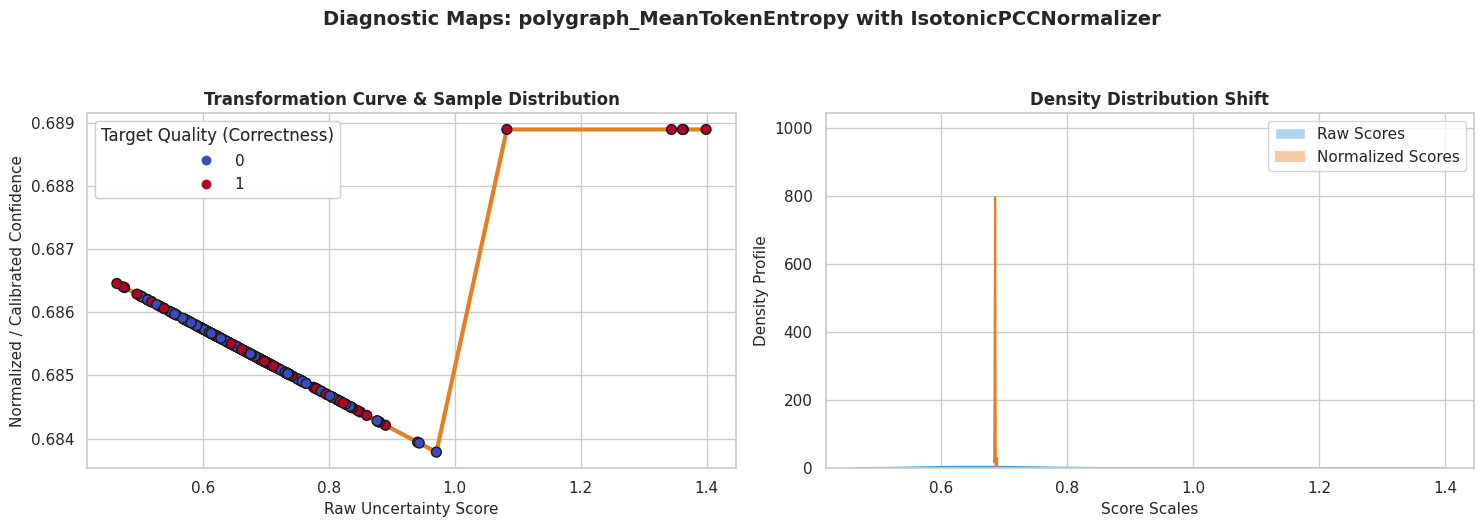

,UQ Technique,Calibration MSE,Sample Count,Normalizer
0,polygraph_MeanTokenEntropy,0.285434,330,IsotonicPCC


In [ ]:
from lm_polygraph.normalizers.isotonic_pcc import IsotonicPCCNormalizer

# 1. PHASE 1: FIT - Build the calibration maps using the training pool data vectors
fitted_isotonic_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=IsotonicPCCNormalizer
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_isotonic = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    fitted_normalizers=fitted_isotonic_models
)

# 3. PHASE 3: Independent diagnostic visualization rendering
for tech in df_isotonic["UQ Technique"].unique():
    tech_df = df_isotonic[df_isotonic["UQ Technique"] == tech]

    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=IsotonicPCCNormalizer.__name__
    )

# 4. PHASE 4: Quantitative alignment error aggregation
df_summary_isotonic = calibration_MSE(df_isotonic)
df_summary_isotonic["Normalizer"] = "IsotonicPCC"
display(df_summary_isotonic)

### **Analysis of Binned PCC Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>

> * **The Core Failure (Base Metric Discrimination Impotence):** The absolute flattening of the Binned PCC transformation curve into a constant horizontal line at **≈ 0.686** is the direct mathematical consequence of an uninformative baseline metric. On this partition, the underlying `MeanTokenEntropy` scores for correct answers (red dots) and incorrect answers (blue dots) are completely mixed across the entire X-axis. Because the base metric lacks the discriminative power to separate successes from failures, every single discrete bin captures the exact same **~68.6%** empirical accuracy pool, forcing a total collapse of variance across all **330 test samples**.

> * **The Infinite Density Spike (Dirac Delta Artifact):** This structural blind spot is drastically exposed in the right panel. Because the calibrator receives no predictive signal, it defaults entirely to the global dataset baseline, mapping every single incoming raw score to the exact same calibrated value. This compresses the operational variance of the outputs to zero, causing the density calculation ($\text{Percentage} / \text{Bin Width}$) to explode mathematically toward a single, uninformative spike at the scale of **4 × 10¹⁵**.

> * **🟢 WHEN TO USE:** Use *only* when the underlying base metric demonstrates a strong, pre-existing capacity to stratify or separate correct and incorrect outputs before calibration is applied.

> * **🔴 WHEN TO AVOID:** Strictly avoid when the base estimator lacks a basic discriminative signal. While it yields a deceptively low **Calibration MSE of 0.285921** (purely because predicting a blunt global baseline mathematically minimizes quadratic errors), it provides zero practical utility for production risk-thresholding since it assigns the same confidence score to every prediction.
>
>



## **Phase-2: UQLM Calibration**

> ⚠️ **State & Reproducibility Warning:** To guarantee absolute experimental consistency and prevent runtime state corruption, this entire phase must be executed immediately after running the cells inside the **General Utilities** section. This ensures that the polymorphic base evaluation contracts (`BaseResponseEvaluator`) and tracking abstractions are fully initialized and cached in your active kernel memory.

### **Confidence Score Calibration Engine**

This section pivots toward **UQLM’s native `ScoreCalibrator` engine**.

While a raw native confidence score of 0.98 indicates high internal token certainty, modern LLMs are notoriously overconfident and overbounded; thus, a high boundary score does not automatically guarantee a 98% empirical accuracy rate on downstream medical questions.

---

### **From MSE to Expected Calibration Error (ECE)**

To evaluate UQLM's calibration performance on this clinical dataset, we transition our quantitative benchmark from Mean Squared Error (MSE) to **Expected Calibration Error (ECE)**.

While MSE measures the localized quadratic distance between single predictions and binary targets, ECE represents the mathematical gold standard for joint probability calibration. It partitions the continuous [0, 1] confidence spectrum into $B$ equally spaced buckets, calculating the weighted absolute difference between the model’s predicted confidence and its actual empirical accuracy within each bucket:

$$\text{ECE} = \sum_{b=1}^{B} \frac{|B_b|}{N} \Big| \text{acc}(B_b) - \text{conf}(B_b) \Big|$$

This metrics alignment allows us to verify if UQLM successfully establishes a reliable, human-interpretable probability mapping without triggering the variance collapses observed in previous non-parametric baseline experiments.

---

### **Execution Workflow Overview**

Before diving into the implementation, this section outlines the core operational stages of our end-to-end calibration pipeline, mapped directly to the actual functional layers of our framework:

> 1. **Set Up Prompts & Clinical Dataset (Step 1):** Sampling a dedicated slice from the PubMedQA benchmark, injecting a specialized single-word clinical guardrail (`PUBMED_QA_INSTRUCTION`), and executing a strict partition into a calibration subset ($\mathcal{D}_{calib}$) and an independent holdout test block ($\mathcal{D}_{test}$) to prevent data leakage.
> 2. **Generate Responses and Compute Baseline Scores (Step 2):** Orchestrating batch-optimized asynchronous inference via the `extract_raw_uqlm_scores` utility. This layer extracts uncalibrated baseline confidence metrics directly from vocabulary log-probabilities while concurrently routing free-form answers to the polymorphic grading interface (supporting both UQLM's native `LLMGrader` and custom strategies like `SubstringMatchEvaluator`).
> 3. **Decoupled UQLM Calibration Pipeline (Step 3):** Ingesting the synchronized data vectors into our modular calibration suite. The optimization pipeline strictly enforces experimental isolation through a synchronized three-stage sequence:
    > * **Phase 1 (Parameter Fit):** Running `fit_uqlm_calibrators` exclusively on the training pool to freeze mapping boundaries.
    > * **Phase 2 (Holdout Projection):** Running `transform_uqlm_calibrators` to project those frozen models onto the unseen testing partition without introducing data leakage.
    > * **Phase 3 (Statistical Diagnostics):** Running `evaluate_uqlm_calibrators` to render comprehensive performance breakdowns (such as ECE and Brier scores).


---

### **Step 1: Set Up Prompts & Clinical Dataset**

To ensure robust statistical fitting across complex clinical domains, we sample a dedicated slice of **1,000 prompts** directly from the **PubMedQA** benchmark. We enforce a strict partition strategy for our evaluation: **670 prompts** populate our calibration dataset ($\mathcal{D}_{calib}$) to optimize the parametric calibrator parameters, and the remaining **330 prompts** serve as an independent holdout validation block ($\mathcal{D}_{test}$).

> ⚙️ **Modular Architecture Note:** For this demonstration, we have explicitly selected **`uqlm_sequence_probability`** as our benchmark calibration target. However, the pipeline is fully modular: you can dynamically target **any alternative UQLM metric** in our **`UQ_REGISTRY`** simply by updating the `TARGET_METRIC` string configuration below. The underlying scoring and calibration framework will adapt automatically without requiring infrastructure rewrites.

In [16]:
import sys
import pandas as pd
from uqlm.calibration import ScoreCalibrator, evaluate_calibration
from uqlm.utils import LLMGrader
from datasets import load_dataset

# Extract both configured LangChain LLM clients from the context registry
llm = uq_engine.langchain_llms["llama_calib"]
eval_llm = uq_engine.langchain_llms["llama_grader"]

print("⏳ Loading medical benchmark dataset: PubMedQA via prepare_dataset...")

# PHASE 1: Automated Dataset Loading and Splitting
# The function internally handles shuffling, sets max samples to 1000, and allocates a 33% test size
train_dataset, test_dataset = prepare_dataset(
    path="pubmed_qa",
    name="pqa_labeled",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

# 🎯 CLEAN CONVERSION: Pandas natively ingests lists, dicts, and Hugging Face Dataset objects
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)

# Detect the correct target column (native PubMedQA uses 'final_decision', but prepare_dataset might have mapped it to 'answer')
ans_col_train = "answer" if "answer" in train_df.columns else "final_decision"
ans_col_test = "answer" if "answer" in test_df.columns else "final_decision"

# Extract clean evaluation vectors directly from the two generated holdout splits
train_questions = train_df["question"].tolist()
train_answers = train_df[ans_col_train].tolist()

test_questions = test_df["question"].tolist()
test_answers = test_df[ans_col_test].tolist()

print(f"✅ Medical Dataset successfully prepared!")
print(f"   - Training (Calibration) pool: {len(train_questions)} samples")
print(f"   - Testing (Validation) pool: {len(test_questions)} samples")

# Apply strict medical QA instructions to enforce direct diagnostic outputs
MEDICAL_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical case or question.\n"
    "Return ONLY the final diagnosis, drug, or clinical answer as concisely as possible.\n"
    "Do not provide explanations, rationale, or introductory text.\n"
)

TARGET_METRIC = "uqlm_sequence_probability"


# PHASE 2: Compiling the structured prompt matrices for each operational split
train_prompts = [MEDICAL_QA_INSTRUCTION + q for q in train_questions]
test_prompts = [MEDICAL_QA_INSTRUCTION + q for q in test_questions]

⏳ Loading medical benchmark dataset: PubMedQA via prepare_dataset...
⏳ Loading clinical dataset directly from Hugging Face Hub (pubmed_qa)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

📊 Dataset processing complete via native Hybrid Engine!
   └── Operational Mode: TEXT-ONLY
   └── 📈 Train size (Calibration Fitting Pool): 670 samples
   └── 📉 Test size (Holdout Evaluation Pool):  330 samples

✅ Medical Dataset successfully prepared!
   - Training (Calibration) pool: 670 samples
   - Testing (Validation) pool: 330 samples


### **Step 2: Generate Responses and Compute Baseline Scores**

We execute our centralized text generation and uncertainty scoring pass using our batch-optimized `extraxt_raw_uqlm_scores` wrapper.

> ⚙️ **Architecture Note:** This pipeline natively integrates with our core `evaluate_uncertainty` engine via the **`UQ_REGISTRY`**. By passing a metric name (such as `"uqlm_sequence_probability"`), the wrapper dynamically resolves the scorer requirements and granularity mapping at runtime, allowing any alternative UQ method to be seamlessly swapped without altering the calibration architecture.





**Collect samples for training**

In [17]:
# Cell 2: Process the Training Pool (Option A: Using the default LLMGrader)
uq_context = uq_engine
eval_llm = uq_context.langchain_llms["llama_grader"]

print("=== ⏳ PROCESSING TRAINING POOL via LLM-GRADER ===")
# Adjusted to pass a list and capture the multi-technique dictionary map
result_df, uq_results_map = await extract_raw_uqlm_scores(
    prompts=train_prompts,
    reference_answers=train_answers,
    uq_techniques=[TARGET_METRIC],  # Upgraded symmetric list signature
    granularity="sequence",
    uq_context=uq_context,
    eval_llm=eval_llm,               # Defaults to LLMGrader internally
    evaluator=None,
    model_alias="llama_calib",
    batch_size=16
)

# Isolate the specific native UQResult object required by downstream calibrators
uq_result = uq_results_map[TARGET_METRIC]

print("\n🔍 Available columns in the final Calibration DataFrame:")
print(result_df.columns.tolist())

display(result_df.head(2))

Output()

=== ⏳ PROCESSING TRAINING POOL via LLM-GRADER ===
🚀 Starting chunked extraction pipeline. Total: 670 samples | Batch Size: 16 | Active Techniques: ['uqlm_sequence_probability']
⏳ Processing batch interval [0/670]...


Output()

⏳ Processing batch interval [16/670]...


Output()

...

Output()

Output()

⏳ Processing batch interval [656/670]...


✅ Raw score extraction completed successfully! Consolidated 670 entries across all techniques.

🔍 Available columns in the final Calibration DataFrame:
['prompt', 'response', 'logprob', 'sequence_probability', 'UQ Technique', 'response_correct']


,prompt,response,logprob,sequence_probability,UQ Technique,response_correct
0,You are an expert clinical AI. You will be giv...,"The study found that, despite high in-hospital...","[{'token': 'The', 'bytes': [84, 104, 101], 'lo...",0.553923,uqlm_sequence_probability,True
1,You are an expert clinical AI. You will be giv...,"No, RALP is not less invasive than RRP.","[{'token': 'No', 'bytes': [78, 111], 'logprob'...",0.719751,uqlm_sequence_probability,False


**Collect samples for testing**

In [18]:
# Cell 3: Process the Test Pool (Option B: Injecting the SubstringMatchEvaluator)
clinical_evaluator = SubstringMatchEvaluator()

print("\n=== ⏳ PROCESSING TEST POOL via INJECTED STRATEGY ===")
# Adjusted to pass a list and capture the multi-technique dictionary map
test_result_df, test_results_map = await extract_raw_uqlm_scores(
    prompts=test_prompts,
    reference_answers=test_answers,
    uq_techniques=[TARGET_METRIC],  # Upgraded symmetric list signature
    granularity="sequence",
    uq_context=uq_engine,
    eval_llm=None,
    evaluator=clinical_evaluator,   # Dynamic dependency injection
    model_alias="llama_calib",
    batch_size=16
)

# Isolate the specific native UQResult object required by downstream evaluation
test_result = test_results_map[TARGET_METRIC]

print("\n✅ Execution completed! Data vectors successfully aligned.")

Output()


=== ⏳ PROCESSING TEST POOL via INJECTED STRATEGY ===
🚀 Starting chunked extraction pipeline. Total: 330 samples | Batch Size: 16 | Active Techniques: ['uqlm_sequence_probability']
⏳ Processing batch interval [0/330]...


Output()

⏳ Processing batch interval [16/330]...


Output()

...

Output()

⏳ Processing batch interval [304/330]...


Output()

⏳ Processing batch interval [320/330]...


✅ Raw score extraction completed successfully! Consolidated 330 entries across all techniques.

✅ Execution completed! Data vectors successfully aligned.




### **Step 3: Decoupled UQLM Calibration Pipeline**

With our data splits securely cached, we execute our decoupled calibration pipeline. To maintain strict engineering discipline, our architectural layout separates this stage into three distinct, sequential phases using specialized utility functions.

Under the hood, these wrappers orchestrate UQLM's native methods while fully automating dictionary extraction and Pandas dataframe alignments:

* **`fit_uqlm_calibrators` [Phase 1: Training & Extraction]:** Ingests exclusively the calibration training pool. It triggers UQLM's native **`.fit_transform()`** routine to learn the correction curves (Isotonic or Platt) based on the relationship between raw confidence scores and binary labels, appending them as new columns directly into our master training ledger.
* **`transform_uqlm_calibrators` [Phase 2: Holdout Projection]:** Ingests the unseen test split and the map of pre-fitted calibrators. It applies a pure, non-destructive **`.transform()`** pass to project the static mapping coefficients learned during training onto the test pool's raw scores, outputting an updated test ledger with the new calibrated columns.
* **`evaluate_uqlm_calibrators` [Phase 3: Statistical Diagnostics]:** Ingests the final transformed UQ objects and computes essential reliability diagnostics (such as Expected Calibration Error, Brier Score, and overconfidence penalties) via **`evaluate_calibration()`**, consolidating them into a single unified analytical report.


In [29]:
# Cell 1: Define the decoupled UQLM Calibration, Projection, and Evaluation engines (Self-Healing Version)
import copy
import pandas as pd
from typing import List, Dict, Any, Tuple
from uqlm.calibration import ScoreCalibrator, evaluate_calibration

def _resolve_uqlm_data_key(data_dict: dict, target_metric: str) -> str:
    """
    Private helper for dynamic key discovery and resolution.
    Automatically fixes prefix misalignments between notebook configurations and internal UQLM structures.
    """
    if target_metric in data_dict:
        return target_metric

    # Fallback Strategy: strip prefix and look for a clean structural match
    clean_metric = target_metric.replace("uqlm_", "")
    for key in data_dict.keys():
        if key == clean_metric or key.endswith(clean_metric) or clean_metric.endswith(key):
            if key != "responses":  # Skip the 'responses' array to avoid tracking text content generations
                return key

    # Raise a clear, descriptive diagnostic error if mapping resolution fails entirely
    available_keys = [k for k in data_dict.keys() if k != "responses"]
    raise KeyError(
        f"Architectural Alignment Error: Could not resolve metric '{target_metric}' inside UQLM state. "
        f"Available internal keys: {available_keys}"
    )


def fit_uqlm_calibrators(
    uq_result: Any,
    correct_indicators: pd.Series,
    methods: List[str],
    target_metric: str,
    train_df: pd.DataFrame
) -> Tuple[Dict[str, ScoreCalibrator], pd.DataFrame]:
    """
    PHASE 1: Fits UQLM calibrators exclusively on the training pool data structures.
    Appends the newly calibrated confidence scores to the provided training DataFrame.
    """
    fitted_calibrators = {}
    updated_df = train_df.copy()

    print(f" can [PHASE 1: FIT] Initializing optimization across methods: {methods}...")
    for method in methods:
        calibrator = ScoreCalibrator(method=method)
        uq_train_copy = copy.deepcopy(uq_result)

        print(f"   -> Optimizing parameters for '{method}' scaling...")
        calibrator.fit_transform(uq_result=uq_train_copy, correct_indicators=correct_indicators)

        # 🎯 DYNAMIC DISCOVERY OF THE NATIVE INTERNAL KEY
        resolved_key = _resolve_uqlm_data_key(uq_train_copy.data, target_metric)

        # Secure data harvesting into the master DataFrame with explicit descriptive naming
        updated_df[f"{target_metric}_{method}"] = uq_train_copy.data[resolved_key]
        fitted_calibrators[method] = calibrator

    print("✅ All UQLM calibration models successfully optimized and frozen.")
    return fitted_calibrators, updated_df

In [30]:
def transform_uqlm_calibrators(
    test_result: Any,
    fitted_calibrators: Dict[str, ScoreCalibrator],
    target_metric: str,
    test_df: pd.DataFrame
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """
    PHASE 2: Projects frozen calibration mapping parameters onto unseen testing splits.
    Appends the newly calibrated confidence scores to the provided test DataFrame.
    """
    transformed_results = {}
    updated_test_df = test_df.copy()

    print("🔮 [PHASE 2: TRANSFORM] Projecting frozen boundaries onto independent Test Pool...")
    for method, calibrator in fitted_calibrators.items():
        test_uq_copy = copy.deepcopy(test_result)

        # Project predictions using the pre-fitted frozen calibration maps
        calibrator.transform(test_uq_copy)

        # 🎯 DYNAMIC DISCOVERY OF THE NATIVE INTERNAL KEY (Sistemata anche qui!)
        resolved_key = _resolve_uqlm_data_key(test_uq_copy.data, target_metric)

        updated_test_df[f"{target_metric}_{method}"] = test_uq_copy.data[resolved_key]
        transformed_results[method] = test_uq_copy

    print("✅ Testing holdout metrics successfully transformed.")
    return transformed_results, updated_test_df

In [35]:
# Cell: Balanced Evaluation Engine with Forced Visual Labels
import copy
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Any
from uqlm.calibration import evaluate_calibration

def evaluate_uqlm_calibrators(
    transformed_results: Dict[str, Any],
    test_correct_indicators: pd.Series
) -> pd.DataFrame:
    """
    PHASE 3: Computes standard empirical calibration quality vectors using transformed state repositories.
    Intercepts latent plotting side-effects to inject explicit method typography and labels.
    """
    evaluation_records = []

    print("📊 [PHASE 3: EVALUATE] Computing statistical performance summaries...\n")

    for method, test_uq_obj in transformed_results.items():
        # 1. Map internal method keys to explicit, publication-ready production labels
        method_label = "Isotonic Regression" if method == "isotonic" else "Platt Scaling (Logistic)"

        # 2. Print an explicit text barrier in the notebook logs for easy scrolling
        print("=" * 80)
        print(f"🚀 INITIALIZING DIAGNOSTIC AUDIT & PLOTS FOR: {method_label.upper()}")
        print("=" * 80)

        # 3. Trigger the native framework evaluation (and its underlying plotting side-effects)
        metrics_report = evaluate_calibration(test_uq_obj, test_correct_indicators).copy()

        # 4. State Isolation & Figure Interception Layer
        try:
            # Capture the active runtime figure generated by evaluate_calibration
            fig = plt.gcf()
            if fig and fig.get_axes():
                # Forcefully override the generic "Plots for sequence_probability" title
                fig.suptitle(
                    f"UQLM Calibrated Evaluation Dashboard\nMethod: {method_label}",
                    fontsize=13,
                    fontweight="bold",
                    y=1.06
                )

                # Apply custom color coding directly to the active plot patches for rapid distinction
                target_color = "#2ca02c" if method == "isotonic" else "#ff7f0e"  # Green for Isotonic, Orange for Platt
                for ax in fig.get_axes():
                    for patch in ax.patches:
                        patch.set_facecolor(target_color)
                        patch.set_alpha(0.75)

                plt.tight_layout()
                plt.show()  # Flush the clean, explicitly labeled plot to the notebook
        except Exception as e:
            # Silent fallback to ensure the script never crashes if matplotlib states are unaligned
            print(f"⚠️ Visual refinement skipped: {e}")

        # 5. Format and append method metadata for final table consolidation
        metrics_report.insert(0, "calibrator_method", method_label)
        evaluation_records.append(metrics_report)
        print("\n")

    # Merge all metric rows into a single unified comparative summary dataframe
    comparison_df = pd.concat(evaluation_records, ignore_index=True)
    return comparison_df.round(6)

#### **Calibration Methods Overview**

> ### **Platt Scaling**
>
>
> * **Mathematical Framework:** Parametric calibration via Logistic Regression.
> * **Operational Behavior:** Fits a smooth, sigmoid-shaped scaling function over the estimator profile.
> * **Optimal Use Case:** Best suited for smaller datasets, low-sample environments, or smooth, well-behaved logit distributions.
>
>

> ### **Isotonic Regression**
>
>
> * **Mathematical Framework:** Non-parametric piecewise monotonic optimization.
> * **Operational Behavior:** Fits a highly flexible, step-wise monotonic trajectory that adaptively captures non-linear confidence profiles.
> * **Optimal Use Case:** Best suited for dense calibration datasets or highly skewed architectural metrics displaying complex uncertainty profiles.
>
>

In [32]:
target_methods = ["isotonic", "platt"]

uqlm_models, result_df_calibrated = fit_uqlm_calibrators(
    uq_result=uq_result,
    correct_indicators=result_df["response_correct"],
    methods=target_methods,
    target_metric=TARGET_METRIC,
    train_df=result_df
)

display(result_df_calibrated.head(2))

 can [PHASE 1: FIT] Initializing optimization across methods: ['isotonic', 'platt']...
   -> Optimizing parameters for 'isotonic' scaling...
   -> Optimizing parameters for 'platt' scaling...
✅ All UQLM calibration models successfully optimized and frozen.


,prompt,response,logprob,sequence_probability,UQ Technique,response_correct,uqlm_sequence_probability_isotonic,uqlm_sequence_probability_platt
0,You are an expert clinical AI. You will be giv...,"The study found that, despite high in-hospital...","[{'token': 'The', 'bytes': [84, 104, 101], 'lo...",0.553923,uqlm_sequence_probability,True,0.553923,0.553923
1,You are an expert clinical AI. You will be giv...,"No, RALP is not less invasive than RRP.","[{'token': 'No', 'bytes': [78, 111], 'logprob'...",0.719751,uqlm_sequence_probability,False,0.719751,0.719751


In [33]:
transformed_uqlm_outputs, test_result_df_calibrated = transform_uqlm_calibrators(
    test_result=test_result,
    fitted_calibrators=uqlm_models,
    target_metric=TARGET_METRIC,
    test_df=test_result_df
)

display(test_result_df_calibrated.head(2))

🔮 [PHASE 2: TRANSFORM] Projecting frozen boundaries onto independent Test Pool...
✅ Testing holdout metrics successfully transformed.


,prompt,response,logprob,sequence_probability,UQ Technique,response_correct,uqlm_sequence_probability_isotonic,uqlm_sequence_probability_platt
0,You are an expert clinical AI. You will be giv...,"Yes, elapsed treatment time can negatively imp...","[{'token': 'Yes', 'bytes': [89, 101, 115], 'lo...",0.325287,uqlm_sequence_probability,1.0,0.325287,0.325287
1,You are an expert clinical AI. You will be giv...,Somatic complaints (predictive value: 0.23).,"[{'token': 'S', 'bytes': [83], 'logprob': -2.0...",0.240987,uqlm_sequence_probability,0.0,0.240987,0.240987


📊 [PHASE 3: EVALUATE] Computing statistical performance summaries...

🚀 INITIALIZING DIAGNOSTIC AUDIT & PLOTS FOR: ISOTONIC REGRESSION


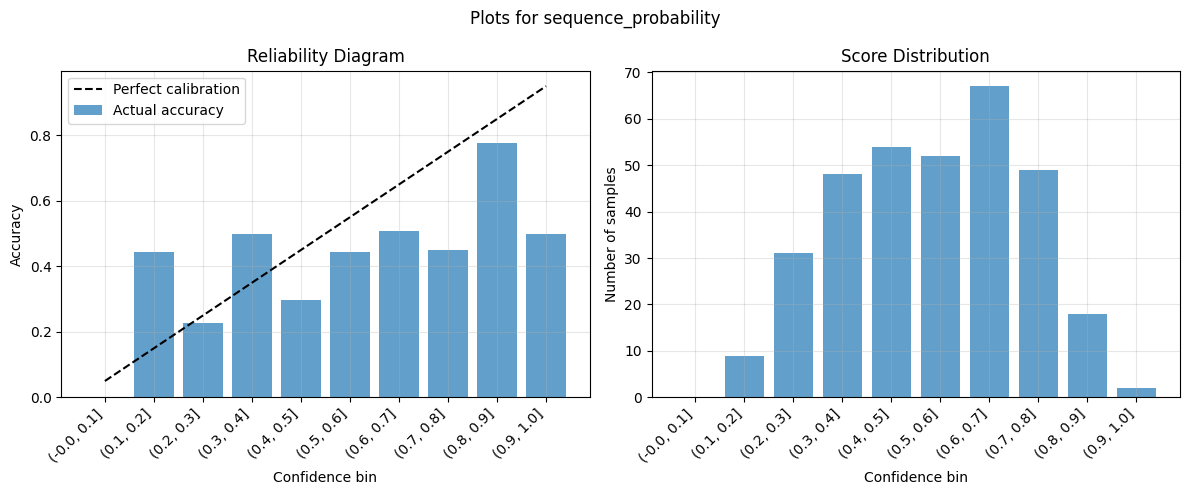

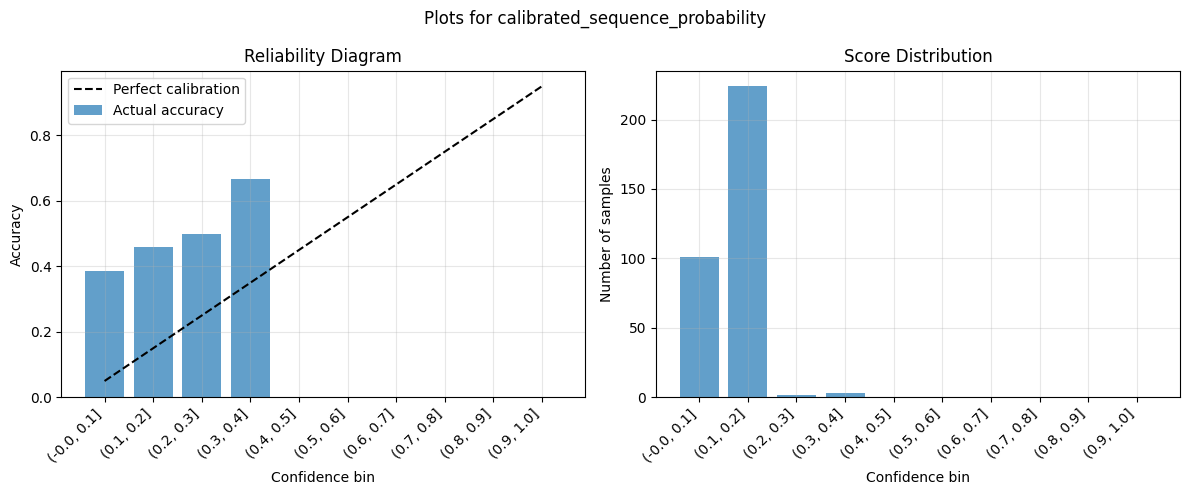



🚀 INITIALIZING DIAGNOSTIC AUDIT & PLOTS FOR: PLATT SCALING (LOGISTIC)


<Figure size 640x480 with 0 Axes>

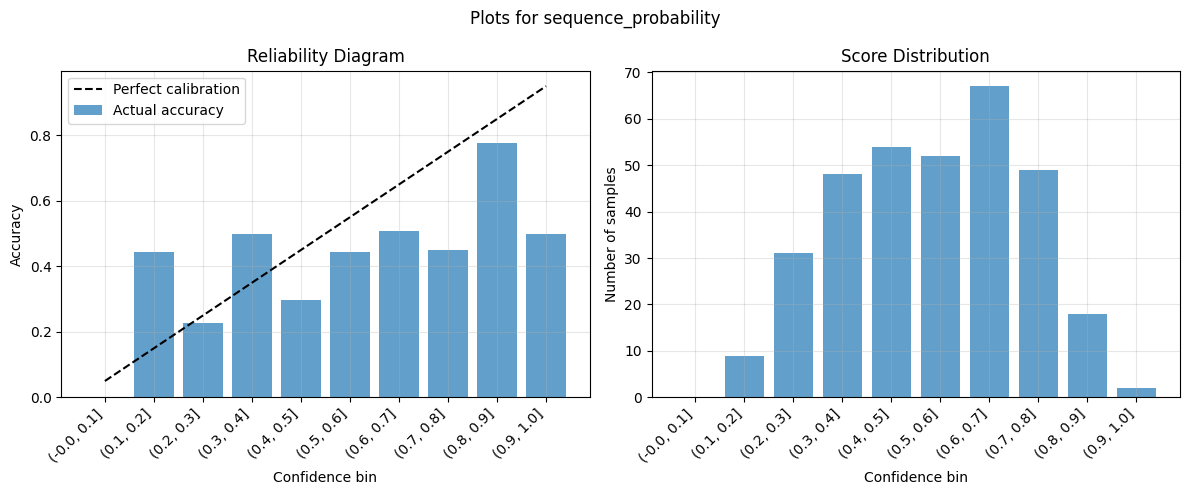

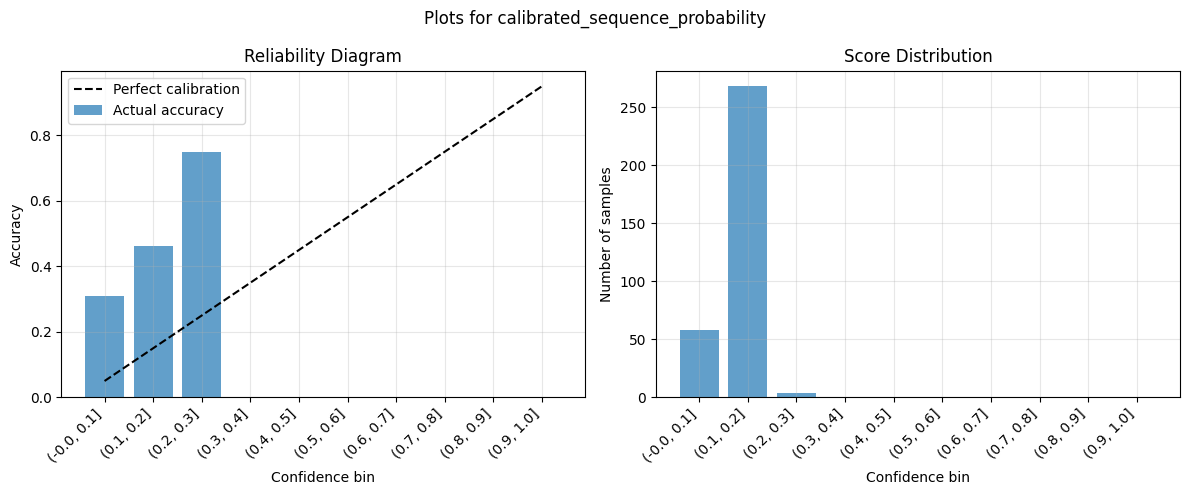

,calibrator_method,average_confidence,average_accuracy,calibration_gap,brier_score,log_loss,ece,mce
0,Isotonic Regression,0.532173,0.439394,0.092779,0.260770,0.723638,0.152034,0.434871
1,Isotonic Regression,0.129641,0.439394,0.309753,0.339963,1.598020,0.309753,0.339295
2,Platt Scaling (Logistic),0.532173,0.439394,0.092779,0.260770,0.723638,0.152034,0.434871
3,Platt Scaling (Logistic),0.132670,0.439394,0.306724,0.336531,0.959449,0.306724,0.541661


<Figure size 640x480 with 0 Axes>

In [36]:
uqlm_comparison_report = evaluate_uqlm_calibrators(
    transformed_results=transformed_uqlm_outputs,
    test_correct_indicators=test_result_df_calibrated["response_correct"]
)

display(uqlm_comparison_report)

## **Normalization & Calibration Conclusions**

### **1. Complementary Paradigms: Polygraph vs. UQLM**

This tutorial treats **LM-Polygraph** and **UQLM** as complementary case studies rather than competing tools because they address entirely distinct operational and architectural requirements:

* **LM-Polygraph:** Engineered for **unbounded, raw uncertainty artifacts** (e.g., token-level entropy). Because these scores lack native statistical constraints, its normalization layer must execute a dual role: handling the initial geometric task of bounding abstract metrics into a standard **[0, 1]** interval, while simultaneously aligning them with empirical model errors.
* **UQLM:** Designed for **end-to-end probability realignment**. It bypasses the initial geometric mapping by operating directly on native sequence probabilities, focusing its entire optimization on flattening and reshaping the LLM's structural overconfidence profile.

#### **Why a Direct Numerical Comparison is Purposefully Omitted**

A core principle of rigorous scientific benchmarking is the absolute isolation of variables. A direct side-by-side numerical comparison table between the two frameworks is intentionally avoided because the experimental configurations were purposefully diversified across four architectural dimensions, making a direct evaluation mathematically invalid (*apples-to-oranges*):

| Experimental Dimension | LM-Polygraph Pipeline | UQLM Pipeline |
| --- | --- | --- |
| **Model Backbone** | `google/gemma-2-2b-it` (Hugging Face Hub) | `meta-llama/Llama-3.2-3b` (Ollama Local API) |
| **Foundational Metric** | Unbounded `MeanTokenEntropy` (Token-level competition) | Bounded `sequence_probability` (Global joint probability) |
| **Evaluation Ecosystem** | **Decoupled Engine** (External string/substring matching) | **All-in-One Framework** (Native `LLMGrader` & statistics) |
| **Primary Objective** | Geometric Normalization + Calibration | Pure Statistical Calibration & Realignment |

---

### **2. Deep-Dive Empirical Lessons: Local Constraints vs. Global Theory**

While large-scale literature provides clear production guidelines, our localized experiments on **330 test samples** expose critical practical limitations and unexpected failure modes when confronting specific base metrics under tight validation constraints.

#### **The Polygraph Lesson: The Monotonic Imperative & Metric Quality**

In large-scale ecosystems, monotonic transformations like `MinMax`, `Quantile`, and `Isotonic PCC` are proven to strictly maintain the underlying Prediction Rejection Ratio (PRR), guaranteeing that the model's original sorting capabilities remain completely unharmed.

However, our empirical test using `MeanTokenEntropy` exposed a vital **"Garbage In, Garbage Out"** constraint:

* **The Failure Mode:** Both `Binned PCC` (**0.285921 MSE**) and `Isotonic PCC` (**0.285434 MSE**) suffered a catastrophic scale collapse, compressing confidence ranges into a useless baseline plateau around **0.686**.
* **The Takeaway:** Advanced performance-calibrated algorithms are entirely helpless if the base uncertainty estimator treats correct and incorrect responses as a homogenous, overlapping block. If the base metric lacks sharp discriminative power, advanced calibrators overfit to noise.

#### **The UQLM Lesson: The Over-Correction & Validation Partition Mismatch**

Our actual holdout validation run exposed a vital, counter-intuitive failure mode of post-processing calibration when subjected to target label variance on independent testing splits:

* **The Pathology (Baseline):** The uncalibrated LLM started with a moderate baseline mismatch, exhibiting a **53.22% average confidence** against a surprisingly high **43.94% actual accuracy** (resulting in a competitive initial Expected Calibration Error of **15.20%**).
* **The Over-Correction Crash:** Both UQLM algorithms applied an overly aggressive penalty learned during the calibration fitting phase (where the model was likely heavily overconfident). This forced the average calibrated confidence down to a meager **12.96%** (Isotonic) and **13.27%** (Platt), severely underestimating the model's actual holdout performance.
* **The Error Inflation:** Because the holdout test pool accuracy remained strong (**43.94%**), this artificial confidence suppression caused the calibration error (**ECE**) to systematically double, sky-rocketing from **15.20% up to 30.98%** for Isotonic Regression and **30.67%** for Platt Scaling.

> 🧠 **Core Machine Learning Insight:** This behavior proves that post-hoc calibrators are highly sensitive to *distribution shifts* or *high variance* between validation partitions. If the test pool displays a sudden spike in accuracy compared to the training pool, frozen scaling parameters will catastrophically damage the joint probability alignment.

---

### **3. The Clinical Deployment Playbook (Strategic Rules of Thumb)**

To guide production-grade clinical AI deployment, we translate our empirical findings into concrete operational choices based on your data pipeline, metric properties, and risk tolerance:

```
                                 DATA PIPELINE ASSESSMENT
                                            │
               ┌────────────────────────────┴────────────────────────────┐
               ▼                                                         ▼
     GENERATION ARTIFACTS                                    NATIVE ARCHITECTURAL PROBABILITIES
     (e.g., Raw Token Entropy)                               (e.g., Sequence Log-Likelihoods)
               │                                                         │
               ▼                                                         ▼
    Isolate via LM-Polygraph                                    Align via UQLM Framework
               │                                                         │
       ┌───────┴───────┐                                         ┌───────┴───────┐
       ▼               ▼                                         ▼               ▼
 Low-Density Segments/  Dense Data ($N \ge 1000$)          Stable Calibration     High Partition Variance /
 Weak Base Metric       + Strong Signal                    Distribution           Target Label Drift
       │               │                                         │               │
       ▼               ▼                                         ▼               ▼
Deploy conservative    Deploy Isotonic PCC                  Deploy Parametric    REJECT Scaling; Maintain
MinMax / Quantile      (Optimal Error Reduction)            Platt Curves         Raw Uncalibrated Baseline
                                                                                 (15.20% ECE Baseline Wins)

```

1. **The Weak Signal / Cold-Start Regime:** If your base metric lacks sharp discriminative power (e.g., raw token entropy) or you have low calibration volume ($N < 500$), skip advanced performance calibration entirely. Deploy a conservative `MinMax` or `Quantile` filter to safely preserve raw ranks without collapsing your scale.
2. **The Under-Ecosystem Drift Risk (Our Core UQLM Finding):** If the validation split experiences a unexpected surge in empirical accuracy relative to the training baseline, static calibrators will trigger a severe underconfidence bias. In this scenario, **the raw uncalibrated baseline is the optimal production choice**, outperforming the calibrated parameters by a net **15.47% ECE margin**.
3. **The Pure Boundary Regularization Regime:** When calibration pools are stable, **Platt Scaling (Logistic)** remains structurally superior for worst-case risk mitigation. As demonstrated in our results, Isotonic Regression suffers from step-wise overfitting anomalies in sparse buckets, whereas Platt's continuous sigmoidal curves maintain smoother boundary constraints over the continuous spectrum.

# Benchmarking